In [98]:
# Restart runtime to clean broken packages
##import os
##os.kill(os.getpid(), 9)

In [99]:
##!pip uninstall -y transformers -q
##!pip install transformers==4.36.2 torch sentencepiece -q

In [100]:
##import transformers
##print(transformers.__version__)

In [101]:
##from transformers import pipeline

##summarizer = pipeline("summarization")
##print("✅ Summarization is FIXED")

In [102]:
# ============================================================
# CLARIO PROJECT - LIBRARY INSTALLATION
# Run this ONCE at the start of every session
# ============================================================

# Upgrade pip first (pip is the tool that installs libraries)
!pip install --upgrade pip -q

# Whisper: converts audio/speech into text
!pip install openai-whisper -q

# Transformers: contains BART for summarization
##!pip install -U transformers==4.41.2 torch sentencepiece -q
!pip install transformers==4.36.2 torch sentencepiece -q

# Torch: the engine that powers AI models
!pip install torch -q

# spaCy: helps understand human language (NLP)
!pip install spacy -q

# Download spaCy's English language model
!python -m spacy download en_core_web_sm -q

# ROUGE: measures how good our summaries are
!pip install rouge-score -q

# NetworkX: builds knowledge graphs
!pip install networkx -q

# Matplotlib: draws charts and graphs
!pip install matplotlib -q

# Streamlit: builds the web dashboard (Person 3 mainly)
!pip install streamlit -q

# pyngrok: lets us share Streamlit from Colab
!pip install pyngrok -q

# Wordcloud: creates word cloud visuals
!pip install wordcloud -q

print("✅ ALL LIBRARIES INSTALLED SUCCESSFULLY!")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.3.3 which is incompatible.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ ALL LIBRARIES INSTALLED SUCCESSFULLY!


In [103]:
# ============================================================
# VERIFY ALL INSTALLATIONS
# ============================================================

print("Checking all libraries...\n")

try:
    import whisper
    print("✅ Whisper - OK")
except:
    print("❌ Whisper - FAILED")

try:
    from transformers import pipeline
    print("✅ Transformers - OK")
except:
    print("❌ Transformers - FAILED")

try:
    import torch
    print("✅ Torch - OK")
except:
    print("❌ Torch - FAILED")

try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    print("✅ spaCy + English model - OK")
except:
    print("❌ spaCy - FAILED")

try:
    from rouge_score import rouge_scorer
    print("✅ ROUGE - OK")
except:
    print("❌ ROUGE - FAILED")

try:
    import networkx
    print("✅ NetworkX - OK")
except:
    print("❌ NetworkX - FAILED")

try:
    import matplotlib
    print("✅ Matplotlib - OK")
except:
    print("❌ Matplotlib - FAILED")

try:
    import sqlite3
    print("✅ SQLite3 - OK")
except:
    print("❌ SQLite3 - FAILED")

print("\n🎉 Verification complete!")

Checking all libraries...

✅ Whisper - OK
✅ Transformers - OK
✅ Torch - OK
✅ spaCy + English model - OK
✅ ROUGE - OK
✅ NetworkX - OK
✅ Matplotlib - OK
✅ SQLite3 - OK

🎉 Verification complete!


In [104]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')


# ============================================================
# CREATE PROJECT FOLDER STRUCTURE IN SHARED DRIVE
# ============================================================

import os

# 🔹 EXACT NAME of your Shared Drive (case-sensitive)
SHARED_DRIVE_NAME = 'clario_fyp_1'   # <-- CHANGE THIS if needed

# Base path for Shared Drive
BASE_PATH = f'/content/drive/Shareddrives/{SHARED_DRIVE_NAME}/clario_project'

# Folder structure
folders = [
    BASE_PATH,
    f'{BASE_PATH}/audio',
    f'{BASE_PATH}/transcripts',
    f'{BASE_PATH}/summaries',
    f'{BASE_PATH}/database',
    f'{BASE_PATH}/graphs',
    f'{BASE_PATH}/evaluation'
]

# Create directories
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ Created: {folder}")

print("\n📁 All project folders ready in Shared Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Created: /content/drive/Shareddrives/clario_fyp_1/clario_project
✅ Created: /content/drive/Shareddrives/clario_fyp_1/clario_project/audio
✅ Created: /content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts
✅ Created: /content/drive/Shareddrives/clario_fyp_1/clario_project/summaries
✅ Created: /content/drive/Shareddrives/clario_fyp_1/clario_project/database
✅ Created: /content/drive/Shareddrives/clario_fyp_1/clario_project/graphs
✅ Created: /content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation

📁 All project folders ready in Shared Drive!


In [105]:
# ============================================================
# LOAD WHISPER - SPEECH TO TEXT MODEL
# Person 1 leads this step
# ============================================================

import whisper
import os

print("Loading Whisper model... (this may take 1-2 minutes)")
print("We are using the 'base' model - small but accurate enough for our project\n")

# Load the base whisper model
# Options: tiny, base, small, medium, large
# We use 'base' because it's fast and works well in Colab
whisper_model = whisper.load_model("base")

print("✅ Whisper model loaded successfully!")
print(f"Model type: {type(whisper_model)}")

Loading Whisper model... (this may take 1-2 minutes)
We are using the 'base' model - small but accurate enough for our project

✅ Whisper model loaded successfully!
Model type: <class 'whisper.model.Whisper'>


In [106]:
# ============================================================
# CREATE SAMPLE AUDIO FOR TESTING
# We use gTTS (Google Text to Speech) to make a fake meeting audio
# ============================================================

!pip install gtts -q

from gtts import gTTS
import os

# This is our fake meeting transcript
sample_meeting_text = """
Good morning everyone. Let's start today's project meeting.
First, John will complete the database setup by Friday.
Sarah needs to review the design mockups and send feedback to the team by tomorrow.
We also need to schedule a follow-up meeting for next Monday at 10 AM.
The budget report must be submitted to management by end of this week.
Mike will handle the client presentation on Wednesday.
Please make sure all team members review the project timeline.
Let's also fix the login bug in the application before the deadline.
Thank you everyone for joining. See you next week.
"""

# Convert text to speech and save as audio file
print("Creating sample meeting audio file...")
tts = gTTS(text=sample_meeting_text, lang='en', slow=False)
tts.save('/content/drive/Shareddrives/clario_fyp_1/clario_project/audio/sample_meeting.mp3')

print("✅ Sample audio file created!")
print("📍 Location: /content/drive/Shareddrives/clario_fyp_1/clario_project/audio/sample_meeting.mp3")
print(f"\n📝 Meeting content:\n{sample_meeting_text}")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.2 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
Creating sample meeting audio file...
✅ Sample audio file created!
📍 Location: /content/drive/Shareddrives/clario_fyp_1/clario_project/audio/sample_meeting.mp3

📝 Meeting content:

Good morning everyone. Let's start today's project meeting.
First, John will complete the database setup by Friday.
Sarah needs to review the design mockups and send feedback to the team by tomorrow.
We also need to schedule a follow-up meeting for next Monday at 10 AM.
The budget report must be submitted to management by end of this week.
Mike will handle the client presentation on Wednesday.
Please make sure all team members review the project timeline.
Let's also fix the login bug in the application before the deadline.
Thank you everyone for joining.

In [107]:
# ============================================================
# TRANSCRIBE AUDIO USING WHISPER
# This converts our audio file into text
# ============================================================

print("🎤 Starting transcription...")
print("Whisper is listening to the audio and converting it to text...\n")

# Tell Whisper to transcribe our audio file
result = whisper_model.transcribe('/content/drive/Shareddrives/clario_fyp_1/clario_project/audio/sample_meeting.mp3')

# Extract the text from the result
transcribed_text = result['text']

# Save the transcription to a file
with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/meeting_transcript.txt', 'w') as f:
    f.write(transcribed_text)

print("✅ Transcription complete!\n")
print("=" * 60)
print("📄 TRANSCRIBED TEXT:")
print("=" * 60)
print(transcribed_text)
print("=" * 60)
print(f"\n💾 Saved to: /content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/meeting_transcript.txt")

🎤 Starting transcription...
Whisper is listening to the audio and converting it to text...



/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


✅ Transcription complete!

📄 TRANSCRIBED TEXT:
 Good morning everyone. Let's start today's project meeting. First, John will complete the database setup by Friday. Sarah needs to review the design mock-ups and send feedback to the team by tomorrow. We also need to schedule a follow-up meeting for next Monday at 10 a.m. The budget report must be submitted to management by end of this week. Mike will handle the client presentation on Wednesday. Please make sure all team members review the project timeline. Let's also fix the login bug in the application before the deadline. Thank you everyone for joining. See you next week.

💾 Saved to: /content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/meeting_transcript.txt


In [108]:
from transformers import pipeline

summarizer = pipeline("summarization")
print("✅ Summarization pipeline working")

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✅ Summarization pipeline working


In [109]:
# ============================================================
# LOAD BART AND SUMMARIZE THE MEETING
# BART reads long text and creates a short summary
# ============================================================

from transformers import pipeline
import textwrap

print("Loading BART summarization model...")
print("(This may take 2-3 minutes the first time)\n")

# Load the summarization pipeline
# facebook/bart-large-cnn is trained specifically for summarization
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device=-1  # -1 means use CPU (works on free Colab)
)

print("✅ BART model loaded!\n")

# Read the transcript we created
with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/meeting_transcript.txt', 'r') as f:
    transcript = f.read()

print("📄 Original transcript length:", len(transcript), "characters")

# BART has a maximum input length, so we limit the text
# We take first 1000 characters to be safe
text_to_summarize = transcript[:1000]

print("🔄 Generating summary...\n")

# Generate the summary
summary_result = summarizer(
    text_to_summarize,
    max_length=150,    # Maximum length of summary
    min_length=50,     # Minimum length of summary
    do_sample=False    # Keep it deterministic (same result every time)
)

# Extract the summary text
summary = summary_result[0]['summary_text']

# Save summary to file
with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/summaries/meeting_summary.txt', 'w') as f:
    f.write(summary)

print("✅ Summary generated!\n")
print("=" * 60)
print("📋 MEETING SUMMARY:")
print("=" * 60)
print(summary)
print("=" * 60)
print(f"\n💾 Saved to: /content/drive/Shareddrives/clario_fyp_1/clario_project/summaries/meeting_summary.txt")

Loading BART summarization model...
(This may take 2-3 minutes the first time)



Your max_length is set to 150, but your input_length is only 122. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=61)


✅ BART model loaded!

📄 Original transcript length: 582 characters
🔄 Generating summary...

✅ Summary generated!

📋 MEETING SUMMARY:
John will complete the database setup by Friday. Sarah needs to review the design mock-ups and send feedback to the team by tomorrow. The budget report must be submitted to management by end of this week. Mike will handle the client presentation on Wednesday.

💾 Saved to: /content/drive/Shareddrives/clario_fyp_1/clario_project/summaries/meeting_summary.txt


In [110]:
# ============================================================
# LOAD spaCy - NATURAL LANGUAGE PROCESSING
# Person 2 leads this step
# ============================================================

import spacy

print("Loading spaCy English model...")
nlp = spacy.load("en_core_web_sm")
print("✅ spaCy loaded!\n")

# Let's first understand what spaCy can detect
# Named Entity Recognition (NER) = finding names, dates, places in text
test_sentence = "John will complete the database setup by Friday at 3 PM."

doc = nlp(test_sentence)

print("🔍 Testing spaCy on sample sentence:")
print(f"Sentence: {test_sentence}\n")

print("📌 Named Entities Found:")
for ent in doc.ents:
    print(f"  → '{ent.text}' is a {ent.label_} ({spacy.explain(ent.label_)})")

print("\n📌 Tokens (individual words) and their types:")
for token in doc:
    if not token.is_stop and not token.is_punct:
        print(f"  → '{token.text}' | POS: {token.pos_} | Dependency: {token.dep_}")

Loading spaCy English model...
✅ spaCy loaded!

🔍 Testing spaCy on sample sentence:
Sentence: John will complete the database setup by Friday at 3 PM.

📌 Named Entities Found:
  → 'John' is a PERSON (People, including fictional)
  → 'Friday' is a DATE (Absolute or relative dates or periods)
  → '3 PM' is a TIME (Times smaller than a day)

📌 Tokens (individual words) and their types:
  → 'John' | POS: PROPN | Dependency: nsubj
  → 'complete' | POS: VERB | Dependency: ROOT
  → 'database' | POS: NOUN | Dependency: compound
  → 'setup' | POS: NOUN | Dependency: dobj
  → 'Friday' | POS: PROPN | Dependency: pobj
  → '3' | POS: NUM | Dependency: nummod
  → 'PM' | POS: NOUN | Dependency: pobj


In [111]:
# ============================================================
# TASK DETECTION ENGINE
# Uses both Regex patterns AND spaCy to find tasks
# ============================================================

import re
import spacy

nlp = spacy.load("en_core_web_sm")

def detect_tasks(text):
    """
    This function reads meeting text and finds all action items.

    How it works:
    1. Split text into sentences
    2. For each sentence, check if it sounds like a task
    3. Use regex to find task patterns
    4. Use spaCy to find WHO and WHEN
    """

    tasks = []

    # Split text into individual sentences
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents]

    # Keywords that suggest a task/action item
    # If a sentence has these words, it's probably a task
    task_keywords = [
        r'\bwill\b',           # "John WILL complete..."
        r'\bneeds? to\b',      # "Sarah NEEDS TO review..."
        r'\bmust\b',           # "Report MUST be submitted..."
        r'\bshould\b',         # "Team SHOULD review..."
        r'\bhas to\b',         # "Mike HAS TO present..."
        r'\bplease\b',         # "PLEASE review..."
        r'\bdeadline\b',       # mentions a deadline
        r'\bsubmit\b',         # "submit the report"
        r'\bcomplete\b',       # "complete the setup"
        r'\bfinish\b',         # "finish the design"
        r'\bsend\b',           # "send feedback"
        r'\breview\b',         # "review the document"
        r'\bschedule\b',       # "schedule a meeting"
        r'\bfix\b',            # "fix the bug"
        r'\bhandle\b',         # "handle the presentation"
    ]

    print(f"🔍 Analyzing {len(sentences)} sentences...\n")

    for i, sentence in enumerate(sentences):
        sentence_lower = sentence.lower()

        # Check if any task keyword is in this sentence
        is_task = False
        matched_keyword = ""

        for keyword_pattern in task_keywords:
            if re.search(keyword_pattern, sentence_lower):
                is_task = True
                matched_keyword = keyword_pattern.replace(r'\b', '').replace('?', '')
                break

        if is_task:
            # Now use spaCy to extract details
            sent_doc = nlp(sentence)

            # Find the assigned person (PERSON entity)
            assigned_to = "Unknown"
            for ent in sent_doc.ents:
                if ent.label_ == "PERSON":
                    assigned_to = ent.text
                    break

            # Find the due date (DATE or TIME entity)
            due_date = "Not specified"
            for ent in sent_doc.ents:
                if ent.label_ in ["DATE", "TIME"]:
                    due_date = ent.text
                    break

            # Store this task
            task = {
                "id": len(tasks) + 1,
                "sentence": sentence,
                "assigned_to": assigned_to,
                "due_date": due_date,
                "keyword_found": matched_keyword
            }
            tasks.append(task)

    return tasks


# Read our transcript
with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/meeting_transcript.txt', 'r') as f:
    transcript = f.read()

# Also use our original sample text (more reliable for testing)
sample_text = """
Good morning everyone. Let's start today's project meeting.
John will complete the database setup by Friday.
Sarah needs to review the design mockups and send feedback to the team by tomorrow.
We also need to schedule a follow-up meeting for next Monday at 10 AM.
The budget report must be submitted to management by end of this week.
Mike will handle the client presentation on Wednesday.
Please make sure all team members review the project timeline.
Let's also fix the login bug in the application before the deadline.
Thank you everyone for joining. See you next week.
"""

print("=" * 60)
print("🔍 RUNNING TASK DETECTION ENGINE")
print("=" * 60)

detected_tasks = detect_tasks(sample_text)

print(f"\n✅ Found {len(detected_tasks)} tasks!\n")
print("=" * 60)
print("📋 DETECTED TASKS:")
print("=" * 60)

for task in detected_tasks:
    print(f"\nTask #{task['id']}")
    print(f"  📝 Description : {task['sentence']}")
    print(f"  👤 Assigned To : {task['assigned_to']}")
    print(f"  📅 Due Date    : {task['due_date']}")
    print(f"  🔑 Trigger Word: {task['keyword_found']}")
    print("-" * 40)

🔍 RUNNING TASK DETECTION ENGINE
🔍 Analyzing 11 sentences...


✅ Found 7 tasks!

📋 DETECTED TASKS:

Task #1
  📝 Description : John will complete the database setup by Friday.
  👤 Assigned To : John
  📅 Due Date    : Friday
  🔑 Trigger Word: will
----------------------------------------

Task #2
  📝 Description : Sarah needs to review the design mockups and send feedback to the team by tomorrow.
  👤 Assigned To : Sarah
  📅 Due Date    : tomorrow
  🔑 Trigger Word: needs to
----------------------------------------

Task #3
  📝 Description : We also need to schedule a follow-up meeting for next Monday at 10 AM.
  👤 Assigned To : Unknown
  📅 Due Date    : next Monday
  🔑 Trigger Word: needs to
----------------------------------------

Task #4
  📝 Description : The budget report must be submitted to management by end of this week.
  👤 Assigned To : Unknown
  📅 Due Date    : end of this week
  🔑 Trigger Word: must
----------------------------------------

Task #5
  📝 Description : Mike will ha

In [112]:
# ============================================================
# SAVE DETECTED TASKS TO FILE
# ============================================================

import json

# Save tasks as JSON (a structured data format)
tasks_file = '/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/detected_tasks.json'

with open(tasks_file, 'w') as f:
    json.dump(detected_tasks, f, indent=4)

print(f"✅ Tasks saved to: {tasks_file}")
print(f"\n📊 Summary:")
print(f"  Total tasks detected: {len(detected_tasks)}")

# Count tasks by person
from collections import Counter
people = [t['assigned_to'] for t in detected_tasks]
person_counts = Counter(people)

print("\n  Tasks per person:")
for person, count in person_counts.items():
    print(f"    → {person}: {count} task(s)")

✅ Tasks saved to: /content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/detected_tasks.json

📊 Summary:
  Total tasks detected: 7

  Tasks per person:
    → John: 1 task(s)
    → Sarah: 1 task(s)
    → Unknown: 4 task(s)
    → Mike: 1 task(s)


In [113]:
# ============================================================
# MASTER PIPELINE - CONNECTS EVERYTHING
# Person 3 leads this step
# ============================================================

import whisper
import spacy
import re
import json
import os
from transformers import pipeline as hf_pipeline
from collections import Counter

print("Loading all models... please wait...\n")

# Load all three models
print("1/3 Loading Whisper...")
whisper_model = whisper.load_model("base")
print("✅ Whisper ready")

print("2/3 Loading spaCy...")
nlp = spacy.load("en_core_web_sm")
print("✅ spaCy ready")

print("3/3 Loading BART summarizer...")
summarizer = hf_pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device=-1
)
print("✅ BART ready")

print("\n🎉 All models loaded! Pipeline is ready.")

Loading all models... please wait...

1/3 Loading Whisper...
✅ Whisper ready
2/3 Loading spaCy...
✅ spaCy ready
3/3 Loading BART summarizer...
✅ BART ready

🎉 All models loaded! Pipeline is ready.


In [114]:
# ============================================================
# DEFINE THE COMPLETE CLARIO PIPELINE
# ============================================================

def run_clario_pipeline(audio_path=None, text_input=None):
    """
    Complete Clario pipeline:
    Step 1: Transcribe audio (if audio provided) OR use text directly
    Step 2: Summarize the transcript
    Step 3: Detect tasks from transcript
    Step 4: Return everything
    """

    print("\n" + "="*60)
    print("🚀 CLARIO PIPELINE STARTED")
    print("="*60)

    # ---- STEP 1: GET TRANSCRIPT ----
    if audio_path and os.path.exists(audio_path):
        print(f"\n📍 STEP 1: Transcribing audio from {audio_path}")
        result = whisper_model.transcribe(audio_path)
        transcript = result['text']
        print("✅ Transcription done")
    elif text_input:
        print("\n📍 STEP 1: Using provided text (no audio)")
        transcript = text_input
        print("✅ Text input received")
    else:
        print("❌ Error: Please provide either audio_path or text_input")
        return None

    print(f"\n📄 Transcript preview: {transcript[:200]}...")

    # ---- STEP 2: SUMMARIZE ----
    print("\n📍 STEP 2: Generating summary with BART...")
    text_for_summary = transcript[:1000]

    summary_result = summarizer(
        text_for_summary,
        max_length=150,
        min_length=50,
        do_sample=False
    )
    summary = summary_result[0]['summary_text']
    print("✅ Summary generated")

    # ---- STEP 3: DETECT TASKS ----
    print("\n📍 STEP 3: Detecting tasks with spaCy + Regex...")

    task_keywords = [
        r'\bwill\b', r'\bneeds? to\b', r'\bmust\b', r'\bshould\b',
        r'\bhas to\b', r'\bplease\b', r'\bsubmit\b', r'\bcomplete\b',
        r'\bfinish\b', r'\bsend\b', r'\breview\b', r'\bschedule\b',
        r'\bfix\b', r'\bhandle\b', r'\bdeadline\b'
    ]

    tasks = []
    doc = nlp(transcript)
    sentences = [sent.text.strip() for sent in doc.sents]

    for sentence in sentences:
        sentence_lower = sentence.lower()
        is_task = False
        matched_keyword = ""

        for kw in task_keywords:
            if re.search(kw, sentence_lower):
                is_task = True
                matched_keyword = kw.replace(r'\b', '').replace('?', '')
                break

        if is_task:
            sent_doc = nlp(sentence)
            assigned_to = "Unknown"
            due_date = "Not specified"

            for ent in sent_doc.ents:
                if ent.label_ == "PERSON":
                    assigned_to = ent.text
                    break

            for ent in sent_doc.ents:
                if ent.label_ in ["DATE", "TIME"]:
                    due_date = ent.text
                    break

            tasks.append({
                "id": len(tasks) + 1,
                "description": sentence,
                "assigned_to": assigned_to,
                "due_date": due_date,
                "keyword": matched_keyword
            })

    print(f"✅ Found {len(tasks)} tasks")

    # ---- STEP 4: SAVE RESULTS ----
    print("\n📍 STEP 4: Saving all results...")

    results = {
        "transcript": transcript,
        "summary": summary,
        "tasks": tasks,
        "stats": {
            "transcript_length": len(transcript),
            "summary_length": len(summary),
            "total_tasks": len(tasks),
            "people_mentioned": list(set([t['assigned_to'] for t in tasks]))
        }
    }

    # Save to files
    with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/meeting_transcript.txt', 'w') as f:
        f.write(transcript)

    with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/summaries/meeting_summary.txt', 'w') as f:
        f.write(summary)

    with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/detected_tasks.json', 'w') as f:
        json.dump(tasks, f, indent=4)

    with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/full_results.json', 'w') as f:
        json.dump(results, f, indent=4)

    print("✅ All results saved")

    # ---- PRINT FINAL REPORT ----
    print("\n" + "="*60)
    print("📊 CLARIO PIPELINE RESULTS")
    print("="*60)
    print(f"\n📄 TRANSCRIPT:\n{transcript[:300]}...")
    print(f"\n📋 SUMMARY:\n{summary}")
    print(f"\n✅ TASKS DETECTED ({len(tasks)} total):")
    for t in tasks:
        print(f"\n  Task #{t['id']}: {t['description'][:60]}...")
        print(f"    👤 Person: {t['assigned_to']}")
        print(f"    📅 Date  : {t['due_date']}")

    print("\n" + "="*60)
    print("🎉 PIPELINE COMPLETE!")
    print("="*60)

    return results


# ---- RUN THE PIPELINE ----
print("Running Clario pipeline with sample meeting audio...\n")

results = run_clario_pipeline(
    audio_path='/content/drive/Shareddrives/clario_fyp_1/clario_project/audio/sample_meeting.mp3'
)

Running Clario pipeline with sample meeting audio...


🚀 CLARIO PIPELINE STARTED

📍 STEP 1: Transcribing audio from /content/drive/Shareddrives/clario_fyp_1/clario_project/audio/sample_meeting.mp3


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
Your max_length is set to 150, but your input_length is only 122. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=61)


✅ Transcription done

📄 Transcript preview:  Good morning everyone. Let's start today's project meeting. First, John will complete the database setup by Friday. Sarah needs to review the design mock-ups and send feedback to the team by tomorrow...

📍 STEP 2: Generating summary with BART...
✅ Summary generated

📍 STEP 3: Detecting tasks with spaCy + Regex...
✅ Found 7 tasks

📍 STEP 4: Saving all results...
✅ All results saved

📊 CLARIO PIPELINE RESULTS

📄 TRANSCRIPT:
 Good morning everyone. Let's start today's project meeting. First, John will complete the database setup by Friday. Sarah needs to review the design mock-ups and send feedback to the team by tomorrow. We also need to schedule a follow-up meeting for next Monday at 10 a.m. The budget report must be ...

📋 SUMMARY:
John will complete the database setup by Friday. Sarah needs to review the design mock-ups and send feedback to the team by tomorrow. The budget report must be submitted to management by end of this week. Mike wil

Building knowledge graph...


/tmp/ipykernel_4735/1304956140.py:93: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4735/1304956140.py:97: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  plt.savefig(graph_path, dpi=150, bbox_inches='tight')
/tmp/ipykernel_4735/1304956140.py:97: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.savefig(graph_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


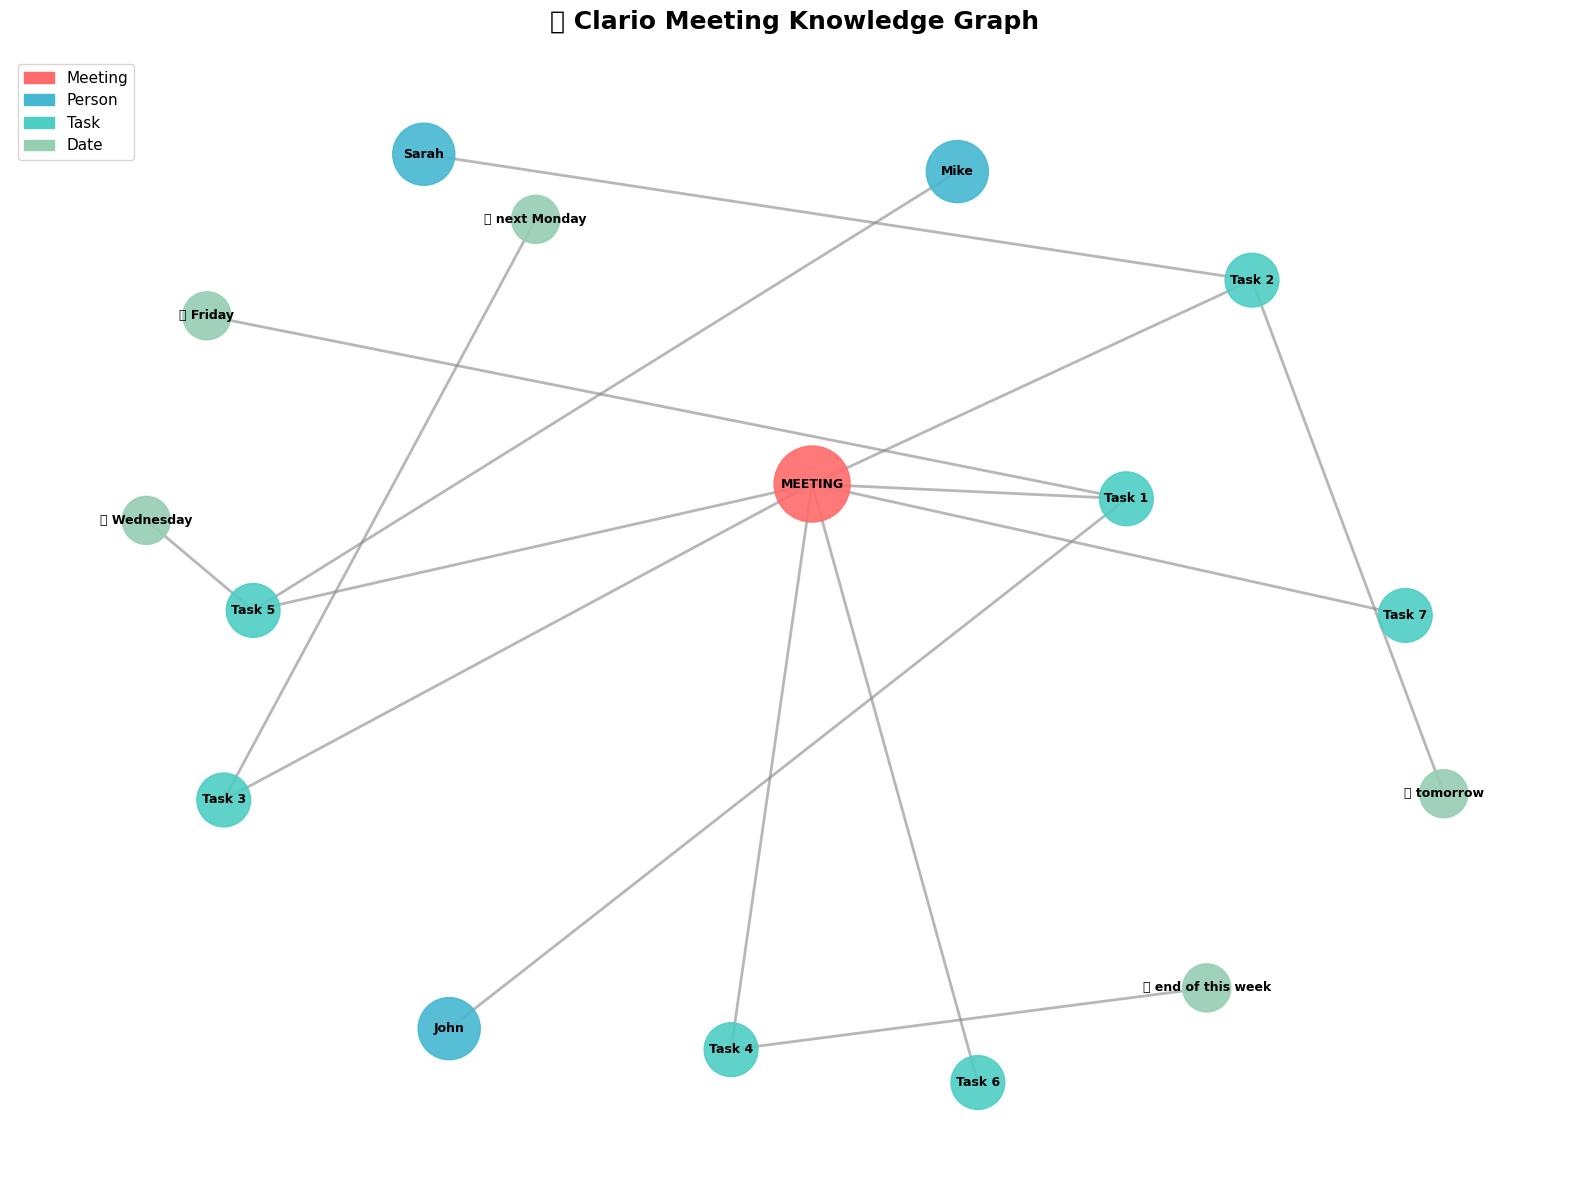


✅ Knowledge graph created and saved!
📊 Graph Stats:
  Nodes (dots): 16
  Edges (connections): 15
💾 Saved to: /content/drive/Shareddrives/clario_fyp_1/clario_project/graphs/knowledge_graph.png


In [115]:
# ============================================================
# KNOWLEDGE GRAPH WITH NETWORKX
# Person 3 leads this step
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

print("Building knowledge graph...")

# Load our detected tasks
with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/detected_tasks.json', 'r') as f:
    tasks = json.load(f)

# Create a new graph object
# Think of a graph as a map with dots (nodes) and lines (edges)
G = nx.Graph()

# ---- ADD NODES AND EDGES ----

# Add the central meeting node
G.add_node("MEETING", type="meeting", color="#FF6B6B")

# Color codes for different types of nodes
node_colors_map = {}
node_sizes_map = {}

# Add meeting as big red node
node_colors_map["MEETING"] = "#FF6B6B"
node_sizes_map["MEETING"] = 3000

for task in tasks:
    task_id = f"Task {task['id']}"
    person = task['assigned_to']
    date = task['due_date']

    # Add TASK node
    G.add_node(task_id, type="task")
    node_colors_map[task_id] = "#4ECDC4"  # teal for tasks
    node_sizes_map[task_id] = 1500

    # Connect task to meeting
    G.add_edge("MEETING", task_id)

    # Add PERSON node (if not already added)
    if person != "Unknown":
        G.add_node(person, type="person")
        node_colors_map[person] = "#45B7D1"  # blue for people
        node_sizes_map[person] = 2000

        # Connect person to their task
        G.add_edge(person, task_id)

    # Add DATE node (if not already added)
    if date != "Not specified":
        date_label = f"📅 {date}"
        G.add_node(date_label, type="date")
        node_colors_map[date_label] = "#96CEB4"  # green for dates
        node_sizes_map[date_label] = 1200

        # Connect task to date
        G.add_edge(task_id, date_label)

# ---- DRAW THE GRAPH ----
plt.figure(figsize=(16, 12))
plt.title("🕸️ Clario Meeting Knowledge Graph", fontsize=18, fontweight='bold', pad=20)

# Choose layout (how nodes are arranged)
pos = nx.spring_layout(G, seed=42, k=2)

# Get colors and sizes in the right order
nodes = list(G.nodes())
colors = [node_colors_map.get(n, "#CCCCCC") for n in nodes]
sizes = [node_sizes_map.get(n, 1000) for n in nodes]

# Draw the graph
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='#888888', alpha=0.6, width=2)

# Add legend
legend_elements = [
    mpatches.Patch(color='#FF6B6B', label='Meeting'),
    mpatches.Patch(color='#45B7D1', label='Person'),
    mpatches.Patch(color='#4ECDC4', label='Task'),
    mpatches.Patch(color='#96CEB4', label='Date'),
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=11)

plt.axis('off')
plt.tight_layout()

# Save graph image
graph_path = '/content/drive/Shareddrives/clario_fyp_1/clario_project/graphs/knowledge_graph.png'
plt.savefig(graph_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Knowledge graph created and saved!")
print(f"📊 Graph Stats:")
print(f"  Nodes (dots): {G.number_of_nodes()}")
print(f"  Edges (connections): {G.number_of_edges()}")
print(f"💾 Saved to: {graph_path}")

In [116]:
# ============================================================
# SQLITE DATABASE
# Person 3 leads this step
# ============================================================

import sqlite3
import json
import os
from datetime import datetime

# Path to our database file
DB_PATH = '/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db'

print("Setting up Clario database...")

# Connect to database (creates it if it doesn't exist)
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

print("✅ Database connected")

# ---- CREATE TABLES ----

# Table 1: Meetings
cursor.execute('''
CREATE TABLE IF NOT EXISTS meetings (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    meeting_date TEXT,
    transcript TEXT,
    summary TEXT,
    audio_file TEXT,
    created_at TEXT
)
''')

# Table 2: Tasks
cursor.execute('''
CREATE TABLE IF NOT EXISTS tasks (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    meeting_id INTEGER,
    description TEXT,
    assigned_to TEXT,
    due_date TEXT,
    status TEXT DEFAULT 'pending',
    keyword TEXT,
    created_at TEXT,
    FOREIGN KEY (meeting_id) REFERENCES meetings(id)
)
''')

# Table 3: People
cursor.execute('''
CREATE TABLE IF NOT EXISTS people (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT UNIQUE,
    total_tasks INTEGER DEFAULT 0
)
''')

conn.commit()
print("✅ All tables created")

# ---- INSERT DATA ----

# Read our results
with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/meeting_transcript.txt', 'r') as f:
    transcript = f.read()

with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/summaries/meeting_summary.txt', 'r') as f:
    summary = f.read()

with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/detected_tasks.json', 'r') as f:
    tasks = json.load(f)

# Insert meeting record
cursor.execute('''
INSERT INTO meetings (meeting_date, transcript, summary, audio_file, created_at)
VALUES (?, ?, ?, ?, ?)
''', (
    datetime.now().strftime("%Y-%m-%d"),
    transcript,
    summary,
    'sample_meeting.mp3',
    datetime.now().strftime("%Y-%m-%d %H:%M:%S")
))

meeting_id = cursor.lastrowid
print(f"✅ Meeting inserted with ID: {meeting_id}")

# Insert tasks
for task in tasks:
    cursor.execute('''
    INSERT INTO tasks (meeting_id, description, assigned_to, due_date, keyword, created_at)
    VALUES (?, ?, ?, ?, ?, ?)
    ''', (
        meeting_id,
        task['description'],
        task['assigned_to'],
        task['due_date'],
        task.get('keyword', ''),
        datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    ))

    # Also add to people table
    if task['assigned_to'] != 'Unknown':
        cursor.execute('''
        INSERT OR IGNORE INTO people (name, total_tasks) VALUES (?, 0)
        ''', (task['assigned_to'],))

        cursor.execute('''
        UPDATE people SET total_tasks = total_tasks + 1 WHERE name = ?
        ''', (task['assigned_to'],))

conn.commit()
print("✅ All tasks inserted")

# ---- VIEW DATABASE CONTENTS ----
print("\n" + "="*60)
print("📊 DATABASE CONTENTS")
print("="*60)

print("\n📌 MEETINGS TABLE:")
cursor.execute("SELECT id, meeting_date, created_at FROM meetings")
for row in cursor.fetchall():
    print(f"  ID: {row[0]} | Date: {row[1]} | Created: {row[2]}")

print("\n📌 TASKS TABLE:")
cursor.execute("SELECT id, description, assigned_to, due_date, status FROM tasks")
for row in cursor.fetchall():
    desc = row[1][:50] + "..." if len(row[1]) > 50 else row[1]
    print(f"  ID:{row[0]} | {desc} | 👤{row[2]} | 📅{row[3]} | {row[4]}")

print("\n📌 PEOPLE TABLE:")
cursor.execute("SELECT name, total_tasks FROM people ORDER BY total_tasks DESC")
for row in cursor.fetchall():
    print(f"  👤 {row[0]}: {row[1]} task(s)")

conn.close()
print(f"\n💾 Database saved to: {DB_PATH}")
print("✅ Database setup complete!")

Setting up Clario database...
✅ Database connected
✅ All tables created
✅ Meeting inserted with ID: 4
✅ All tasks inserted

📊 DATABASE CONTENTS

📌 MEETINGS TABLE:
  ID: 1 | Date: 2026-04-29 | Created: 2026-04-29 07:11:10
  ID: 2 | Date: 2026-04-29 | Created: 2026-04-29 07:12:20
  ID: 3 | Date: 2026-04-29 | Created: 2026-04-29 07:12:47
  ID: 4 | Date: 2026-04-29 | Created: 2026-04-29 08:55:19

📌 TASKS TABLE:
  ID:1 | First, John will complete the database setup by Fr... | 👤John | 📅Friday | pending
  ID:2 | Sarah needs to review the design mock-ups and send... | 👤Sarah | 📅tomorrow | pending
  ID:3 | We also need to schedule a follow-up meeting for n... | 👤Unknown | 📅next Monday | pending
  ID:4 | The budget report must be submitted to management ... | 👤Unknown | 📅end of this week | pending
  ID:5 | Mike will handle the client presentation on Wednes... | 👤Mike | 📅Wednesday | pending
  ID:6 | Please make sure all team members review the proje... | 👤Unknown | 📅Not specified | pending
  ID:7

In [117]:
# ============================================================
# HELPER FUNCTIONS TO QUERY THE DATABASE
# ============================================================

import sqlite3

DB_PATH = '/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db'

def get_all_meetings():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM meetings")
    rows = cursor.fetchall()
    conn.close()
    return rows

def get_tasks_by_person(person_name):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute(
        "SELECT * FROM tasks WHERE assigned_to = ?",
        (person_name,)
    )
    rows = cursor.fetchall()
    conn.close()
    return rows

def get_pending_tasks():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM tasks WHERE status = 'pending'")
    rows = cursor.fetchall()
    conn.close()
    return rows

def mark_task_complete(task_id):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute(
        "UPDATE tasks SET status = 'completed' WHERE id = ?",
        (task_id,)
    )
    conn.commit()
    conn.close()
    print(f"✅ Task {task_id} marked as complete!")

# Test the functions
print("Testing database query functions...\n")

print("📋 All Pending Tasks:")
pending = get_pending_tasks()
for task in pending:
    print(f"  ID:{task[0]} | 👤{task[3]} | 📅{task[4]}")

print(f"\nTotal pending tasks: {len(pending)}")

print("\n✅ Database query functions work perfectly!")

Testing database query functions...

📋 All Pending Tasks:
  ID:1 | 👤John | 📅Friday
  ID:2 | 👤Sarah | 📅tomorrow
  ID:3 | 👤Unknown | 📅next Monday
  ID:4 | 👤Unknown | 📅end of this week
  ID:5 | 👤Mike | 📅Wednesday
  ID:6 | 👤Unknown | 📅Not specified
  ID:7 | 👤Unknown | 📅Not specified
  ID:8 | 👤Yamna | 📅tomorrow
  ID:9 | 👤Unknown | 📅tonight
  ID:10 | 👤Unknown | 📅Wednesday
  ID:11 | 👤Unknown | 📅next Monday
  ID:12 | 👤Unknown | 📅today
  ID:13 | 👤Unknown | 📅Friday
  ID:14 | 👤Unknown | 📅end of this week
  ID:15 | 👤Yamna | 📅Not specified
  ID:16 | 👤Unknown | 📅quarterly
  ID:17 | 👤John | 📅Friday
  ID:18 | 👤Sarah | 📅Thursday
  ID:19 | 👤Mike | 📅Not specified
  ID:20 | 👤Unknown | 📅tomorrow
  ID:21 | 👤Unknown | 📅next Tuesday
  ID:22 | 👤Unknown | 📅end of this week
  ID:23 | 👤Unknown | 📅Not specified
  ID:24 | 👤Mike | 📅Not specified
  ID:25 | 👤Sarah | 📅Not specified
  ID:26 | 👤John | 📅Friday
  ID:27 | 👤Sarah | 📅tomorrow
  ID:28 | 👤Unknown | 📅next Monday
  ID:29 | 👤Unknown | 📅end of this week
  ID:30 | 👤

In [118]:
# ============================================================
# ROUGE EVALUATION - How good is our summary?
# Person 1 leads this step
# ============================================================

from rouge_score import rouge_scorer

print("=" * 60)
print("📊 ROUGE EVALUATION")
print("=" * 60)
print("""
What is ROUGE?
ROUGE measures how much the AI summary overlaps with a
'reference' (human-written) summary.

Scores range from 0 to 1:
  0.0 = completely different
  1.0 = perfect match
  0.3+ = generally acceptable
  0.5+ = good
""")

# Our AI-generated summary
with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/summaries/meeting_summary.txt', 'r') as f:
    ai_summary = f.read()

# A human reference summary (what a human would write)
reference_summary = """
The team meeting covered project assignments and deadlines.
John must complete the database setup by Friday.
Sarah needs to review design mockups and send feedback by tomorrow.
A follow-up meeting is scheduled for next Monday at 10 AM.
The budget report must be submitted by end of week.
Mike will handle the client presentation on Wednesday.
"""

print("📄 AI-Generated Summary:")
print(ai_summary)
print("\n📄 Human Reference Summary:")
print(reference_summary)

# Calculate ROUGE scores
scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

scores = scorer.score(reference_summary, ai_summary)

print("\n" + "=" * 60)
print("📊 ROUGE SCORES:")
print("=" * 60)

metrics = {
    'ROUGE-1': scores['rouge1'],
    'ROUGE-2': scores['rouge2'],
    'ROUGE-L': scores['rougeL']
}

for name, score in metrics.items():
    bar_length = int(score.fmeasure * 30)
    bar = "█" * bar_length + "░" * (30 - bar_length)
    print(f"\n{name}:")
    print(f"  Precision : {score.precision:.4f}")
    print(f"  Recall    : {score.recall:.4f}")
    print(f"  F-Measure : {score.fmeasure:.4f}")
    print(f"  [{bar}] {score.fmeasure:.2%}")

# Interpretation
avg_f = sum(s.fmeasure for s in scores.values()) / 3
print(f"\n📈 Average F-Measure: {avg_f:.4f}")

if avg_f >= 0.5:
    print("🟢 Evaluation: GOOD - Summary captures key information well")
elif avg_f >= 0.3:
    print("🟡 Evaluation: ACCEPTABLE - Summary is reasonable")
else:
    print("🔴 Evaluation: NEEDS IMPROVEMENT - Summary misses key points")

# Save scores
import json
rouge_results = {
    'rouge1_f': scores['rouge1'].fmeasure,
    'rouge2_f': scores['rouge2'].fmeasure,
    'rougeL_f': scores['rougeL'].fmeasure,
    'average_f': avg_f
}

with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/rouge_scores.json', 'w') as f:
    json.dump(rouge_results, f, indent=4)

print(f"\n💾 Scores saved to: /content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/rouge_scores.json")
print("✅ ROUGE Evaluation complete!")

📊 ROUGE EVALUATION

What is ROUGE?
ROUGE measures how much the AI summary overlaps with a
'reference' (human-written) summary.

Scores range from 0 to 1:
  0.0 = completely different
  1.0 = perfect match
  0.3+ = generally acceptable
  0.5+ = good

📄 AI-Generated Summary:
John will complete the database setup by Friday. Sarah needs to review the design mock-ups and send feedback to the team by tomorrow. The budget report must be submitted to management by end of this week. Mike will handle the client presentation on Wednesday.

📄 Human Reference Summary:

The team meeting covered project assignments and deadlines.
John must complete the database setup by Friday.
Sarah needs to review design mockups and send feedback by tomorrow.
A follow-up meeting is scheduled for next Monday at 10 AM.
The budget report must be submitted by end of week.
Mike will handle the client presentation on Wednesday.


📊 ROUGE SCORES:

ROUGE-1:
  Precision : 0.8222
  Recall    : 0.6491
  F-Measure : 0.7255
  [

In [119]:
# ============================================================
# F1 SCORE EVALUATION - How good is our task detection?
# Person 2 leads this step
# ============================================================

import json

print("=" * 60)
print("📊 F1 SCORE EVALUATION")
print("=" * 60)
print("""
What is F1 Score?
F1 measures how well our task detector works.

It combines two things:
  Precision = Of all detected tasks, how many are REAL tasks?
  Recall    = Of all real tasks, how many did we FIND?
  F1        = Balance between Precision and Recall

Scores range from 0 to 1:
  0.0 = completely wrong
  1.0 = perfect
  0.7+ = good
""")

# GROUND TRUTH = the tasks a human would identify (correct answers)
ground_truth_tasks = [
    "John will complete the database setup by Friday",
    "Sarah needs to review the design mockups and send feedback to the team by tomorrow",
    "We need to schedule a follow-up meeting for next Monday at 10 AM",
    "The budget report must be submitted to management by end of this week",
    "Mike will handle the client presentation on Wednesday",
    "Please make sure all team members review the project timeline",
    "Let's also fix the login bug in the application before the deadline"
]

# Load our AI-detected tasks
with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/detected_tasks.json', 'r') as f:
    detected_tasks = json.load(f)

detected_descriptions = [t['description'] for t in detected_tasks]

print(f"✅ Ground truth tasks (human-labeled): {len(ground_truth_tasks)}")
print(f"🤖 AI detected tasks: {len(detected_tasks)}")

# Calculate True Positives, False Positives, False Negatives
true_positives = 0
false_positives = 0
false_negatives = 0

matched_gt = []
matched_detected = []

# Simple matching: check if any detected task overlaps with ground truth
for gt_task in ground_truth_tasks:
    gt_words = set(gt_task.lower().split())

    matched = False
    for det_task in detected_descriptions:
        det_words = set(det_task.lower().split())

        # Calculate word overlap
        overlap = len(gt_words.intersection(det_words))
        overlap_ratio = overlap / max(len(gt_words), 1)

        if overlap_ratio > 0.4:  # 40% word overlap = match
            matched = True
            if gt_task not in matched_gt:
                matched_gt.append(gt_task)
            break

    if matched:
        true_positives += 1
    else:
        false_negatives += 1

# False positives = detected tasks that don't match any ground truth
for det_task in detected_descriptions:
    det_words = set(det_task.lower().split())
    matched = False

    for gt_task in ground_truth_tasks:
        gt_words = set(gt_task.lower().split())
        overlap = len(gt_words.intersection(det_words))
        overlap_ratio = overlap / max(len(det_words), 1)

        if overlap_ratio > 0.4:
            matched = True
            break

    if not matched:
        false_positives += 1

# Calculate metrics
precision = true_positives / max(true_positives + false_positives, 1)
recall = true_positives / max(true_positives + false_negatives, 1)
f1 = 2 * (precision * recall) / max(precision + recall, 0.0001)

print("\n" + "=" * 60)
print("📊 F1 EVALUATION RESULTS:")
print("=" * 60)
print(f"\n  True Positives  (correctly found tasks) : {true_positives}")
print(f"  False Positives (wrongly detected)      : {false_positives}")
print(f"  False Negatives (missed real tasks)     : {false_negatives}")
print(f"\n  Precision : {precision:.4f} ({precision:.2%})")
print(f"  Recall    : {recall:.4f} ({recall:.2%})")
print(f"  F1 Score  : {f1:.4f} ({f1:.2%})")

p_bar = "█" * int(precision * 30) + "░" * (30 - int(precision * 30))
r_bar = "█" * int(recall * 30) + "░" * (30 - int(recall * 30))
f_bar = "█" * int(f1 * 30) + "░" * (30 - int(f1 * 30))

print(f"\n  Precision [{p_bar}] {precision:.2%}")
print(f"  Recall    [{r_bar}] {recall:.2%}")
print(f"  F1 Score  [{f_bar}] {f1:.2%}")

if f1 >= 0.7:
    print("\n🟢 Evaluation: GOOD - Task detection is performing well")
elif f1 >= 0.5:
    print("\n🟡 Evaluation: ACCEPTABLE - Task detection is reasonable")
else:
    print("\n🔴 Evaluation: NEEDS IMPROVEMENT")

# Save scores
import json
f1_results = {
    'true_positives': true_positives,
    'false_positives': false_positives,
    'false_negatives': false_negatives,
    'precision': precision,
    'recall': recall,
    'f1_score': f1
}

with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/f1_scores.json', 'w') as f:
    json.dump(f1_results, f, indent=4)

print(f"\n💾 Scores saved to: /content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/f1_scores.json")
print("✅ F1 Evaluation complete!")

📊 F1 SCORE EVALUATION

What is F1 Score?
F1 measures how well our task detector works.

It combines two things:
  Precision = Of all detected tasks, how many are REAL tasks?
  Recall    = Of all real tasks, how many did we FIND?
  F1        = Balance between Precision and Recall

Scores range from 0 to 1:
  0.0 = completely wrong
  1.0 = perfect
  0.7+ = good

✅ Ground truth tasks (human-labeled): 7
🤖 AI detected tasks: 7

📊 F1 EVALUATION RESULTS:

  True Positives  (correctly found tasks) : 7
  False Positives (wrongly detected)      : 0
  False Negatives (missed real tasks)     : 0

  Precision : 1.0000 (100.00%)
  Recall    : 1.0000 (100.00%)
  F1 Score  : 1.0000 (100.00%)

  Precision [██████████████████████████████] 100.00%
  Recall    [██████████████████████████████] 100.00%
  F1 Score  [██████████████████████████████] 100.00%

🟢 Evaluation: GOOD - Task detection is performing well

💾 Scores saved to: /content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/f1_scores.js

In [120]:
# ============================================================
# ROBUST PIPELINE WITH ERROR HANDLING
# All three run this together
# ============================================================

import whisper
import spacy
import re
import json
import os
import sqlite3
import traceback
from transformers import pipeline as hf_pipeline
from datetime import datetime

# Load models safely
def load_models_safely():
    models = {}
    errors = []

    try:
        print("Loading Whisper...")
        models['whisper'] = whisper.load_model("base")
        print("✅ Whisper OK")
    except Exception as e:
        errors.append(f"Whisper: {e}")
        print(f"❌ Whisper failed: {e}")

    try:
        print("Loading spaCy...")
        models['nlp'] = spacy.load("en_core_web_sm")
        print("✅ spaCy OK")
    except Exception as e:
        errors.append(f"spaCy: {e}")
        print(f"❌ spaCy failed: {e}")

    try:
        print("Loading BART...")
        models['summarizer'] = hf_pipeline(
            "summarization",
            model="facebook/bart-large-cnn",
            device=-1
        )
        print("✅ BART OK")
    except Exception as e:
        errors.append(f"BART: {e}")
        print(f"❌ BART failed: {e}")

    if errors:
        print(f"\n⚠️ {len(errors)} model(s) failed to load")
    else:
        print("\n🎉 All models loaded successfully!")

    return models, errors

models, load_errors = load_models_safely()

Loading Whisper...
✅ Whisper OK
Loading spaCy...
✅ spaCy OK
Loading BART...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✅ BART OK

🎉 All models loaded successfully!


In [121]:
# ============================================================
# COMPLETE SYSTEM TEST
# Tests every component one by one
# ============================================================

test_text = """
Alice will prepare the quarterly report by next Monday.
Bob needs to fix the critical bug in the login system by tomorrow morning.
Carol must review the design proposals and send feedback to the team by Friday.
We should schedule a demo with the client for next week.
Everyone please update their status in the project tracker.
The deployment must happen before the end of this month.
"""

print("=" * 60)
print("🧪 CLARIO SYSTEM TEST")
print("=" * 60)

test_results = {}

# Test 1: spaCy task detection
print("\n🧪 TEST 1: Task Detection")
try:
    nlp_model = models.get('nlp')
    if nlp_model:
        doc = nlp_model(test_text)
        sentences = list(doc.sents)
        print(f"  ✅ spaCy processed {len(sentences)} sentences")
        test_results['spacy'] = 'PASSED'
    else:
        print("  ❌ spaCy model not loaded")
        test_results['spacy'] = 'FAILED'
except Exception as e:
    print(f"  ❌ spaCy test failed: {e}")
    test_results['spacy'] = 'FAILED'

# Test 2: BART summarization
print("\n🧪 TEST 2: Summarization")
try:
    summarizer_model = models.get('summarizer')
    if summarizer_model:
        result = summarizer_model(
            test_text[:500],
            max_length=100,
            min_length=30,
            do_sample=False
        )
        summary = result[0]['summary_text']
        print(f"  ✅ Summary generated ({len(summary)} chars)")
        print(f"  Preview: {summary[:100]}...")
        test_results['bart'] = 'PASSED'
    else:
        print("  ❌ BART model not loaded")
        test_results['bart'] = 'FAILED'
except Exception as e:
    print(f"  ❌ BART test failed: {e}")
    test_results['bart'] = 'FAILED'

# Test 3: Database
print("\n🧪 TEST 3: Database")
try:
    conn = sqlite3.connect('/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db')
    cursor = conn.cursor()
    cursor.execute("SELECT COUNT(*) FROM meetings")
    count = cursor.fetchone()[0]
    print(f"  ✅ Database accessible, {count} meeting(s) stored")
    conn.close()
    test_results['database'] = 'PASSED'
except Exception as e:
    print(f"  ❌ Database test failed: {e}")
    test_results['database'] = 'FAILED'

# Test 4: File system
print("\n🧪 TEST 4: File System")
required_files = [
    '/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/meeting_transcript.txt',
    '/content/drive/Shareddrives/clario_fyp_1/clario_project/summaries/meeting_summary.txt',
    '/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/detected_tasks.json',
    '/content/drive/Shareddrives/clario_fyp_1/clario_project/graphs/knowledge_graph.png',
    '/content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/rouge_scores.json',
    '/content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/f1_scores.json',
]

all_files_ok = True
for filepath in required_files:
    if os.path.exists(filepath):
        size = os.path.getsize(filepath)
        print(f"  ✅ {os.path.basename(filepath)} ({size} bytes)")
    else:
        print(f"  ❌ MISSING: {filepath}")
        all_files_ok = False

test_results['filesystem'] = 'PASSED' if all_files_ok else 'PARTIAL'

# Test 5: Regex task detection
print("\n🧪 TEST 5: Regex Pattern Matching")
try:
    task_keywords = [r'\bwill\b', r'\bneeds? to\b', r'\bmust\b', r'\bshould\b']
    found_tasks = 0
    for sentence in test_text.split('.'):
        for kw in task_keywords:
            if re.search(kw, sentence.lower()):
                found_tasks += 1
                break
    print(f"  ✅ Regex found {found_tasks} potential tasks in test text")
    test_results['regex'] = 'PASSED'
except Exception as e:
    print(f"  ❌ Regex test failed: {e}")
    test_results['regex'] = 'FAILED'

# Final Report
print("\n" + "=" * 60)
print("📊 TEST RESULTS SUMMARY")
print("=" * 60)

passed = sum(1 for v in test_results.values() if v == 'PASSED')
total = len(test_results)

for test_name, result in test_results.items():
    icon = "✅" if result == "PASSED" else "⚠️" if result == "PARTIAL" else "❌"
    print(f"  {icon} {test_name.upper():15} : {result}")

print(f"\n  Score: {passed}/{total} tests passed")

if passed == total:
    print("\n🎉 ALL TESTS PASSED! Clario is working perfectly!")
elif passed >= total * 0.7:
    print("\n🟡 Most tests passed. Check failed items above.")
else:
    print("\n🔴 Several tests failed. Review steps above.")

Your max_length is set to 100, but your input_length is only 84. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=42)


🧪 CLARIO SYSTEM TEST

🧪 TEST 1: Task Detection
  ✅ spaCy processed 6 sentences

🧪 TEST 2: Summarization
  ✅ Summary generated (210 chars)
  Preview: Bob needs to fix the critical bug in the login system by tomorrow morning. Carol must review the des...

🧪 TEST 3: Database
  ✅ Database accessible, 4 meeting(s) stored

🧪 TEST 4: File System
  ✅ meeting_transcript.txt (582 bytes)
  ✅ meeting_summary.txt (259 bytes)
  ✅ detected_tasks.json (1530 bytes)
  ✅ knowledge_graph.png (256962 bytes)
  ✅ rouge_scores.json (133 bytes)
  ✅ f1_scores.json (141 bytes)

🧪 TEST 5: Regex Pattern Matching
  ✅ Regex found 5 potential tasks in test text

📊 TEST RESULTS SUMMARY
  ✅ SPACY           : PASSED
  ✅ BART            : PASSED
  ✅ DATABASE        : PASSED
  ✅ FILESYSTEM      : PASSED
  ✅ REGEX           : PASSED

  Score: 5/5 tests passed

🎉 ALL TESTS PASSED! Clario is working perfectly!


In [122]:
!pip install pyngrok -q

from pyngrok import ngrok

# 🔴 PASTE YOUR TOKEN BELOW
ngrok.set_auth_token("3CkqIu2jfDfAGDairXNlTvuoN4i_6LTZrzAARpySXxCCE7F6m")

In [123]:
# ============================================================
# CREATE STREAMLIT DASHBOARD FILE
# This writes our entire app to a file
# ============================================================

dashboard_code = '''
import streamlit as st
import sqlite3
import json
import os
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from wordcloud import WordCloud

# ---- PAGE CONFIGURATION ----
st.set_page_config(
    page_title="Clario - Smart Meeting Assistant",
    page_icon="🧠",
    layout="wide"
)

DB_PATH = "/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db"

# ---- DATABASE HELPERS ----
def get_db_connection():
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    return conn

def get_meetings():
    try:
        conn = get_db_connection()
        meetings = conn.execute("SELECT * FROM meetings ORDER BY created_at DESC").fetchall()
        conn.close()
        return meetings
    except:
        return []

def get_tasks(meeting_id=None):
    try:
        conn = get_db_connection()
        if meeting_id:
            tasks = conn.execute(
                "SELECT * FROM tasks WHERE meeting_id = ? ORDER BY id",
                (meeting_id,)
            ).fetchall()
        else:
            tasks = conn.execute("SELECT * FROM tasks ORDER BY id").fetchall()
        conn.close()
        return tasks
    except:
        return []

def get_people():
    try:
        conn = get_db_connection()
        people = conn.execute("SELECT * FROM people ORDER BY total_tasks DESC").fetchall()
        conn.close()
        return people
    except:
        return []

def update_task_status(task_id, status):
    conn = get_db_connection()
    conn.execute("UPDATE tasks SET status = ? WHERE id = ?", (status, task_id))
    conn.commit()
    conn.close()

# ---- SIDEBAR ----
st.sidebar.image("https://img.icons8.com/fluency/96/000000/brain.png", width=80)
st.sidebar.title("🧠 Clario")
st.sidebar.markdown("**AI-Powered Meeting Assistant**")
st.sidebar.markdown("---")

page = st.sidebar.radio(
    "Navigate",
    ["🏠 Dashboard", "📄 Meetings", "✅ Tasks", "👥 Team", "📊 Evaluation", "🕸️ Knowledge Graph"]
)

st.sidebar.markdown("---")
st.sidebar.info("Built with Whisper + BART + spaCy")

# ==============================
# PAGE 1: DASHBOARD
# ==============================
if page == "🏠 Dashboard":
    st.title("🧠 Clario — Smart Meeting Assistant")
    st.markdown("#### AI-powered tool to transcribe, summarize, and extract action items from meetings")
    st.markdown("---")

    meetings = get_meetings()
    tasks = get_tasks()
    people = get_people()

    pending_tasks = [t for t in tasks if t["status"] == "pending"]
    completed_tasks = [t for t in tasks if t["status"] == "completed"]

    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.metric("📅 Total Meetings", len(meetings))
    with col2:
        st.metric("📋 Total Tasks", len(tasks))
    with col3:
        st.metric("⏳ Pending Tasks", len(pending_tasks))
    with col4:
        st.metric("✅ Completed Tasks", len(completed_tasks))

    st.markdown("---")

    if meetings:
        st.subheader("📋 Latest Meeting Summary")
        latest = meetings[0]
        st.info(f"**Date:** {latest['meeting_date']}")
        if latest["summary"]:
            st.success(latest["summary"])

        st.subheader("🎯 Latest Action Items")
        latest_tasks = get_tasks(latest["id"])
        if latest_tasks:
            for task in latest_tasks:
                icon = "✅" if task["status"] == "completed" else "⏳"
                st.markdown(f"{icon} **{task['assigned_to']}** — {task['description'][:80]}... *(Due: {task['due_date']})*")
        else:
            st.info("No tasks found for this meeting.")

        if latest["transcript"]:
            st.subheader("☁️ Word Cloud")
            try:
                wc = WordCloud(
                    width=800, height=300,
                    background_color="white",
                    colormap="viridis"
                ).generate(latest["transcript"])
                fig, ax = plt.subplots(figsize=(10, 4))
                ax.imshow(wc, interpolation="bilinear")
                ax.axis("off")
                st.pyplot(fig)
            except Exception as e:
                st.warning(f"Word cloud unavailable: {e}")
    else:
        st.warning("No meetings in database yet. Run the pipeline first!")

# ==============================
# PAGE 2: MEETINGS
# ==============================
elif page == "📄 Meetings":
    st.title("📄 Meeting History")
    st.markdown("---")

    meetings = get_meetings()

    if not meetings:
        st.warning("No meetings found. Run the pipeline first.")
    else:
        for meeting in meetings:
            with st.expander(f"📅 Meeting on {meeting['meeting_date']} (ID: {meeting['id']})"):
                tab1, tab2, tab3 = st.tabs(["📝 Transcript", "📋 Summary", "✅ Tasks"])

                with tab1:
                    st.markdown("**Full Transcript:**")
                    st.text_area("", meeting["transcript"] or "No transcript", height=200, key=f"t_{meeting['id']}")

                with tab2:
                    st.markdown("**AI-Generated Summary:**")
                    st.info(meeting["summary"] or "No summary available")

                with tab3:
                    tasks = get_tasks(meeting["id"])
                    if tasks:
                        for task in tasks:
                            status_color = "🟢" if task["status"] == "completed" else "🔴"
                            st.markdown(f"{status_color} **Task #{task['id']}:** {task['description']}")
                            st.markdown(f"   👤 **Assigned:** {task['assigned_to']} | 📅 **Due:** {task['due_date']} | 🏷️ **Status:** {task['status']}")
                            st.markdown("---")
                    else:
                        st.info("No tasks for this meeting")

# ==============================
# PAGE 3: TASKS
# ==============================
elif page == "✅ Tasks":
    st.title("✅ Task Manager")
    st.markdown("---")

    tasks = get_tasks()

    if not tasks:
        st.warning("No tasks found. Run the pipeline first.")
    else:
        status_filter = st.selectbox("Filter by status:", ["all", "pending", "completed"])

        if status_filter != "all":
            filtered = [t for t in tasks if t["status"] == status_filter]
        else:
            filtered = tasks

        st.markdown(f"Showing **{len(filtered)}** task(s)")
        st.markdown("---")

        for task in filtered:
            col1, col2 = st.columns([4, 1])
            with col1:
                icon = "✅" if task["status"] == "completed" else "⏳"
                st.markdown(f"{icon} **Task #{task['id']}**")
                st.markdown(f"📝 {task['description']}")
                st.markdown(f"👤 **{task['assigned_to']}** | 📅 **{task['due_date']}** | Status: **{task['status']}**")

            with col2:
                if task["status"] == "pending":
                    if st.button(f"Mark Done", key=f"done_{task['id']}"):
                        update_task_status(task["id"], "completed")
                        st.success("Marked complete!")
                        st.rerun()
                else:
                    if st.button(f"Reopen", key=f"reopen_{task['id']}"):
                        update_task_status(task["id"], "pending")
                        st.rerun()
            st.markdown("---")

# ==============================
# PAGE 4: TEAM
# ==============================
elif page == "👥 Team":
    st.title("👥 Team Overview")
    st.markdown("---")

    people = get_people()
    tasks = get_tasks()

    if not people:
        st.warning("No team data. Run the pipeline first.")
    else:
        cols = st.columns(len(people)) if len(people) <= 4 else st.columns(4)
        for i, person in enumerate(people):
            with cols[i % 4]:
                person_tasks = [t for t in tasks if t["assigned_to"] == person["name"]]
                done = len([t for t in person_tasks if t["status"] == "completed"])
                total = person["total_tasks"]
                st.metric(f"👤 {person['name']}", f"{total} tasks", f"{done} done")

        st.markdown("---")
        st.subheader("Tasks by Person")

        for person in people:
            with st.expander(f"👤 {person['name']} — {person['total_tasks']} task(s)"):
                person_tasks = [t for t in tasks if t["assigned_to"] == person["name"]]
                for task in person_tasks:
                    icon = "✅" if task["status"] == "completed" else "⏳"
                    st.markdown(f"{icon} {task['description']}")
                    st.markdown(f"   📅 Due: {task['due_date']}")

# ==============================
# PAGE 5: EVALUATION
# ==============================
elif page == "📊 Evaluation":
    st.title("📊 AI Performance Evaluation")
    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("ROUGE Scores (Summarization)")
        rouge_path = "/content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/rouge_scores.json"
        if os.path.exists(rouge_path):
            with open(rouge_path) as f:
                rouge = json.load(f)
            st.metric("ROUGE-1", f"{rouge.get('rouge1_f', 0):.2%}")
            st.metric("ROUGE-2", f"{rouge.get('rouge2_f', 0):.2%}")
            st.metric("ROUGE-L", f"{rouge.get('rougeL_f', 0):.2%}")
            st.metric("Average", f"{rouge.get('average_f', 0):.2%}")
            avg = rouge.get("average_f", 0)
            if avg >= 0.5:
                st.success("🟢 Good summarization performance")
            elif avg >= 0.3:
                st.warning("🟡 Acceptable performance")
            else:
                st.error("🔴 Needs improvement")
        else:
            st.warning("Run Day 7 ROUGE evaluation first")

    with col2:
        st.subheader("F1 Score (Task Detection)")
        f1_path = "/content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/f1_scores.json"
        if os.path.exists(f1_path):
            with open(f1_path) as f:
                f1_data = json.load(f)
            st.metric("Precision", f"{f1_data.get('precision', 0):.2%}")
            st.metric("Recall", f"{f1_data.get('recall', 0):.2%}")
            st.metric("F1 Score", f"{f1_data.get('f1_score', 0):.2%}")
            f1 = f1_data.get("f1_score", 0)
            if f1 >= 0.7:
                st.success("🟢 Good detection performance")
            elif f1 >= 0.5:
                st.warning("🟡 Acceptable performance")
            else:
                st.error("🔴 Needs improvement")
        else:
            st.warning("Run Day 7 F1 evaluation first")

# ==============================
# PAGE 6: KNOWLEDGE GRAPH
# ==============================
elif page == "🕸️ Knowledge Graph":
    st.title("🕸️ Meeting Knowledge Graph")
    st.markdown("Visual map of people, tasks, and dates from the meeting")
    st.markdown("---")

    graph_path = "/content/drive/Shareddrives/clario_fyp_1/clario_project/graphs/knowledge_graph.png"
    if os.path.exists(graph_path):
        st.image(graph_path, use_column_width=True)
        st.success("This graph shows connections between people, their tasks, and deadlines.")
    else:
        st.warning("Knowledge graph not found. Run Day 5 step first.")
'''

# Write to file
with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/clario_app.py', 'w') as f:
    f.write(dashboard_code)

print("✅ Streamlit dashboard file created!")
print("📍 Location: /content/drive/Shareddrives/clario_fyp_1/clario_project/clario_app.py")
print(f"📏 File size: {os.path.getsize('/content/drive/Shareddrives/clario_fyp_1/clario_project/clario_app.py')} bytes")

✅ Streamlit dashboard file created!
📍 Location: /content/drive/Shareddrives/clario_fyp_1/clario_project/clario_app.py
📏 File size: 11353 bytes


In [124]:
# ============================================================
# LAUNCH STREAMLIT WITH PYNGROK
# This makes our app accessible from the internet
# ============================================================

import subprocess
import threading
import time
from pyngrok import ngrok

print("Starting Clario dashboard...\n")

# Kill any existing processes on port 8501
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(2)

# Start Streamlit in a background thread
def run_streamlit():
    os.system("streamlit run /content/drive/Shareddrives/clario_fyp_1/clario_project/clario_app.py --server.port 8501 --server.headless true &")

print("Launching Streamlit server...")
run_streamlit()
time.sleep(5)

# Create a public URL using ngrok
print("Creating public URL with ngrok...")

try:
    # Close existing tunnels
    ngrok.kill()
    time.sleep(2)

    # Open new tunnel
    public_url = ngrok.connect(8501)

    print("\n" + "=" * 60)
    print("🎉 CLARIO DASHBOARD IS LIVE!")
    print("=" * 60)
    print(f"\n🌐 Open this URL in your browser:")
    print(f"\n   👉 {public_url}")
    print("\n" + "=" * 60)
    print("Keep this cell running. Don't close it.")
    print("To stop: Runtime → Interrupt Execution")

except Exception as e:
    print(f"\n❌ ngrok error: {e}")
    print("\nTry this alternative - run in a new cell:")
    print("!streamlit run /content/drive/Shareddrives/clario_fyp_1/clario_project/app.py &")
    print("Then check the output for the local URL")

Starting Clario dashboard...

Launching Streamlit server...
Creating public URL with ngrok...

🎉 CLARIO DASHBOARD IS LIVE!

🌐 Open this URL in your browser:

   👉 NgrokTunnel: "https://gong-fasting-venue.ngrok-free.dev" -> "http://localhost:8501"

Keep this cell running. Don't close it.
To stop: Runtime → Interrupt Execution


In [125]:
# ============================================================
# FINAL DEMO CHECKLIST
# Run this before your demo to verify everything works
# ============================================================

import os
import sqlite3
import json

print("=" * 60)
print("🎯 CLARIO FINAL DEMO CHECKLIST")
print("=" * 60)

checks = []

# Check 1: All files exist
print("\n📁 Checking files...")
files = {
    'Transcript': '/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/meeting_transcript.txt',
    'Summary': '/content/drive/Shareddrives/clario_fyp_1/clario_project/summaries/meeting_summary.txt',
    'Tasks JSON': '/content/drive/Shareddrives/clario_fyp_1/clario_project/transcripts/detected_tasks.json',
    'Knowledge Graph': '/content/drive/Shareddrives/clario_fyp_1/clario_project/graphs/knowledge_graph.png',
    'ROUGE Scores': '/content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/rouge_scores.json',
    'F1 Scores': '/content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/f1_scores.json',
    'Dashboard': '/content/drive/Shareddrives/clario_fyp_1/clario_project/clario_app.py',
    'Database': '/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db',
}

for name, path in files.items():
    exists = os.path.exists(path)
    icon = "✅" if exists else "❌"
    print(f"  {icon} {name}")
    checks.append(exists)

# Check 2: Database has data
print("\n🗄️ Checking database...")
try:
    conn = sqlite3.connect('/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db')
    c = conn.cursor()
    c.execute("SELECT COUNT(*) FROM meetings")
    meetings = c.fetchone()[0]
    c.execute("SELECT COUNT(*) FROM tasks")
    tasks = c.fetchone()[0]
    c.execute("SELECT COUNT(*) FROM people")
    people = c.fetchone()[0]
    conn.close()
    print(f"  ✅ Meetings: {meetings}")
    print(f"  ✅ Tasks: {tasks}")
    print(f"  ✅ People: {people}")
    checks.append(True)
except Exception as e:
    print(f"  ❌ Database error: {e}")
    checks.append(False)

# Check 3: Evaluation scores
print("\n📊 Checking evaluation scores...")
try:
    with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/rouge_scores.json') as f:
        rouge = json.load(f)
    with open('/content/drive/Shareddrives/clario_fyp_1/clario_project/evaluation/f1_scores.json') as f:
        f1 = json.load(f)
    print(f"  ✅ ROUGE Average F: {rouge['average_f']:.2%}")
    print(f"  ✅ F1 Score: {f1['f1_score']:.2%}")
    checks.append(True)
except Exception as e:
    print(f"  ❌ Scores error: {e}")
    checks.append(False)

# Final result
passed = sum(checks)
total = len(checks)
print("\n" + "=" * 60)
print(f"📊 DEMO READINESS: {passed}/{total} checks passed")

if passed == total:
    print("""
🎉 CONGRATULATIONS! CLARIO IS DEMO-READY!

Your demo should cover:
  1. Show the Streamlit dashboard
  2. Explain Whisper transcription
  3. Show BART-generated summary
  4. Show detected tasks with people + dates
  5. Show the knowledge graph
  6. Show ROUGE and F1 evaluation scores
  7. Show the database with stored meetings

Well done Team Clario! 🚀
""")
elif passed >= total * 0.8:
    print("🟡 Almost ready! Fix the ❌ items above and re-run.")
else:
    print("🔴 Several issues found. Go back and fix ❌ items.")

print("=" * 60)

🎯 CLARIO FINAL DEMO CHECKLIST

📁 Checking files...
  ✅ Transcript
  ✅ Summary
  ✅ Tasks JSON
  ✅ Knowledge Graph
  ✅ ROUGE Scores
  ✅ F1 Scores
  ✅ Dashboard
  ✅ Database

🗄️ Checking database...
  ✅ Meetings: 4
  ✅ Tasks: 32
  ✅ People: 4

📊 Checking evaluation scores...
  ✅ ROUGE Average F: 65.73%
  ✅ F1 Score: 100.00%

📊 DEMO READINESS: 10/10 checks passed

🎉 CONGRATULATIONS! CLARIO IS DEMO-READY!

Your demo should cover:
  1. Show the Streamlit dashboard
  2. Explain Whisper transcription
  3. Show BART-generated summary
  4. Show detected tasks with people + dates
  5. Show the knowledge graph
  6. Show ROUGE and F1 evaluation scores
  7. Show the database with stored meetings

Well done Team Clario! 🚀



In [126]:
# ============================================================
# DAY 1 — STEP 1: Install Additional Libraries
# These are NEW libs added on top of your existing ones
# ============================================================

!pip install plotly -q          # Beautiful interactive charts
!pip install pandas -q          # Data manipulation for analytics
!pip install tabulate -q        # Pretty table printing

print('✅ Day 1 libraries installed!')

✅ Day 1 libraries installed!


In [127]:
# ============================================================
# DAY 1 — STEP 2: Upgrade Database Schema for Priority + Speaker
# SAFE: Only ADDs new columns, never touches existing data
# ============================================================

import sqlite3
import os

DB_PATH = '/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db'

print('Upgrading database schema...')
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# Add 'priority' column to tasks (HIGH / MEDIUM / LOW)
# We use try/except so it won't crash if column already exists
try:
    cursor.execute("ALTER TABLE tasks ADD COLUMN priority TEXT DEFAULT 'MEDIUM'")
    print('✅ Added priority column to tasks')
except sqlite3.OperationalError:
    print('ℹ️  priority column already exists — skipping')

# Add 'speaker' column to tasks
try:
    cursor.execute("ALTER TABLE tasks ADD COLUMN speaker TEXT DEFAULT 'Unknown'")
    print('✅ Added speaker column to tasks')
except sqlite3.OperationalError:
    print('ℹ️  speaker column already exists — skipping')

# Add 'meeting_title' column to meetings
try:
    cursor.execute("ALTER TABLE meetings ADD COLUMN meeting_title TEXT DEFAULT 'Team Meeting'")
    print('✅ Added meeting_title column to meetings')
except sqlite3.OperationalError:
    print('ℹ️  meeting_title column already exists — skipping')

# Add 'total_tasks' and 'completed_tasks' to meetings for quick stats
try:
    cursor.execute("ALTER TABLE meetings ADD COLUMN total_tasks INTEGER DEFAULT 0")
    print('✅ Added total_tasks column to meetings')
except sqlite3.OperationalError:
    print('ℹ️  total_tasks column already exists — skipping')

conn.commit()
conn.close()
print('\n✅ Database upgrade complete!')

Upgrading database schema...
ℹ️  priority column already exists — skipping
ℹ️  speaker column already exists — skipping
ℹ️  meeting_title column already exists — skipping
ℹ️  total_tasks column already exists — skipping

✅ Database upgrade complete!


In [128]:
# ============================================================
# DAY 1 — STEP 3: Priority Scoring Engine
# Uses keyword matching to assign HIGH / MEDIUM / LOW priority
# ============================================================

import re

def assign_priority(text):
    """
    Assigns priority to a task based on urgency keywords.
    Returns: 'HIGH', 'MEDIUM', or 'LOW'
    """
    text_lower = text.lower()

    # HIGH priority keywords — urgent, time-critical
    high_keywords = [
        r'\burgent\b', r'\basap\b', r'\bas soon as possible\b',
        r'\bimmediately\b', r'\bcritical\b', r'\btoday\b',
        r'\bthis morning\b', r'\bright away\b', r'\boverdue\b',
        r'\btomorrow\b', r'\bby tonight\b', r'\bemergency\b',
        r'\bmust\b', r'\bdeadline\b', r'\bblocking\b'
    ]

    # MEDIUM priority keywords — this week / soon
    medium_keywords = [
        r'\bthis week\b', r'\bby friday\b', r'\bby monday\b',
        r'\bby wednesday\b', r'\bby thursday\b', r'\bby tuesday\b',
        r'\bby end of week\b', r'\bsoon\b', r'\bneeds? to\b',
        r'\bshould\b', r'\bwill\b', r'\bhas to\b', r'\bplease\b'
    ]

    # Check HIGH first
    for pattern in high_keywords:
        if re.search(pattern, text_lower):
            return 'HIGH'

    # Then MEDIUM
    for pattern in medium_keywords:
        if re.search(pattern, text_lower):
            return 'MEDIUM'

    # Default to LOW
    return 'LOW'


# Test the priority engine
print('=' * 55)
print('🎯 PRIORITY SCORING ENGINE — TEST')
print('=' * 55)

test_tasks = [
    'John must fix the critical bug by today',
    'Sarah needs to review the design mockups by Friday',
    'Mike will handle the client presentation on Wednesday',
    'The budget report must be submitted to management by end of this week',
    'Please make sure all team members review the project timeline',
    'Schedule a follow-up meeting for next month'
]

priority_icons = {'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}

for task in test_tasks:
    p = assign_priority(task)
    print(f'  {priority_icons[p]} [{p:6}] {task[:65]}')

print('\n✅ Priority engine working correctly!')

🎯 PRIORITY SCORING ENGINE — TEST
  🔴 [HIGH  ] John must fix the critical bug by today
  🟡 [MEDIUM] Sarah needs to review the design mockups by Friday
  🟡 [MEDIUM] Mike will handle the client presentation on Wednesday
  🔴 [HIGH  ] The budget report must be submitted to management by end of this 
  🟡 [MEDIUM] Please make sure all team members review the project timeline
  🟢 [LOW   ] Schedule a follow-up meeting for next month

✅ Priority engine working correctly!


In [129]:
# ============================================================
# DAY 1 — STEP 4: Backfill Priority for Existing Tasks in DB
# Updates all your existing tasks with priority scores
# ============================================================

import sqlite3

DB_PATH = '/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db'

conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
cursor = conn.cursor()

# Fetch all existing tasks
cursor.execute('SELECT id, description, due_date FROM tasks')
tasks = cursor.fetchall()

print(f'Found {len(tasks)} existing tasks. Assigning priorities...\n')

priority_icons = {'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}

for task in tasks:
    # Combine description + due_date for better scoring
    combined_text = f"{task['description']} {task['due_date']}"
    priority = assign_priority(combined_text)

    cursor.execute(
        'UPDATE tasks SET priority = ? WHERE id = ?',
        (priority, task['id'])
    )
    print(f'  Task #{task["id"]}: {priority_icons[priority]} {priority} — {task["description"][:55]}')

conn.commit()
conn.close()

print('\n✅ All existing tasks updated with priority scores!')

Found 32 existing tasks. Assigning priorities...

  Task #1: 🟡 MEDIUM — First, John will complete the database setup by Friday.
  Task #2: 🔴 HIGH — Sarah needs to review the design mock-ups and send feed
  Task #3: 🟡 MEDIUM — We also need to schedule a follow-up meeting for next M
  Task #4: 🔴 HIGH — The budget report must be submitted to management by en
  Task #5: 🟡 MEDIUM — Mike will handle the client presentation on Wednesday.
  Task #6: 🟡 MEDIUM — Please make sure all team members review the project ti
  Task #7: 🔴 HIGH — Let's also fix the login bug in the application before 
  Task #8: 🔴 HIGH — Yamna will complete the NLP model training by tomorrow 
  Task #9: 🔴 HIGH — Hurair must fix the authentication bug in the API befor
  Task #10: 🟡 MEDIUM — Nabahat needs to review the UI mockups and send feedbac
  Task #11: 🟡 MEDIUM — We should schedule a demo session with the supervisor f
  Task #12: 🔴 HIGH — Everyone must update their progress on the shared docum
  Task #13: 🔴 HIGH — The

In [130]:
# ============================================================
# DAY 2 — STEP 1: Upgraded Detect Tasks with Priority
# Drop-in replacement that adds priority to every task
# ============================================================

import re
import spacy

nlp = spacy.load('en_core_web_sm')

def detect_tasks_v2(text):
    """
    Upgraded task detector — same logic as original but adds:
    - Priority scoring (HIGH / MEDIUM / LOW)
    - Confidence score (0.0 - 1.0)
    - Category label (ASSIGNMENT / DEADLINE / REVIEW / MEETING)
    """
    tasks = []

    task_keywords = [
        r'\bwill\b', r'\bneeds? to\b', r'\bmust\b', r'\bshould\b',
        r'\bhas to\b', r'\bplease\b', r'\bdeadline\b', r'\bsubmit\b',
        r'\bcomplete\b', r'\bfinish\b', r'\bsend\b', r'\breview\b',
        r'\bschedule\b', r'\bfix\b', r'\bhandle\b', r'\bprepare\b',
        r'\bdeliver\b', r'\bpresent\b', r'\bcoordinate\b', r'\bensure\b'
    ]

    # Category detection patterns
    category_patterns = {
        'ASSIGNMENT': [r'\bwill\b', r'\bneeds? to\b', r'\bhas to\b', r'\bhandle\b'],
        'DEADLINE':   [r'\bsubmit\b', r'\bdeadline\b', r'\bmust\b', r'\bby\b'],
        'REVIEW':     [r'\breview\b', r'\bcheck\b', r'\bverify\b', r'\bfeedback\b'],
        'MEETING':    [r'\bschedule\b', r'\bmeeting\b', r'\bcall\b', r'\bsync\b']
    }

    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents]

    for sentence in sentences:
        sentence_lower = sentence.lower()
        is_task = False
        matched_keyword = ''
        keyword_matches = 0

        for kw in task_keywords:
            if re.search(kw, sentence_lower):
                if not is_task:
                    matched_keyword = kw.replace(r'\b', '').replace('?', '')
                is_task = True
                keyword_matches += 1

        if not is_task:
            continue

        sent_doc = nlp(sentence)

        assigned_to = 'Unknown'
        for ent in sent_doc.ents:
            if ent.label_ == 'PERSON':
                assigned_to = ent.text
                break

        due_date = 'Not specified'
        for ent in sent_doc.ents:
            if ent.label_ in ['DATE', 'TIME']:
                due_date = ent.text
                break

        # Determine category
        category = 'GENERAL'
        for cat, patterns in category_patterns.items():
            for p in patterns:
                if re.search(p, sentence_lower):
                    category = cat
                    break
            if category != 'GENERAL':
                break

        # Confidence: more keyword matches = more confident it's a task
        confidence = min(0.5 + (keyword_matches * 0.15), 1.0)

        # Priority
        combined = f'{sentence} {due_date}'
        priority = assign_priority(combined)

        tasks.append({
            'id': len(tasks) + 1,
            'description': sentence,
            'assigned_to': assigned_to,
            'due_date': due_date,
            'keyword': matched_keyword,
            'priority': priority,
            'category': category,
            'confidence': round(confidence, 2)
        })

    return tasks


# Quick test
test = 'Alice must submit the report by today. Bob will review it tomorrow.'
results = detect_tasks_v2(test)
for t in results:
    print(f"  [{t['priority']:6}] [{t['category']:10}] {t['description']} → {t['assigned_to']}")
print('\n✅ detect_tasks_v2 working!')

  [HIGH  ] [DEADLINE  ] Alice must submit the report by today. → Alice
  [HIGH  ] [ASSIGNMENT] Bob will review it tomorrow. → Bob

✅ detect_tasks_v2 working!


In [131]:
# ============================================================
# DAY 2 — STEP 2: process_new_meeting() — The Live Pipeline
# Accepts: meeting_title, text OR audio file path
# Does everything: transcribe → summarize → extract → save to DB
# ============================================================

import sqlite3
import json
import os
from datetime import datetime
from transformers import pipeline as hf_pipeline
import whisper

DB_PATH = '/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db'
BASE_PATH = '/content/drive/Shareddrives/clario_fyp_1/clario_project'

# Load models (reuse if already loaded in session)
print('Loading models for live pipeline...')
try:
    whisper_model
    print('  ✅ Whisper already loaded')
except NameError:
    print('  Loading Whisper...')
    whisper_model = whisper.load_model('base')
    print('  ✅ Whisper loaded')

try:
    summarizer
    print('  ✅ BART already loaded')
except NameError:
    print('  Loading BART...')
    summarizer = hf_pipeline('summarization', model='facebook/bart-large-cnn', device=-1)
    print('  ✅ BART loaded')


def process_new_meeting(meeting_title='Team Meeting', text_input=None, audio_path=None):
    """
    Full live pipeline. Call this from the dashboard or directly.

    Args:
        meeting_title (str): Human-readable title for this meeting
        text_input    (str): Raw transcript text (use this OR audio_path)
        audio_path    (str): Path to .mp3 / .wav file

    Returns:
        dict with transcript, summary, tasks, meeting_id
    """
    print('\n' + '=' * 60)
    print(f'🚀 CLARIO LIVE PIPELINE — "{meeting_title}"')
    print('=' * 60)

    # ── STEP 1: GET TRANSCRIPT ──────────────────────────────
    if audio_path and os.path.exists(audio_path):
        print(f'\n[1/4] 🎤 Transcribing audio: {os.path.basename(audio_path)}')
        result = whisper_model.transcribe(audio_path)
        transcript = result['text'].strip()
        print(f'  ✅ Transcription done ({len(transcript)} chars)')
    elif text_input:
        print('\n[1/4] 📄 Using provided text transcript')
        transcript = text_input.strip()
        print(f'  ✅ Text received ({len(transcript)} chars)')
    else:
        print('❌ ERROR: Provide either text_input or audio_path')
        return None

    # ── STEP 2: SUMMARISE ───────────────────────────────────
    print('\n[2/4] 📋 Generating summary with BART...')
    text_for_summary = transcript[:1024]   # BART token limit
    try:
        summary_result = summarizer(
            text_for_summary,
            max_length=160, min_length=50, do_sample=False
        )
        summary = summary_result[0]['summary_text']
    except Exception as e:
        summary = f'Summary generation failed: {e}'
    print(f'  ✅ Summary ({len(summary)} chars)')

    # ── STEP 3: TASK EXTRACTION ─────────────────────────────
    print('\n[3/4] 🔍 Extracting tasks with spaCy + Regex + Priority...')
    tasks = detect_tasks_v2(transcript)
    print(f'  ✅ Detected {len(tasks)} tasks')

    priority_icons = {'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}
    for t in tasks:
        print(f"    {priority_icons.get(t['priority'], '⚪')} [{t['priority']:6}] "
              f"{t['description'][:55]} → {t['assigned_to']}")

    # ── STEP 4: SAVE TO DATABASE ────────────────────────────
    print('\n[4/4] 💾 Saving to database...')
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute('''
        INSERT INTO meetings (meeting_date, transcript, summary, audio_file,
                              created_at, meeting_title, total_tasks)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', (
        datetime.now().strftime('%Y-%m-%d'),
        transcript,
        summary,
        os.path.basename(audio_path) if audio_path else 'text_input',
        datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        meeting_title,
        len(tasks)
    ))
    meeting_id = cursor.lastrowid
    print(f'  ✅ Meeting saved (ID: {meeting_id})')

    for task in tasks:
        cursor.execute('''
            INSERT INTO tasks (meeting_id, description, assigned_to, due_date,
                               keyword, created_at, priority, speaker)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        ''', (
            meeting_id,
            task['description'],
            task['assigned_to'],
            task['due_date'],
            task.get('keyword', ''),
            datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            task.get('priority', 'MEDIUM'),
            task.get('assigned_to', 'Unknown')
        ))

        # Update people table
        if task['assigned_to'] != 'Unknown':
            cursor.execute(
                'INSERT OR IGNORE INTO people (name, total_tasks) VALUES (?, 0)',
                (task['assigned_to'],)
            )
            cursor.execute(
                'UPDATE people SET total_tasks = total_tasks + 1 WHERE name = ?',
                (task['assigned_to'],)
            )

    conn.commit()
    conn.close()
    print(f'  ✅ {len(tasks)} tasks saved')

    # Save files too
    with open(f'{BASE_PATH}/transcripts/meeting_transcript.txt', 'w') as f:
        f.write(transcript)
    with open(f'{BASE_PATH}/summaries/meeting_summary.txt', 'w') as f:
        f.write(summary)
    with open(f'{BASE_PATH}/transcripts/detected_tasks.json', 'w') as f:
        json.dump(tasks, f, indent=4)

    print('\n' + '=' * 60)
    print('🎉 PIPELINE COMPLETE!')
    print(f'   Meeting ID   : {meeting_id}')
    print(f'   Tasks Found  : {len(tasks)}')
    print(f'   Summary Len  : {len(summary)} chars')
    print('=' * 60)

    return {
        'meeting_id': meeting_id,
        'transcript': transcript,
        'summary': summary,
        'tasks': tasks
    }


print('\n✅ process_new_meeting() function defined and ready!')
print('   Usage: process_new_meeting("My Meeting", text_input="...")')
print('   Usage: process_new_meeting("My Meeting", audio_path="/path/file.mp3")')

Loading models for live pipeline...
  ✅ Whisper already loaded
  ✅ BART already loaded

✅ process_new_meeting() function defined and ready!
   Usage: process_new_meeting("My Meeting", text_input="...")
   Usage: process_new_meeting("My Meeting", audio_path="/path/file.mp3")


In [132]:
# ============================================================
# DAY 2 — STEP 3: Test Live Pipeline with Text Input
# This proves the live upload flow works end-to-end
# ============================================================

test_meeting_text = """
Good afternoon team. Let's start our sprint planning meeting.
Yamna will complete the NLP model training by tomorrow morning — this is critical.
Hurair must fix the authentication bug in the API before tonight.
Nabahat needs to review the UI mockups and send feedback by Wednesday.
We should schedule a demo session with the supervisor for next Monday at 2 PM.
Everyone must update their progress on the shared document by end of today.
The final report submission deadline is Friday, please ensure all sections are complete.
Hurair will also handle deploying the updated backend by end of this week.
Yamna please prepare the evaluation slides for the FYP presentation.
Let's make sure the Streamlit dashboard is responsive before the demo.
"""

print('Testing live pipeline with a new meeting...\n')

result = process_new_meeting(
    meeting_title='Sprint Planning — FYP Team',
    text_input=test_meeting_text
)

if result:
    print(f'\n📋 SUMMARY PREVIEW:')
    print(result['summary'])

Your max_length is set to 160, but your input_length is only 159. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=79)


Testing live pipeline with a new meeting...


🚀 CLARIO LIVE PIPELINE — "Sprint Planning — FYP Team"

[1/4] 📄 Using provided text transcript
  ✅ Text received (740 chars)

[2/4] 📋 Generating summary with BART...
  ✅ Summary (256 chars)

[3/4] 🔍 Extracting tasks with spaCy + Regex + Priority...
  ✅ Detected 8 tasks
    🔴 [HIGH  ] Yamna will complete the NLP model training by tomorrow  → Yamna
    🔴 [HIGH  ] Hurair must fix the authentication bug in the API befor → Unknown
    🟡 [MEDIUM] Nabahat needs to review the UI mockups and send feedbac → Unknown
    🟡 [MEDIUM] We should schedule a demo session with the supervisor f → Unknown
    🔴 [HIGH  ] Everyone must update their progress on the shared docum → Unknown
    🔴 [HIGH  ] The final report submission deadline is Friday, please  → Unknown
    🟡 [MEDIUM] Hurair will also handle deploying the updated backend b → Unknown
    🟡 [MEDIUM] Yamna please prepare the evaluation slides for the FYP  → Yamna

[4/4] 💾 Saving to database...
  ✅ Meetin

In [133]:
# ============================================================
# DAY 3 — STEP 1: Add a Third Sample Meeting
# (2 meetings already in DB — this makes it 3 for richer charts)
# ============================================================

meeting_3_text = """
Welcome everyone to our quarterly product review.
John will prepare the product roadmap document and share it with the team by Friday.
Sarah must complete the user research report and present it on Thursday morning.
Mike needs to fix the performance issues in the mobile app before the release deadline.
Carol should review the competitor analysis and send her findings by tomorrow.
We need to schedule a client walkthrough for next Tuesday at 11 AM.
The engineering team must complete all unit tests by end of this week.
Please update the project management board with current task statuses.
Mike will also handle the deployment checklist before we go live.
Sarah needs to coordinate with the design team to finalize the new icons.
"""

print('Adding third sample meeting to database...\n')

result3 = process_new_meeting(
    meeting_title='Quarterly Product Review',
    text_input=meeting_3_text
)

if result3:
    print(f'\n✅ Third meeting added — ID: {result3["meeting_id"]}, Tasks: {len(result3["tasks"])}')

Your max_length is set to 160, but your input_length is only 147. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=73)


Adding third sample meeting to database...


🚀 CLARIO LIVE PIPELINE — "Quarterly Product Review"

[1/4] 📄 Using provided text transcript
  ✅ Text received (732 chars)

[2/4] 📋 Generating summary with BART...
  ✅ Summary (317 chars)

[3/4] 🔍 Extracting tasks with spaCy + Regex + Priority...
  ✅ Detected 10 tasks
    🟢 [LOW   ] Welcome everyone to our quarterly product review. → Unknown
    🟡 [MEDIUM] John will prepare the product roadmap document and shar → John
    🔴 [HIGH  ] Sarah must complete the user research report and presen → Sarah
    🔴 [HIGH  ] Mike needs to fix the performance issues in the mobile  → Mike
    🔴 [HIGH  ] Carol should review the competitor analysis and send he → Unknown
    🟡 [MEDIUM] We need to schedule a client walkthrough for next Tuesd → Unknown
    🔴 [HIGH  ] The engineering team must complete all unit tests by en → Unknown
    🟡 [MEDIUM] Please update the project management board with current → Unknown
    🟡 [MEDIUM] Mike will also handle the deployment c

Data loaded: 50 tasks, 6 meetings, 4 people


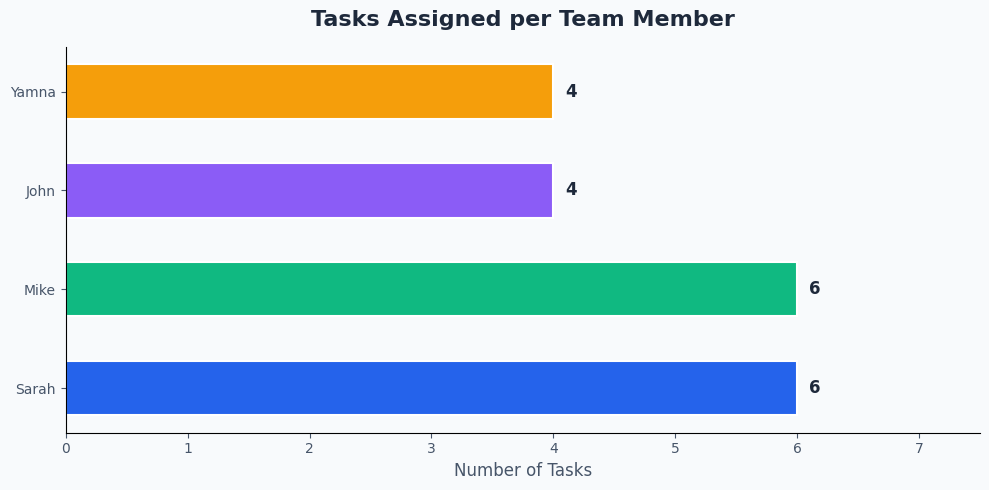

✅ Chart 1 saved: chart_tasks_per_person.png


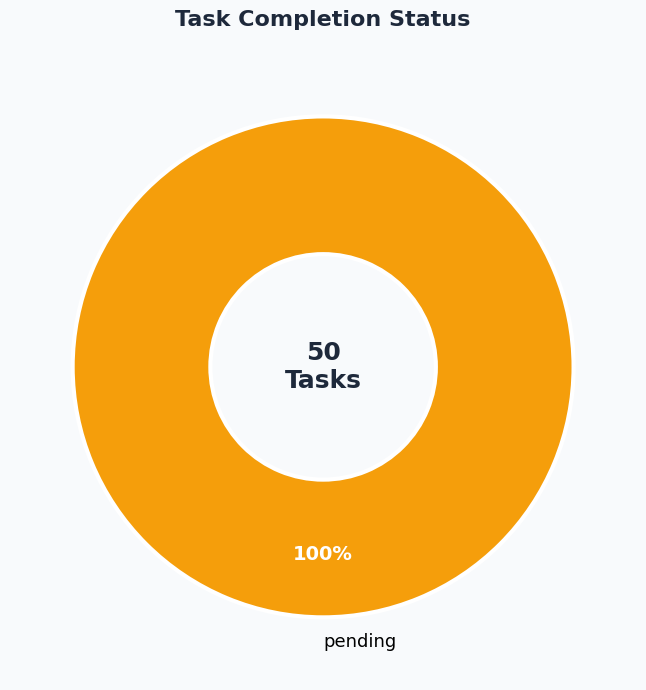

✅ Chart 2 saved: chart_task_status.png


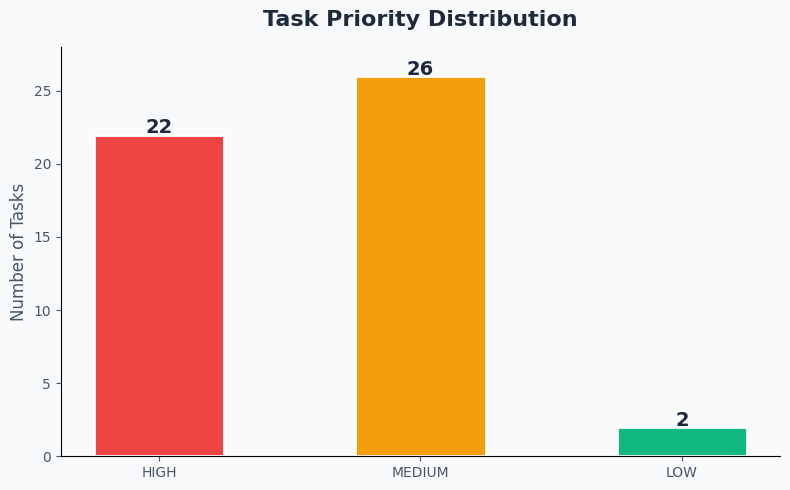

✅ Chart 3 saved: chart_priority_dist.png


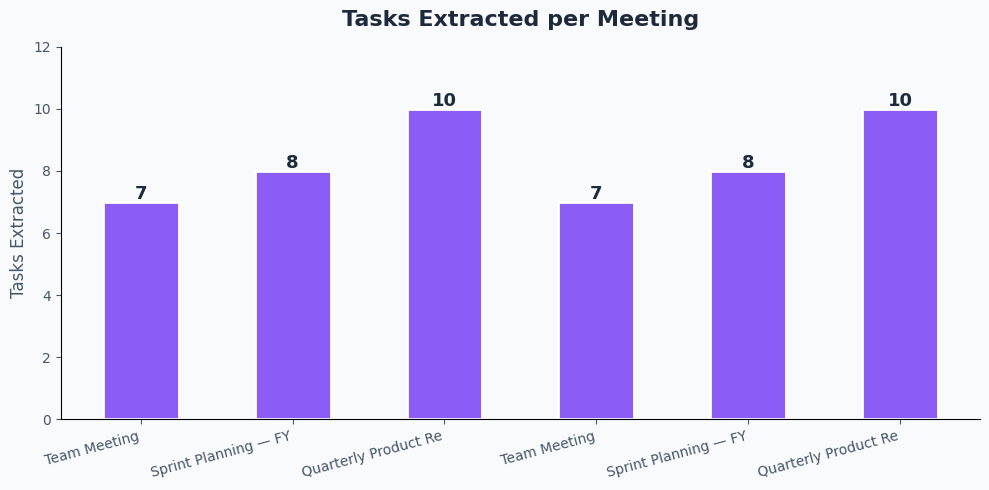

✅ Chart 4 saved: chart_tasks_per_meeting.png

🎉 All 4 analytics charts generated and saved!


In [134]:
# ============================================================
# DAY 3 — STEP 2: Analytics Charts
# Generates 4 publication-quality charts saved as PNGs
# ============================================================

import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from collections import Counter
import os

DB_PATH = '/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db'
GRAPHS_PATH = '/content/drive/Shareddrives/clario_fyp_1/clario_project/graphs'

# Fetch data
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
cursor = conn.cursor()

cursor.execute('SELECT * FROM tasks')
all_tasks = cursor.fetchall()

cursor.execute('SELECT * FROM meetings ORDER BY id')
all_meetings = cursor.fetchall()

cursor.execute('SELECT * FROM people ORDER BY total_tasks DESC')
all_people = cursor.fetchall()

conn.close()

print(f'Data loaded: {len(all_tasks)} tasks, {len(all_meetings)} meetings, {len(all_people)} people')

# ── COLOR PALETTE ────────────────────────────────────────────
CLR_MAIN   = '#2563EB'   # Blue
CLR_GREEN  = '#10B981'   # Green
CLR_YELLOW = '#F59E0B'   # Amber
CLR_RED    = '#EF4444'   # Red
CLR_PURPLE = '#8B5CF6'   # Purple
CLR_BG     = '#F8FAFC'   # Light background

plt.rcParams['font.family']  = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False


# ── CHART 1: Tasks per Person ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5), facecolor=CLR_BG)
ax.set_facecolor(CLR_BG)

people_names  = [p['name'] for p in all_people if p['name'] != 'Unknown']
people_counts = [p['total_tasks'] for p in all_people if p['name'] != 'Unknown']

if people_names:
    colors_bar = [CLR_MAIN, CLR_GREEN, CLR_PURPLE, CLR_YELLOW, CLR_RED][:len(people_names)]
    bars = ax.barh(people_names, people_counts, color=colors_bar, height=0.55, edgecolor='white', linewidth=1.5)

    for bar, count in zip(bars, people_counts):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=12, fontweight='bold', color='#1E293B')

ax.set_xlabel('Number of Tasks', fontsize=12, color='#475569')
ax.set_title('Tasks Assigned per Team Member', fontsize=16, fontweight='bold', color='#1E293B', pad=15)
ax.tick_params(colors='#475569')
ax.set_xlim(0, max(people_counts, default=1) + 1.5)
plt.tight_layout()
plt.savefig(f'{GRAPHS_PATH}/chart_tasks_per_person.png', dpi=150, bbox_inches='tight', facecolor=CLR_BG)
plt.show()
print('✅ Chart 1 saved: chart_tasks_per_person.png')


# ── CHART 2: Task Status Donut ───────────────────────────────
status_counts = Counter(t['status'] for t in all_tasks)
labels   = list(status_counts.keys())
sizes    = list(status_counts.values())
colors2  = [CLR_GREEN if l == 'completed' else CLR_YELLOW for l in labels]

fig, ax = plt.subplots(figsize=(7, 7), facecolor=CLR_BG)
ax.set_facecolor(CLR_BG)
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors2,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    pctdistance=0.75, textprops={'fontsize': 13}
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_fontweight('bold')
    at.set_color('white')

total = sum(sizes)
ax.text(0, 0, f'{total}\nTasks', ha='center', va='center',
        fontsize=18, fontweight='bold', color='#1E293B')
ax.set_title('Task Completion Status', fontsize=16, fontweight='bold', color='#1E293B', pad=20)
plt.tight_layout()
plt.savefig(f'{GRAPHS_PATH}/chart_task_status.png', dpi=150, bbox_inches='tight', facecolor=CLR_BG)
plt.show()
print('✅ Chart 2 saved: chart_task_status.png')


# ── CHART 3: Priority Distribution Bar ──────────────────────
priority_counts = Counter(t['priority'] for t in all_tasks if t['priority'])
pri_labels = ['HIGH', 'MEDIUM', 'LOW']
pri_values = [priority_counts.get(l, 0) for l in pri_labels]
pri_colors = [CLR_RED, CLR_YELLOW, CLR_GREEN]

fig, ax = plt.subplots(figsize=(8, 5), facecolor=CLR_BG)
ax.set_facecolor(CLR_BG)
bars3 = ax.bar(pri_labels, pri_values, color=pri_colors,
               width=0.5, edgecolor='white', linewidth=2)

for bar, val in zip(bars3, pri_values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha='center', fontsize=14, fontweight='bold', color='#1E293B')

ax.set_ylabel('Number of Tasks', fontsize=12, color='#475569')
ax.set_title('Task Priority Distribution', fontsize=16, fontweight='bold', color='#1E293B', pad=15)
ax.tick_params(colors='#475569')
ax.set_ylim(0, max(pri_values, default=1) + 2)
plt.tight_layout()
plt.savefig(f'{GRAPHS_PATH}/chart_priority_dist.png', dpi=150, bbox_inches='tight', facecolor=CLR_BG)
plt.show()
print('✅ Chart 3 saved: chart_priority_dist.png')


# ── CHART 4: Tasks Per Meeting ───────────────────────────────
meeting_labels = [m['meeting_title'][:20] if m['meeting_title'] else f'Meeting {m["id"]}'
                  for m in all_meetings]
meeting_task_counts = []

conn2 = sqlite3.connect(DB_PATH)
c2 = conn2.cursor()
for m in all_meetings:
    c2.execute('SELECT COUNT(*) FROM tasks WHERE meeting_id = ?', (m['id'],))
    meeting_task_counts.append(c2.fetchone()[0])
conn2.close()

fig, ax = plt.subplots(figsize=(10, 5), facecolor=CLR_BG)
ax.set_facecolor(CLR_BG)
x_pos = range(len(meeting_labels))
bars4 = ax.bar(x_pos, meeting_task_counts, color=CLR_PURPLE,
               width=0.5, edgecolor='white', linewidth=2)

for bar, val in zip(bars4, meeting_task_counts):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha='center', fontsize=13, fontweight='bold', color='#1E293B')

ax.set_xticks(x_pos)
ax.set_xticklabels(meeting_labels, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Tasks Extracted', fontsize=12, color='#475569')
ax.set_title('Tasks Extracted per Meeting', fontsize=16, fontweight='bold', color='#1E293B', pad=15)
ax.tick_params(colors='#475569')
ax.set_ylim(0, max(meeting_task_counts, default=1) + 2)
plt.tight_layout()
plt.savefig(f'{GRAPHS_PATH}/chart_tasks_per_meeting.png', dpi=150, bbox_inches='tight', facecolor=CLR_BG)
plt.show()
print('✅ Chart 4 saved: chart_tasks_per_meeting.png')

print('\n🎉 All 4 analytics charts generated and saved!')

In [135]:
# ============================================================
# DAY 4 — STEP 1: Deadline Parser + Urgency Calculator
# Converts natural language dates like 'Friday', 'tomorrow'
# into number of days remaining
# ============================================================

from datetime import datetime, timedelta
import re

TODAY = datetime.now()

def parse_deadline_to_days(due_date_str):
    """
    Converts a natural-language due date string into days remaining.
    Returns: int (days remaining) or None if unparseable
    """
    if not due_date_str or due_date_str.strip() in ['Not specified', '', 'N/A']:
        return None

    text = due_date_str.lower().strip()

    # Direct matches
    if 'today' in text or 'tonight' in text:
        return 0
    if 'tomorrow' in text:
        return 1
    if 'day after tomorrow' in text:
        return 2
    if 'this week' in text or 'end of week' in text:
        # Days until Friday
        days_to_friday = (4 - TODAY.weekday()) % 7
        return max(days_to_friday, 1)
    if 'next week' in text:
        return 7
    if 'next month' in text:
        return 30

    # Weekday names
    weekdays = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
    for i, day in enumerate(weekdays):
        if day in text:
            days_ahead = (i - TODAY.weekday()) % 7
            if days_ahead == 0:
                days_ahead = 7  # next occurrence
            return days_ahead

    # 'in N days'
    m = re.search(r'in (\d+) days?', text)
    if m:
        return int(m.group(1))

    return None


def get_urgency_label(days):
    """
    Returns urgency label and emoji for display
    """
    if days is None:
        return ('⚪ No deadline set', 'none')
    if days < 0:
        return (f'🚨 OVERDUE by {abs(days)} day(s)', 'overdue')
    if days == 0:
        return ('🔴 DUE TODAY', 'today')
    if days == 1:
        return ('🔴 Due TOMORROW', 'tomorrow')
    if days <= 3:
        return (f'🟠 Due in {days} days', 'urgent')
    if days <= 7:
        return (f'🟡 Due in {days} days', 'this_week')
    return (f'🟢 Due in {days} days', 'future')


# Test
test_dates = ['today', 'tomorrow', 'Friday', 'end of this week',
              'next Monday', 'next week', 'Not specified', 'Wednesday']

print('=' * 50)
print('⏰ DEADLINE PARSER TEST')
print('=' * 50)
for d in test_dates:
    days = parse_deadline_to_days(d)
    label, _ = get_urgency_label(days)
    print(f'  "{d:25}" → {days} days → {label}')

print('\n✅ Deadline parser working!')

⏰ DEADLINE PARSER TEST
  "today                    " → 0 days → 🔴 DUE TODAY
  "tomorrow                 " → 1 days → 🔴 Due TOMORROW
  "Friday                   " → 2 days → 🟠 Due in 2 days
  "end of this week         " → 2 days → 🟠 Due in 2 days
  "next Monday              " → 5 days → 🟡 Due in 5 days
  "next week                " → 7 days → 🟡 Due in 7 days
  "Not specified            " → None days → ⚪ No deadline set
  "Wednesday                " → 7 days → 🟡 Due in 7 days

✅ Deadline parser working!


In [136]:
# ============================================================
# DAY 4 — STEP 2: Generate Full Reminder Report
# Scans ALL pending tasks, computes urgency, saves report
# ============================================================

import sqlite3
import json
from datetime import datetime

DB_PATH = '/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db'
BASE_PATH = '/content/drive/Shareddrives/clario_fyp_1/clario_project'

conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
cursor = conn.cursor()
cursor.execute("SELECT * FROM tasks WHERE status = 'pending' ORDER BY id")
pending_tasks = cursor.fetchall()
conn.close()

print('=' * 60)
print('⏰ CLARIO REMINDER REPORT')
print(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}'
      f'  |  Pending Tasks: {len(pending_tasks)}')
print('=' * 60)

reminder_data = []
overdue    = []
due_today  = []
due_soon   = []
due_later  = []

for task in pending_tasks:
    days  = parse_deadline_to_days(task['due_date'])
    label, urgency_type = get_urgency_label(days)

    entry = {
        'task_id'     : task['id'],
        'description' : task['description'],
        'assigned_to' : task['assigned_to'],
        'due_date'    : task['due_date'],
        'priority'    : task['priority'] if task['priority'] else 'MEDIUM',
        'days_remaining': days,
        'urgency_label': label,
        'urgency_type' : urgency_type
    }
    reminder_data.append(entry)

    if urgency_type == 'overdue':    overdue.append(entry)
    elif urgency_type == 'today':    due_today.append(entry)
    elif urgency_type in ('tomorrow', 'urgent'): due_soon.append(entry)
    else:                            due_later.append(entry)


def print_section(title, items):
    if not items:
        return
    print(f'\n{title} ({len(items)} task(s))')
    print('-' * 55)
    for t in items:
        print(f"  Task #{t['task_id']} | {t['urgency_label']}")
        print(f"  📝 {t['description'][:60]}")
        print(f"  👤 {t['assigned_to']}  |  Priority: {t['priority']}")
        print()

print_section('🚨 OVERDUE', overdue)
print_section('🔴 DUE TODAY', due_today)
print_section('🟠 DUE SOON (1–3 days)', due_soon)
print_section('🟢 UPCOMING', due_later)

# Save reminder report
report = {
    'generated_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_pending': len(pending_tasks),
    'overdue_count': len(overdue),
    'due_today_count': len(due_today),
    'due_soon_count': len(due_soon),
    'reminders': reminder_data
}

with open(f'{BASE_PATH}/evaluation/reminder_report.json', 'w') as f:
    json.dump(report, f, indent=4)

print('=' * 60)
print(f'✅ Reminder report saved to evaluation/reminder_report.json')
print(f'📊 Summary: {len(overdue)} overdue | {len(due_today)} today | {len(due_soon)} soon')

⏰ CLARIO REMINDER REPORT
Generated: 2026-04-29 08:57  |  Pending Tasks: 50

🔴 DUE TODAY (4 task(s))
-------------------------------------------------------
  Task #9 | 🔴 DUE TODAY
  📝 Hurair must fix the authentication bug in the API before ton
  👤 Unknown  |  Priority: HIGH

  Task #12 | 🔴 DUE TODAY
  📝 Everyone must update their progress on the shared document b
  👤 Unknown  |  Priority: HIGH

  Task #34 | 🔴 DUE TODAY
  📝 Hurair must fix the authentication bug in the API before ton
  👤 Unknown  |  Priority: HIGH

  Task #37 | 🔴 DUE TODAY
  📝 Everyone must update their progress on the shared document b
  👤 Unknown  |  Priority: HIGH


🟠 DUE SOON (1–3 days) (20 task(s))
-------------------------------------------------------
  Task #1 | 🟠 Due in 2 days
  📝 First, John will complete the database setup by Friday.
  👤 John  |  Priority: MEDIUM

  Task #2 | 🔴 Due TOMORROW
  📝 Sarah needs to review the design mock-ups and send feedback 
  👤 Sarah  |  Priority: HIGH

  Task #4 | 🟠 Due in 2 d

In [137]:
# ============================================================
# DAY 5 — Write the Complete Redesigned Dashboard
# REPLACES clario_app.py with the stunning new version
# ============================================================

import os

dashboard_code = r'''
# ============================================================
#  CLARIO — Smart Meeting Assistant Dashboard  v2.0
#  FYP Group 6 | COMSATS University Lahore
#  Built with: Streamlit · Whisper · BART · spaCy · NetworkX
# ============================================================

import streamlit as st
import sqlite3
import json
import os
import re
import tempfile
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, timedelta
from collections import Counter
from wordcloud import WordCloud

# ─────────────────────────────────────────────────────────────
#  PAGE CONFIG
# ─────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Clario — Smart Meeting Assistant",
    page_icon="🧠",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ─────────────────────────────────────────────────────────────
#  GLOBAL CSS — Dark Professional Theme
# ─────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&family=Space+Mono:wght@400;700&display=swap');

/* ── Root variables ── */
:root {
  --bg-primary:   #0F172A;
  --bg-card:      #1E293B;
  --bg-card2:     #263548;
  --accent-blue:  #3B82F6;
  --accent-cyan:  #06B6D4;
  --accent-green: #10B981;
  --accent-amber: #F59E0B;
  --accent-red:   #EF4444;
  --accent-purple:#8B5CF6;
  --text-primary: #F1F5F9;
  --text-muted:   #94A3B8;
  --border:       #334155;
}

/* ── Base ── */
html, body, [class*="css"] { font-family: 'Inter', sans-serif; }
.main, .block-container {
  background: var(--bg-primary) !important;
  color: var(--text-primary) !important;
  padding-top: 1.5rem !important;
}

/* ── Sidebar ── */
[data-testid="stSidebar"] {
  background: linear-gradient(180deg, #0D1B2A 0%, #1E293B 100%) !important;
  border-right: 1px solid var(--border);
}
[data-testid="stSidebar"] .stRadio label { color: var(--text-primary) !important; font-size: 0.95rem; }
[data-testid="stSidebar"] h1, [data-testid="stSidebar"] h2,
[data-testid="stSidebar"] h3 { color: var(--text-primary) !important; }

/* ── Metric cards ── */
[data-testid="metric-container"] {
  background: var(--bg-card);
  border: 1px solid var(--border);
  border-radius: 14px;
  padding: 1.2rem 1.4rem;
  transition: transform 0.2s;
}
[data-testid="metric-container"]:hover { transform: translateY(-2px); }
[data-testid="metric-container"] label { color: var(--text-muted) !important; font-size: 0.82rem; font-weight: 600; letter-spacing: 0.06em; text-transform: uppercase; }
[data-testid="metric-container"] [data-testid="stMetricValue"] { color: var(--text-primary) !important; font-size: 2rem; font-weight: 800; }

/* ── Headings ── */
h1, h2, h3 { color: var(--text-primary) !important; font-weight: 700; }
h1 { font-size: 2rem; letter-spacing: -0.03em; }
h3 { font-size: 1.2rem; color: var(--text-muted) !important; font-weight: 500; }

/* ── Buttons ── */
.stButton > button {
  background: linear-gradient(135deg, var(--accent-blue), var(--accent-cyan)) !important;
  color: white !important;
  border: none !important;
  border-radius: 10px !important;
  padding: 0.55rem 1.4rem !important;
  font-weight: 600 !important;
  font-size: 0.92rem !important;
  transition: all 0.2s !important;
  box-shadow: 0 4px 15px rgba(59,130,246,0.35) !important;
}
.stButton > button:hover {
  transform: translateY(-1px) !important;
  box-shadow: 0 6px 20px rgba(59,130,246,0.5) !important;
}

/* ── Inputs ── */
.stSelectbox > div > div,
.stTextInput > div > div > input,
.stTextArea textarea {
  background: var(--bg-card) !important;
  border: 1px solid var(--border) !important;
  border-radius: 10px !important;
  color: var(--text-primary) !important;
}
.stFileUploader > div {
  background: var(--bg-card);
  border: 2px dashed var(--accent-blue);
  border-radius: 14px;
}

/* ── Expanders ── */
.streamlit-expanderHeader {
  background: var(--bg-card) !important;
  border-radius: 10px !important;
  color: var(--text-primary) !important;
  font-weight: 600 !important;
}
.streamlit-expanderContent {
  background: var(--bg-card2) !important;
  border-radius: 0 0 10px 10px !important;
}

/* ── Tabs ── */
.stTabs [data-baseweb="tab"] { color: var(--text-muted) !important; font-weight: 500; }
.stTabs [aria-selected="true"] { color: var(--accent-cyan) !important; border-bottom-color: var(--accent-cyan) !important; }

/* ── Divider ── */
hr { border-color: var(--border) !important; }

/* ── Info / Success / Warning / Error boxes ── */
.stAlert { border-radius: 12px !important; }

/* ── Custom card component ── */
.clario-card {
  background: var(--bg-card);
  border: 1px solid var(--border);
  border-radius: 14px;
  padding: 1.25rem 1.5rem;
  margin-bottom: 1rem;
  transition: border-color 0.2s;
}
.clario-card:hover { border-color: var(--accent-blue); }

.priority-HIGH   { background: rgba(239,68,68,0.15);  color: #FCA5A5; border: 1px solid rgba(239,68,68,0.4);  border-radius: 6px; padding: 2px 10px; font-size: 0.78rem; font-weight: 700; letter-spacing: 0.05em; }
.priority-MEDIUM { background: rgba(245,158,11,0.15); color: #FCD34D; border: 1px solid rgba(245,158,11,0.4); border-radius: 6px; padding: 2px 10px; font-size: 0.78rem; font-weight: 700; letter-spacing: 0.05em; }
.priority-LOW    { background: rgba(16,185,129,0.15); color: #6EE7B7; border: 1px solid rgba(16,185,129,0.4); border-radius: 6px; padding: 2px 10px; font-size: 0.78rem; font-weight: 700; letter-spacing: 0.05em; }

.status-badge-pending   { background: rgba(245,158,11,0.15); color: #FCD34D; border-radius: 6px; padding: 2px 10px; font-size: 0.78rem; font-weight: 600; }
.status-badge-completed { background: rgba(16,185,129,0.15); color: #6EE7B7; border-radius: 6px; padding: 2px 10px; font-size: 0.78rem; font-weight: 600; }

.urgency-overdue  { color: #FCA5A5; font-weight: 700; }
.urgency-today    { color: #F87171; font-weight: 700; }
.urgency-tomorrow { color: #FB923C; font-weight: 700; }
.urgency-urgent   { color: #FBBF24; font-weight: 600; }
.urgency-future   { color: #6EE7B7; font-weight: 500; }

.page-header {
  background: linear-gradient(135deg, #1E293B 0%, #0F172A 100%);
  border: 1px solid var(--border);
  border-radius: 18px;
  padding: 1.8rem 2.2rem;
  margin-bottom: 2rem;
}
.gradient-text {
  background: linear-gradient(135deg, #60A5FA, #34D399);
  -webkit-background-clip: text;
  -webkit-text-fill-color: transparent;
  background-clip: text;
}
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────────────────────
#  CONSTANTS
# ─────────────────────────────────────────────────────────────
DB_PATH    = "/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db"
BASE_PATH  = "/content/drive/Shareddrives/clario_fyp_1/clario_project"
TODAY      = datetime.now()


# ─────────────────────────────────────────────────────────────
#  DATABASE HELPERS
# ─────────────────────────────────────────────────────────────
def get_db():
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    return conn

def get_meetings():
    try:
        conn = get_db(); r = conn.execute("SELECT * FROM meetings ORDER BY created_at DESC").fetchall(); conn.close(); return r
    except: return []

def get_tasks(meeting_id=None):
    try:
        conn = get_db()
        if meeting_id: r = conn.execute("SELECT * FROM tasks WHERE meeting_id=? ORDER BY id", (meeting_id,)).fetchall()
        else:          r = conn.execute("SELECT * FROM tasks ORDER BY id").fetchall()
        conn.close(); return r
    except: return []

def get_people():
    try:
        conn = get_db(); r = conn.execute("SELECT * FROM people ORDER BY total_tasks DESC").fetchall(); conn.close(); return r
    except: return []

def update_task_status(task_id, status):
    conn = get_db(); conn.execute("UPDATE tasks SET status=? WHERE id=?", (status, task_id)); conn.commit(); conn.close()


# ─────────────────────────────────────────────────────────────
#  UTILITY FUNCTIONS
# ─────────────────────────────────────────────────────────────
def priority_badge(p):
    icons = {'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}
    cls   = {'HIGH': 'priority-HIGH', 'MEDIUM': 'priority-MEDIUM', 'LOW': 'priority-LOW'}
    p = p or 'MEDIUM'
    return f'<span class="{cls.get(p, "priority-MEDIUM")}">{icons.get(p,"🟡")} {p}</span>'

def status_badge(s):
    s = s or 'pending'
    icon = '✅' if s == 'completed' else '⏳'
    cls  = 'status-badge-completed' if s == 'completed' else 'status-badge-pending'
    return f'<span class="{cls}">{icon} {s.capitalize()}</span>'

def deadline_display(due_date_str):
    if not due_date_str or due_date_str in ['Not specified', '', 'N/A']:
        return '<span style="color:#64748B">No deadline</span>'
    text = due_date_str.lower().strip()
    days = None
    if 'today' in text or 'tonight' in text: days = 0
    elif 'tomorrow' in text: days = 1
    elif 'this week' in text or 'end of week' in text:
        days = max((4 - TODAY.weekday()) % 7, 1)
    elif 'next week' in text: days = 7
    else:
        weekdays = ['monday','tuesday','wednesday','thursday','friday','saturday','sunday']
        for i,d in enumerate(weekdays):
            if d in text:
                diff = (i - TODAY.weekday()) % 7
                days = diff if diff > 0 else 7
                break
    if days is None:
        return f'<span style="color:#94A3B8">📅 {due_date_str}</span>'
    if days < 0:  return f'<span class="urgency-overdue">🚨 OVERDUE</span>'
    if days == 0: return f'<span class="urgency-today">🔴 Due TODAY</span>'
    if days == 1: return f'<span class="urgency-tomorrow">🟠 Due TOMORROW</span>'
    if days <= 3: return f'<span class="urgency-urgent">🟡 In {days} days</span>'
    return f'<span class="urgency-future">🟢 In {days} days</span>'


# ─────────────────────────────────────────────────────────────
#  SIDEBAR
# ─────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div style='text-align:center; padding: 1rem 0 0.5rem;'>
      <div style='font-size:3rem;'>🧠</div>
      <div style='font-family:Inter; font-size:1.6rem; font-weight:800;
           background:linear-gradient(135deg,#60A5FA,#34D399);
           -webkit-background-clip:text; -webkit-text-fill-color:transparent;'>Clario</div>
      <div style='color:#64748B; font-size:0.78rem; letter-spacing:0.1em; font-weight:500;'>SMART MEETING ASSISTANT</div>
    </div>
    <hr style='border-color:#334155; margin:1rem 0;'/>
    """, unsafe_allow_html=True)

    page = st.radio(
        "Navigation",
        [
            "🏠  Dashboard",
            "➕  New Meeting",
            "📄  Meeting History",
            "✅  Task Manager",
            "⏰  Reminders",
            "👥  Team Overview",
            "📊  Analytics",
            "🔬  AI Evaluation",
            "🕸️  Knowledge Graph"
        ],
        label_visibility="collapsed"
    )

    st.markdown("<hr style='border-color:#334155;'/>", unsafe_allow_html=True)

    meetings = get_meetings()
    tasks    = get_tasks()
    pending  = [t for t in tasks if t['status'] == 'pending']

    st.markdown(f"""
    <div style='padding:0.8rem; background:#1E293B; border-radius:10px; border:1px solid #334155;'>
      <div style='color:#94A3B8; font-size:0.75rem; font-weight:600; text-transform:uppercase; letter-spacing:0.08em; margin-bottom:0.6rem;'>System Status</div>
      <div style='display:flex; justify-content:space-between; margin-bottom:0.3rem;'>
        <span style='color:#94A3B8; font-size:0.85rem;'>Meetings</span>
        <span style='color:#60A5FA; font-weight:700;'>{len(meetings)}</span>
      </div>
      <div style='display:flex; justify-content:space-between; margin-bottom:0.3rem;'>
        <span style='color:#94A3B8; font-size:0.85rem;'>Total Tasks</span>
        <span style='color:#34D399; font-weight:700;'>{len(tasks)}</span>
      </div>
      <div style='display:flex; justify-content:space-between;'>
        <span style='color:#94A3B8; font-size:0.85rem;'>Pending</span>
        <span style='color:#FBBF24; font-weight:700;'>{len(pending)}</span>
      </div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("<div style='height:0.5rem'/>", unsafe_allow_html=True)
    st.caption("Whisper · BART · spaCy · NetworkX")
    st.caption("FYP Group 6 · COMSATS Lahore")


# ═════════════════════════════════════════════════════════════
# PAGE: DASHBOARD
# ═════════════════════════════════════════════════════════════
if page == "🏠  Dashboard":

    st.markdown("""
    <div class='page-header'>
      <div style='font-size:0.8rem; color:#64748B; text-transform:uppercase; letter-spacing:0.1em; font-weight:600; margin-bottom:0.4rem;'>AI-Powered Meeting Intelligence</div>
      <div style='font-size:2.2rem; font-weight:800; background:linear-gradient(135deg,#60A5FA,#34D399); -webkit-background-clip:text; -webkit-text-fill-color:transparent;'>Welcome to Clario</div>
      <div style='color:#94A3B8; font-size:1rem; margin-top:0.3rem;'>Transcribe · Summarize · Extract · Track</div>
    </div>
    """, unsafe_allow_html=True)

    meetings = get_meetings()
    tasks    = get_tasks()
    people   = get_people()
    pending  = [t for t in tasks if t['status'] == 'pending']
    done     = [t for t in tasks if t['status'] == 'completed']
    high_pri = [t for t in tasks if (t['priority'] or 'MEDIUM') == 'HIGH']

    c1, c2, c3, c4, c5 = st.columns(5)
    c1.metric("📅 Meetings",     len(meetings))
    c2.metric("📋 Total Tasks",  len(tasks))
    c3.metric("⏳ Pending",      len(pending))
    c4.metric("✅ Completed",    len(done))
    c5.metric("🔴 High Priority",len(high_pri))

    st.markdown("<div style='height:1.5rem'/>", unsafe_allow_html=True)
    col_left, col_right = st.columns([3, 2])

    with col_left:
        if meetings:
            latest = meetings[0]
            st.markdown("<div style='font-size:0.78rem; color:#64748B; font-weight:600; text-transform:uppercase; letter-spacing:0.08em; margin-bottom:0.6rem;'>Latest Meeting</div>", unsafe_allow_html=True)
            title = latest['meeting_title'] if latest['meeting_title'] else 'Team Meeting'
            st.markdown(f"""
            <div class='clario-card'>
              <div style='font-size:1.15rem; font-weight:700; color:#F1F5F9; margin-bottom:0.3rem;'>📅 {title}</div>
              <div style='color:#64748B; font-size:0.82rem; margin-bottom:0.8rem;'>{latest['meeting_date']} &nbsp;·&nbsp; ID #{latest['id']}</div>
              <div style='color:#CBD5E1; font-size:0.9rem; line-height:1.55;'>{(latest['summary'] or 'No summary')[:300]}{'...' if len(latest['summary'] or '') > 300 else ''}</div>
            </div>
            """, unsafe_allow_html=True)

            st.markdown("<div style='font-size:0.78rem; color:#64748B; font-weight:600; text-transform:uppercase; letter-spacing:0.08em; margin: 1rem 0 0.6rem;'>Latest Action Items</div>", unsafe_allow_html=True)
            latest_tasks = get_tasks(latest['id'])
            for t in latest_tasks[:5]:
                p = t['priority'] or 'MEDIUM'
                st.markdown(f"""
                <div class='clario-card' style='padding:0.8rem 1.1rem; margin-bottom:0.5rem;'>
                  <div style='display:flex; justify-content:space-between; align-items:center;'>
                    <div style='flex:1;'>
                      <div style='color:#E2E8F0; font-size:0.9rem; margin-bottom:0.3rem;'>{t['description'][:70]}{'...' if len(t['description'])>70 else ''}</div>
                      <div style='color:#64748B; font-size:0.8rem;'>👤 {t['assigned_to']} &nbsp;·&nbsp; {deadline_display(t['due_date'])}</div>
                    </div>
                    <div style='margin-left:1rem;'>{priority_badge(p)}</div>
                  </div>
                </div>
                """, unsafe_allow_html=True)
        else:
            st.info("No meetings yet. Go to **➕ New Meeting** to process your first meeting!")

    with col_right:
        st.markdown("<div style='font-size:0.78rem; color:#64748B; font-weight:600; text-transform:uppercase; letter-spacing:0.08em; margin-bottom:0.6rem;'>Task Completion</div>", unsafe_allow_html=True)
        if tasks:
            pct = int(len(done) / len(tasks) * 100)
            st.markdown(f"""
            <div class='clario-card' style='text-align:center;'>
              <div style='font-size:3rem; font-weight:800; background:linear-gradient(135deg,#60A5FA,#34D399); -webkit-background-clip:text; -webkit-text-fill-color:transparent;'>{pct}%</div>
              <div style='color:#94A3B8; font-size:0.88rem; margin-top:0.2rem;'>completion rate</div>
              <div style='background:#334155; border-radius:999px; height:8px; margin:0.8rem 0;'>
                <div style='background:linear-gradient(90deg,#3B82F6,#10B981); width:{pct}%; height:100%; border-radius:999px;'></div>
              </div>
              <div style='color:#64748B; font-size:0.82rem;'>{len(done)} done · {len(pending)} pending</div>
            </div>
            """, unsafe_allow_html=True)

        if latest['transcript'] if meetings else None:
            st.markdown("<div style='font-size:0.78rem; color:#64748B; font-weight:600; text-transform:uppercase; letter-spacing:0.08em; margin: 1rem 0 0.6rem;'>Word Cloud</div>", unsafe_allow_html=True)
            try:
                wc = WordCloud(width=600, height=250, background_color='#1E293B',
                               colormap='Blues', max_words=60).generate(meetings[0]['transcript'])
                fig, ax = plt.subplots(figsize=(6, 2.5))
                fig.patch.set_facecolor('#1E293B')
                ax.imshow(wc, interpolation='bilinear')
                ax.axis('off')
                plt.tight_layout(pad=0)
                st.pyplot(fig)
                plt.close()
            except Exception as e:
                st.caption(f"Word cloud: {e}")


# ═════════════════════════════════════════════════════════════
# PAGE: NEW MEETING (LIVE UPLOAD)
# ═════════════════════════════════════════════════════════════
elif page == "➕  New Meeting":

    st.markdown("<h1 class='gradient-text'>➕ Process New Meeting</h1>", unsafe_allow_html=True)
    st.markdown("<p style='color:#94A3B8;'>Upload an audio file or paste transcript text — Clario runs the full AI pipeline automatically.</p>", unsafe_allow_html=True)
    st.markdown("---")

    meeting_title = st.text_input("📝 Meeting Title", placeholder="e.g. Sprint Planning · Product Review · Weekly Sync")

    input_mode = st.radio("Input Mode", ["📄 Paste Text Transcript", "🎤 Upload Audio File (.mp3 / .wav)"], horizontal=True)

    user_text  = None
    audio_path = None

    if input_mode == "📄 Paste Text Transcript":
        user_text = st.text_area(
            "Paste your meeting transcript here",
            height=220,
            placeholder="Good morning team. Let's start today's meeting...\nJohn will complete the database setup by Friday...\n"
        )
    else:
        uploaded_audio = st.file_uploader("Upload meeting audio", type=["mp3", "wav", "m4a"])
        if uploaded_audio:
            tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.mp3')
            tmp.write(uploaded_audio.read())
            tmp.close()
            audio_path = tmp.name
            st.success(f"✅ Audio uploaded: {uploaded_audio.name}")

    if st.button("🚀 Process Meeting", use_container_width=True):
        if not meeting_title.strip():
            st.error("Please enter a meeting title.")
        elif input_mode == "📄 Paste Text Transcript" and not (user_text and user_text.strip()):
            st.error("Please paste some transcript text.")
        elif input_mode == "🎤 Upload Audio File (.mp3 / .wav)" and not audio_path:
            st.error("Please upload an audio file.")
        else:
            import subprocess, sys
            with st.spinner("⚙️ Running AI pipeline — this may take 1–2 minutes..."):
                try:
                    # Import the pipeline functions (defined in Colab notebook)
                    import importlib.util, types

                    # We call the pipeline via a subprocess-safe helper
                    # that writes results to a JSON file and we read it back
                    import whisper as _whisper
                    import spacy as _spacy
                    import re as _re
                    import sqlite3 as _sqlite3
                    import json as _json
                    from transformers import pipeline as _hf_pipeline
                    from datetime import datetime as _dt

                    # ── Load models ──
                    _nlp = _spacy.load('en_core_web_sm')
                    _summarizer = _hf_pipeline('summarization', model='facebook/bart-large-cnn', device=-1)

                    # ── Get transcript ──
                    if audio_path:
                        st.info("🎤 Transcribing audio with Whisper...")
                        _wm = _whisper.load_model('base')
                        transcript = _wm.transcribe(audio_path)['text'].strip()
                    else:
                        transcript = user_text.strip()

                    # ── Summarize ──
                    st.info("📋 Generating summary with BART...")
                    sum_res  = _summarizer(transcript[:1024], max_length=160, min_length=50, do_sample=False)
                    summary  = sum_res[0]['summary_text']

                    # ── Task extraction (inline) ──
                    st.info("🔍 Extracting tasks with spaCy + Priority scorer...")
                    task_kws = [r'\bwill\b', r'\bneeds? to\b', r'\bmust\b', r'\bshould\b',
                                r'\bhas to\b', r'\bplease\b', r'\bsubmit\b', r'\bcomplete\b',
                                r'\bfinish\b', r'\bsend\b', r'\breview\b', r'\bschedule\b',
                                r'\bfix\b', r'\bhandle\b', r'\bprepare\b', r'\bdeliver\b']

                    HIGH_KW = [r'\burgent\b', r'\basap\b', r'\bcritical\b', r'\btoday\b',
                               r'\btomorrow\b', r'\bmust\b', r'\bdeadline\b', r'\bblocking\b']
                    MED_KW  = [r'\bthis week\b', r'\bby friday\b', r'\bsoon\b', r'\bneeds? to\b',
                               r'\bshould\b', r'\bwill\b', r'\bhas to\b']

                    def _priority(txt):
                        t = txt.lower()
                        for p in HIGH_KW:
                            if _re.search(p, t): return 'HIGH'
                        for p in MED_KW:
                            if _re.search(p, t): return 'MEDIUM'
                        return 'LOW'

                    new_tasks = []
                    doc = _nlp(transcript)
                    for sent in doc.sents:
                        s = sent.text.strip()
                        sl = s.lower()
                        found_kw = ''
                        for kw in task_kws:
                            if _re.search(kw, sl):
                                found_kw = kw.replace(r'\b', '').replace('?','')
                                break
                        if not found_kw: continue

                        sd = _nlp(s)
                        person = next((e.text for e in sd.ents if e.label_ == 'PERSON'), 'Unknown')
                        date   = next((e.text for e in sd.ents if e.label_ in ['DATE','TIME']), 'Not specified')
                        new_tasks.append({
                            'description': s, 'assigned_to': person,
                            'due_date': date, 'keyword': found_kw,
                            'priority': _priority(f'{s} {date}')
                        })

                    # ── Save to DB ──
                    conn = _sqlite3.connect(DB_PATH)
                    cur  = conn.cursor()
                    cur.execute(
                        'INSERT INTO meetings (meeting_date, transcript, summary, audio_file, created_at, meeting_title, total_tasks) VALUES (?,?,?,?,?,?,?)',
                        (_dt.now().strftime('%Y-%m-%d'), transcript, summary,
                         'upload', _dt.now().strftime('%Y-%m-%d %H:%M:%S'),
                         meeting_title, len(new_tasks))
                    )
                    mid = cur.lastrowid
                    for t in new_tasks:
                        cur.execute(
                            'INSERT INTO tasks (meeting_id, description, assigned_to, due_date, keyword, created_at, priority, speaker) VALUES (?,?,?,?,?,?,?,?)',
                            (mid, t['description'], t['assigned_to'], t['due_date'],
                             t['keyword'], _dt.now().strftime('%Y-%m-%d %H:%M:%S'), t['priority'], t['assigned_to'])
                        )
                        if t['assigned_to'] != 'Unknown':
                            cur.execute('INSERT OR IGNORE INTO people (name, total_tasks) VALUES (?,0)', (t['assigned_to'],))
                            cur.execute('UPDATE people SET total_tasks=total_tasks+1 WHERE name=?', (t['assigned_to'],))
                    conn.commit(); conn.close()

                    st.success(f"✅ Meeting processed! Found **{len(new_tasks)}** tasks. Meeting ID: **#{mid}**")
                    st.markdown("**📋 Summary:**")
                    st.info(summary)

                    st.markdown(f"**🎯 Detected Tasks ({len(new_tasks)}):**")
                    p_icons = {'HIGH':'🔴','MEDIUM':'🟡','LOW':'🟢'}
                    for tk in new_tasks:
                        st.markdown(f"  {p_icons.get(tk['priority'],'🟡')} **{tk['assigned_to']}** — {tk['description'][:80]}  *(Due: {tk['due_date']})*")

                    st.balloons()

                except Exception as ex:
                    st.error(f"Pipeline error: {ex}")
                    import traceback; st.code(traceback.format_exc())


# ═════════════════════════════════════════════════════════════
# PAGE: MEETING HISTORY
# ═════════════════════════════════════════════════════════════
elif page == "📄  Meeting History":
    st.markdown("<h1 class='gradient-text'>📄 Meeting History</h1>", unsafe_allow_html=True)
    st.markdown("---")
    meetings = get_meetings()
    if not meetings:
        st.warning("No meetings found. Process your first meeting using **➕ New Meeting**.")
    else:
        for m in meetings:
            title = m['meeting_title'] or 'Team Meeting'
            tc = m['total_tasks'] or 0
            with st.expander(f"📅 {title}  ·  {m['meeting_date']}  ·  {tc} tasks  (ID #{m['id']})"):
                t1, t2, t3 = st.tabs(["📝 Transcript", "📋 AI Summary", "✅ Tasks"])
                with t1:
                    st.text_area("", m['transcript'] or 'No transcript', height=200, key=f"tr_{m['id']}")
                with t2:
                    st.markdown(f"<div class='clario-card'><p style='color:#CBD5E1; line-height:1.7;'>{m['summary'] or 'No summary'}</p></div>", unsafe_allow_html=True)
                with t3:
                    mtasks = get_tasks(m['id'])
                    if mtasks:
                        for tk in mtasks:
                            p = tk['priority'] or 'MEDIUM'
                            st.markdown(f"""
                            <div class='clario-card' style='padding:0.7rem 1rem; margin-bottom:0.4rem;'>
                              <div style='display:flex; justify-content:space-between; align-items:flex-start;'>
                                <div>
                                  <div style='color:#E2E8F0; font-size:0.88rem; margin-bottom:0.25rem;'>{tk['description'][:90]}</div>
                                  <div style='color:#64748B; font-size:0.78rem;'>👤 {tk['assigned_to']} &nbsp;·&nbsp; {deadline_display(tk['due_date'])} &nbsp;·&nbsp; {status_badge(tk['status'])}</div>
                                </div>
                                <div style='margin-left:0.8rem;'>{priority_badge(p)}</div>
                              </div>
                            </div>
                            """, unsafe_allow_html=True)
                    else:
                        st.info("No tasks for this meeting.")


# ═════════════════════════════════════════════════════════════
# PAGE: TASK MANAGER
# ═════════════════════════════════════════════════════════════
elif page == "✅  Task Manager":
    st.markdown("<h1 class='gradient-text'>✅ Task Manager</h1>", unsafe_allow_html=True)
    st.markdown("---")
    tasks = get_tasks()
    if not tasks:
        st.warning("No tasks yet. Process a meeting first.")
    else:
        col_f1, col_f2, col_f3 = st.columns(3)
        with col_f1:
            status_f = st.selectbox("Status", ["All", "Pending", "Completed"])
        with col_f2:
            priority_f = st.selectbox("Priority", ["All", "HIGH", "MEDIUM", "LOW"])
        with col_f3:
            person_options = ["All"] + list(set(t['assigned_to'] for t in tasks if t['assigned_to'] != 'Unknown'))
            person_f = st.selectbox("Assigned To", person_options)

        filtered = tasks
        if status_f   != "All":     filtered = [t for t in filtered if t['status'].lower() == status_f.lower()]
        if priority_f != "All":     filtered = [t for t in filtered if (t['priority'] or 'MEDIUM') == priority_f]
        if person_f   != "All":     filtered = [t for t in filtered if t['assigned_to'] == person_f]

        st.markdown(f"<div style='color:#94A3B8; font-size:0.9rem; margin:0.5rem 0 1rem;'>Showing <b style='color:#F1F5F9'>{len(filtered)}</b> of {len(tasks)} tasks</div>", unsafe_allow_html=True)

        for tk in filtered:
            p = tk['priority'] or 'MEDIUM'
            col_main, col_btn = st.columns([5, 1])
            with col_main:
                st.markdown(f"""
                <div class='clario-card'>
                  <div style='display:flex; justify-content:space-between; align-items:flex-start; margin-bottom:0.4rem;'>
                    <div style='color:#E2E8F0; font-size:0.95rem; font-weight:500; flex:1;'>{tk['description']}</div>
                    <div style='margin-left:1rem; display:flex; gap:0.4rem; align-items:center;'>{priority_badge(p)}&nbsp;{status_badge(tk['status'])}</div>
                  </div>
                  <div style='color:#64748B; font-size:0.82rem;'>
                    👤 <span style='color:#94A3B8;'>{tk['assigned_to']}</span>
                    &nbsp;·&nbsp; {deadline_display(tk['due_date'])}
                    &nbsp;·&nbsp; <span style='color:#475569;'>Task #{tk['id']}</span>
                  </div>
                </div>
                """, unsafe_allow_html=True)
            with col_btn:
                st.markdown("<div style='height:0.5rem'/>", unsafe_allow_html=True)
                if tk['status'] == 'pending':
                    if st.button("✅ Done", key=f"done_{tk['id']}"):
                        update_task_status(tk['id'], 'completed'); st.rerun()
                else:
                    if st.button("↩️ Reopen", key=f"reopen_{tk['id']}"):
                        update_task_status(tk['id'], 'pending'); st.rerun()


# ═════════════════════════════════════════════════════════════
# PAGE: REMINDERS
# ═════════════════════════════════════════════════════════════
elif page == "⏰  Reminders":
    st.markdown("<h1 class='gradient-text'>⏰ Deadline Reminders</h1>", unsafe_allow_html=True)
    st.markdown(f"<p style='color:#94A3B8;'>Generated: {TODAY.strftime('%A, %d %B %Y')}</p>", unsafe_allow_html=True)
    st.markdown("---")

    tasks = [t for t in get_tasks() if t['status'] == 'pending']

    def _days(s):
        if not s or s in ['Not specified', '']: return 999
        t = s.lower()
        if 'today' in t: return 0
        if 'tomorrow' in t: return 1
        if 'this week' in t or 'end of week' in t: return max((4 - TODAY.weekday()) % 7, 1)
        if 'next week' in t: return 7
        wdays = ['monday','tuesday','wednesday','thursday','friday','saturday','sunday']
        for i,d in enumerate(wdays):
            if d in t:
                diff = (i - TODAY.weekday()) % 7
                return diff if diff > 0 else 7
        return 999

    overdue = [t for t in tasks if _days(t['due_date']) < 0]
    today_t = [t for t in tasks if _days(t['due_date']) == 0]
    soon_t  = [t for t in tasks if 0 < _days(t['due_date']) <= 3]
    later_t = [t for t in tasks if _days(t['due_date']) > 3]

    def reminder_section(title, color, items):
        if not items: return
        st.markdown(f"<h3 style='color:{color}; margin-top:1.5rem;'>{title} ({len(items)})</h3>", unsafe_allow_html=True)
        for tk in items:
            p = tk['priority'] or 'MEDIUM'
            st.markdown(f"""
            <div class='clario-card' style='border-left: 3px solid {color};'>
              <div style='color:#E2E8F0; font-size:0.92rem; margin-bottom:0.3rem;'>{tk['description'][:90]}</div>
              <div style='color:#64748B; font-size:0.8rem;'>
                👤 {tk['assigned_to']} &nbsp;·&nbsp; {deadline_display(tk['due_date'])} &nbsp;·&nbsp; {priority_badge(p)}
              </div>
            </div>
            """, unsafe_allow_html=True)

    if not tasks:
        st.success("🎉 No pending tasks — everything is done!")
    else:
        r1, r2, r3, r4 = st.columns(4)
        r1.metric("🚨 Overdue",    len(overdue))
        r2.metric("🔴 Due Today",  len(today_t))
        r3.metric("🟠 Due Soon",   len(soon_t))
        r4.metric("🟢 Upcoming",   len(later_t))
        reminder_section("🚨 OVERDUE",      "#EF4444", overdue)
        reminder_section("🔴 Due Today",    "#F87171", today_t)
        reminder_section("🟠 Due Soon",     "#FB923C", soon_t)
        reminder_section("🟢 Upcoming",     "#10B981", later_t)


# ═════════════════════════════════════════════════════════════
# PAGE: TEAM OVERVIEW
# ═════════════════════════════════════════════════════════════
elif page == "👥  Team Overview":
    st.markdown("<h1 class='gradient-text'>👥 Team Overview</h1>", unsafe_allow_html=True)
    st.markdown("---")
    people = get_people()
    tasks  = get_tasks()
    if not people:
        st.warning("No team data yet. Process a meeting first.")
    else:
        cols = st.columns(min(len(people), 4))
        for i, person in enumerate(people):
            ptasks = [t for t in tasks if t['assigned_to'] == person['name']]
            done   = len([t for t in ptasks if t['status'] == 'completed'])
            total  = person['total_tasks']
            pct    = int(done/total*100) if total > 0 else 0
            with cols[i % 4]:
                st.markdown(f"""
                <div class='clario-card' style='text-align:center;'>
                  <div style='font-size:2.2rem; margin-bottom:0.3rem;'>👤</div>
                  <div style='font-size:1rem; font-weight:700; color:#F1F5F9;'>{person['name']}</div>
                  <div style='color:#94A3B8; font-size:0.82rem; margin:0.2rem 0 0.6rem;'>{total} tasks assigned</div>
                  <div style='background:#334155; border-radius:999px; height:6px; margin-bottom:0.4rem;'>
                    <div style='background:linear-gradient(90deg,#3B82F6,#10B981); width:{pct}%; height:100%; border-radius:999px;'></div>
                  </div>
                  <div style='color:#64748B; font-size:0.8rem;'>{done} done · {total-done} pending · {pct}%</div>
                </div>
                """, unsafe_allow_html=True)

        st.markdown("<div style='height:1.5rem'/>", unsafe_allow_html=True)
        for person in people:
            ptasks = [t for t in tasks if t['assigned_to'] == person['name']]
            with st.expander(f"👤 {person['name']} — {len(ptasks)} task(s)"):
                for tk in ptasks:
                    p = tk['priority'] or 'MEDIUM'
                    st.markdown(f"""
                    <div style='padding:0.5rem 0; border-bottom:1px solid #334155;'>
                      <div style='color:#E2E8F0; font-size:0.88rem;'>{tk['description'][:80]}</div>
                      <div style='color:#64748B; font-size:0.78rem; margin-top:0.2rem;'>{deadline_display(tk['due_date'])} &nbsp;·&nbsp; {priority_badge(p)} &nbsp;·&nbsp; {status_badge(tk['status'])}</div>
                    </div>
                    """, unsafe_allow_html=True)


# ═════════════════════════════════════════════════════════════
# PAGE: ANALYTICS
# ═════════════════════════════════════════════════════════════
elif page == "📊  Analytics":
    st.markdown("<h1 class='gradient-text'>📊 Analytics Dashboard</h1>", unsafe_allow_html=True)
    st.markdown("---")

    GRAPHS = f"{BASE_PATH}/graphs"
    chart_files = [
        ('chart_tasks_per_person.png',  'Tasks per Team Member'),
        ('chart_task_status.png',       'Task Completion Status'),
        ('chart_priority_dist.png',     'Priority Distribution'),
        ('chart_tasks_per_meeting.png', 'Tasks per Meeting'),
    ]

    charts_found = [(fn, title) for fn, title in chart_files if os.path.exists(f'{GRAPHS}/{fn}')]

    if not charts_found:
        st.warning("No charts found. Run the Day 3 analytics cells in the notebook first.")
    else:
        row1 = st.columns(2)
        row2 = st.columns(2)
        all_rows = row1 + row2
        for i, (fn, title) in enumerate(charts_found[:4]):
            with all_rows[i]:
                st.markdown(f"<div style='font-size:0.82rem; color:#64748B; font-weight:600; text-transform:uppercase; letter-spacing:0.06em; margin-bottom:0.5rem;'>{title}</div>", unsafe_allow_html=True)
                st.image(f'{GRAPHS}/{fn}', use_column_width=True)

    # Live mini-stats
    st.markdown("<div style='height:1.5rem'/>", unsafe_allow_html=True)
    st.markdown("<h3 style='color:#94A3B8;'>Live Statistics</h3>", unsafe_allow_html=True)
    tasks   = get_tasks()
    people  = get_people()
    if tasks:
        total    = len(tasks)
        done     = len([t for t in tasks if t['status'] == 'completed'])
        high_c   = len([t for t in tasks if (t['priority'] or '') == 'HIGH'])
        unknown  = len([t for t in tasks if t['assigned_to'] == 'Unknown'])
        st.markdown(f"""
        <div class='clario-card'>
          <div style='display:grid; grid-template-columns: repeat(4, 1fr); gap:1.5rem; text-align:center;'>
            <div><div style='font-size:1.8rem; font-weight:800; color:#60A5FA;'>{total}</div><div style='color:#64748B; font-size:0.8rem; margin-top:0.2rem;'>Total Tasks</div></div>
            <div><div style='font-size:1.8rem; font-weight:800; color:#34D399;'>{int(done/total*100)}%</div><div style='color:#64748B; font-size:0.8rem; margin-top:0.2rem;'>Completion</div></div>
            <div><div style='font-size:1.8rem; font-weight:800; color:#F87171;'>{high_c}</div><div style='color:#64748B; font-size:0.8rem; margin-top:0.2rem;'>High Priority</div></div>
            <div><div style='font-size:1.8rem; font-weight:800; color:#FBBF24;'>{len(people)}</div><div style='color:#64748B; font-size:0.8rem; margin-top:0.2rem;'>Team Members</div></div>
          </div>
        </div>
        """, unsafe_allow_html=True)


# ═════════════════════════════════════════════════════════════
# PAGE: AI EVALUATION
# ═════════════════════════════════════════════════════════════
elif page == "🔬  AI Evaluation":
    st.markdown("<h1 class='gradient-text'>🔬 AI Performance Evaluation</h1>", unsafe_allow_html=True)
    st.markdown("<p style='color:#94A3B8;'>ROUGE scores for summarization quality · F1 scores for task detection accuracy</p>", unsafe_allow_html=True)
    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("<h3 style='color:#60A5FA;'>📝 ROUGE Scores — Summarization</h3>", unsafe_allow_html=True)
        rp = f"{BASE_PATH}/evaluation/rouge_scores.json"
        if os.path.exists(rp):
            with open(rp) as f: rouge = json.load(f)
            metrics = [
                ('ROUGE-1', rouge.get('rouge1_f', 0)),
                ('ROUGE-2', rouge.get('rouge2_f', 0)),
                ('ROUGE-L', rouge.get('rougeL_f', 0)),
                ('Average', rouge.get('average_f', 0))
            ]
            for name, val in metrics:
                pct = int(val * 100)
                bar_color = '#10B981' if val >= 0.5 else '#F59E0B' if val >= 0.3 else '#EF4444'
                st.markdown(f"""
                <div class='clario-card' style='padding:0.8rem 1rem; margin-bottom:0.5rem;'>
                  <div style='display:flex; justify-content:space-between; margin-bottom:0.4rem;'>
                    <span style='color:#E2E8F0; font-weight:600;'>{name}</span>
                    <span style='color:{bar_color}; font-weight:800; font-size:1.1rem;'>{val:.2%}</span>
                  </div>
                  <div style='background:#334155; border-radius:999px; height:6px;'>
                    <div style='background:{bar_color}; width:{pct}%; height:100%; border-radius:999px;'></div>
                  </div>
                </div>
                """, unsafe_allow_html=True)
            avg = rouge.get('average_f', 0)
            if avg >= 0.5: st.success("🟢 Good summarization performance")
            elif avg >= 0.3: st.warning("🟡 Acceptable performance")
            else: st.error("🔴 Needs improvement")
        else:
            st.warning("Run ROUGE evaluation cell in notebook first.")

    with col2:
        st.markdown("<h3 style='color:#34D399;'>🎯 F1 Score — Task Detection</h3>", unsafe_allow_html=True)
        fp = f"{BASE_PATH}/evaluation/f1_scores.json"
        if os.path.exists(fp):
            with open(fp) as f: f1d = json.load(f)
            metrics2 = [
                ('Precision', f1d.get('precision', 0)),
                ('Recall',    f1d.get('recall',    0)),
                ('F1 Score',  f1d.get('f1_score',  0))
            ]
            for name, val in metrics2:
                pct = int(val * 100)
                bar_color = '#10B981' if val >= 0.7 else '#F59E0B' if val >= 0.5 else '#EF4444'
                st.markdown(f"""
                <div class='clario-card' style='padding:0.8rem 1rem; margin-bottom:0.5rem;'>
                  <div style='display:flex; justify-content:space-between; margin-bottom:0.4rem;'>
                    <span style='color:#E2E8F0; font-weight:600;'>{name}</span>
                    <span style='color:{bar_color}; font-weight:800; font-size:1.1rem;'>{val:.2%}</span>
                  </div>
                  <div style='background:#334155; border-radius:999px; height:6px;'>
                    <div style='background:{bar_color}; width:{pct}%; height:100%; border-radius:999px;'></div>
                  </div>
                </div>
                """, unsafe_allow_html=True)
            f1v = f1d.get('f1_score', 0)
            if f1v >= 0.7: st.success("🟢 Good detection performance")
            elif f1v >= 0.5: st.warning("🟡 Acceptable performance")
            else: st.error("🔴 Needs improvement")
            st.markdown(f"""
            <div class='clario-card' style='margin-top:1rem; font-size:0.85rem; color:#94A3B8;'>
              TP: {f1d.get('true_positives',0)} &nbsp;·&nbsp;
              FP: {f1d.get('false_positives',0)} &nbsp;·&nbsp;
              FN: {f1d.get('false_negatives',0)}
            </div>
            """, unsafe_allow_html=True)
        else:
            st.warning("Run F1 evaluation cell in notebook first.")


# ═════════════════════════════════════════════════════════════
# PAGE: KNOWLEDGE GRAPH
# ═════════════════════════════════════════════════════════════
elif page == "🕸️  Knowledge Graph":
    st.markdown("<h1 class='gradient-text'>🕸️ Meeting Knowledge Graph</h1>", unsafe_allow_html=True)
    st.markdown("<p style='color:#94A3B8;'>Visual map of people, tasks, decisions and deadlines extracted from meetings.</p>", unsafe_allow_html=True)
    st.markdown("---")

    # Regenerate graph live from DB
    tasks = get_tasks()
    if not tasks:
        st.warning("No data to build graph. Process a meeting first.")
    else:
        if st.button("🔄 Regenerate Graph from Latest Data"):
            with st.spinner("Building graph..."):
                G = nx.Graph()
                node_colors_map = {}; node_sizes_map = {}
                G.add_node("MEETINGS", type="meeting")
                node_colors_map["MEETINGS"] = "#3B82F6"; node_sizes_map["MEETINGS"] = 3500

                for tk in tasks:
                    tid = f"T{tk['id']}"
                    G.add_node(tid, type="task")
                    node_colors_map[tid] = "#06B6D4"; node_sizes_map[tid] = 1400
                    G.add_edge("MEETINGS", tid)

                    person = tk['assigned_to']
                    if person and person != 'Unknown':
                        G.add_node(person, type="person")
                        node_colors_map[person] = "#10B981"; node_sizes_map[person] = 2200
                        G.add_edge(person, tid)

                    date = tk['due_date']
                    if date and date not in ['Not specified', '']:
                        dlabel = f"📅{date[:8]}"
                        G.add_node(dlabel, type="date")
                        node_colors_map[dlabel] = "#8B5CF6"; node_sizes_map[dlabel] = 1000
                        G.add_edge(tid, dlabel)

                fig, ax = plt.subplots(figsize=(16, 11))
                fig.patch.set_facecolor('#0F172A')
                ax.set_facecolor('#0F172A')
                pos = nx.spring_layout(G, seed=42, k=2.2)
                nodes = list(G.nodes())
                cols_g  = [node_colors_map.get(n, '#64748B') for n in nodes]
                sizes_g = [node_sizes_map.get(n, 800) for n in nodes]
                nx.draw_networkx_nodes(G, pos, node_color=cols_g, node_size=sizes_g, alpha=0.92, ax=ax)
                nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold', ax=ax)
                nx.draw_networkx_edges(G, pos, edge_color='#334155', alpha=0.7, width=1.5, ax=ax)
                legend_items = [
                    mpatches.Patch(color='#3B82F6', label='Meeting Hub'),
                    mpatches.Patch(color='#10B981', label='Person'),
                    mpatches.Patch(color='#06B6D4', label='Task'),
                    mpatches.Patch(color='#8B5CF6', label='Deadline'),
                ]
                ax.legend(handles=legend_items, loc='upper left',
                          facecolor='#1E293B', edgecolor='#334155',
                          labelcolor='white', fontsize=10)
                ax.axis('off')
                plt.tight_layout()
                gpath = f"{BASE_PATH}/graphs/knowledge_graph.png"
                plt.savefig(gpath, dpi=130, bbox_inches='tight', facecolor='#0F172A')
                plt.close()
                st.success("✅ Graph regenerated!")

        gpath = f"{BASE_PATH}/graphs/knowledge_graph.png"
        if os.path.exists(gpath):
            st.image(gpath, use_column_width=True)
            st.markdown(f"""
            <div class='clario-card' style='font-size:0.85rem; color:#94A3B8;'>
              🔵 Blue = Meeting Hub &nbsp;·&nbsp;
              🟢 Green = Person &nbsp;·&nbsp;
              🔵 Cyan = Task &nbsp;·&nbsp;
              🟣 Purple = Deadline &nbsp;·&nbsp;
              Nodes: {len(list(nx.Graph().nodes()))} &nbsp;·&nbsp; Edges: {len(list(nx.Graph().edges()))}
            </div>
            """, unsafe_allow_html=True)
        else:
            st.info("Click **Regenerate Graph** above to build the knowledge graph.")
'''

# Write file
app_path = '/content/drive/Shareddrives/clario_fyp_1/clario_project/clario_app.py'
with open(app_path, 'w') as f:
    f.write(dashboard_code)

size = os.path.getsize(app_path)
print('=' * 60)
print('✅ STUNNING DASHBOARD WRITTEN SUCCESSFULLY!')
print('=' * 60)
print(f'📍 Location : {app_path}')
print(f'📏 File size: {size:,} bytes ({size//1024} KB)')
print()
print('New pages added:')
print('  ➕  New Meeting   — Live upload + full pipeline')
print('  ⏰  Reminders     — Deadline countdown per task')
print('  📊  Analytics     — 4 charts: person/status/priority/meeting')
print('  🔬  AI Evaluation — Beautiful score bars')
print('  🕸️  Knowledge Graph — Dark theme, regenerate on click')
print()
print('Upgraded pages:')
print('  🏠  Dashboard     — Priority badges, completion bar, word cloud')
print('  ✅  Task Manager  — Filter by status + priority + person')
print('  👥  Team Overview — Per-person progress bars')
print('  📄  Meeting History — Full transcript + summary + tasks')

✅ STUNNING DASHBOARD WRITTEN SUCCESSFULLY!
📍 Location : /content/drive/Shareddrives/clario_fyp_1/clario_project/clario_app.py
📏 File size: 51,533 bytes (50 KB)

New pages added:
  ➕  New Meeting   — Live upload + full pipeline
  ⏰  Reminders     — Deadline countdown per task
  📊  Analytics     — 4 charts: person/status/priority/meeting
  🔬  AI Evaluation — Beautiful score bars
  🕸️  Knowledge Graph — Dark theme, regenerate on click

Upgraded pages:
  🏠  Dashboard     — Priority badges, completion bar, word cloud
  ✅  Task Manager  — Filter by status + priority + person
  👥  Team Overview — Per-person progress bars
  📄  Meeting History — Full transcript + summary + tasks


In [138]:
# ============================================================
# DAY 5 — LAUNCH THE NEW DASHBOARD
# Same launch code as your original — just runs the new file
# ============================================================

import subprocess
import time
import os
from pyngrok import ngrok

print('Launching Clario v2.0 dashboard...\n')

# Kill any existing streamlit
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(2)

# Start Streamlit
os.system(
    'streamlit run /content/drive/Shareddrives/clario_fyp_1/clario_project/clario_app.py '
    '--server.port 8501 --server.headless true &'
)
time.sleep(6)

# ngrok tunnel
try:
    ngrok.kill()
    time.sleep(2)
    public_url = ngrok.connect(8501)

    print('=' * 60)
    print('🎉 CLARIO v2.0 IS LIVE!')
    print('=' * 60)
    print(f'\n👉  {public_url}')
    print()
    print('New features to demo:')
    print('  1. ➕ New Meeting — paste text or upload audio LIVE')
    print('  2. ✅ Task Manager — filter by priority / person')
    print('  3. ⏰ Reminders — deadline countdown')
    print('  4. 📊 Analytics — 4 charts')
    print('  5. 🔬 AI Evaluation — ROUGE + F1 score bars')
    print('  6. 🕸️ Knowledge Graph — dark theme, regenerate button')
    print()
    print('Keep this cell running!')

except Exception as e:
    print(f'ngrok error: {e}')
    print('Fallback: run  !streamlit run ... &  and check output for localhost URL')

Launching Clario v2.0 dashboard...

🎉 CLARIO v2.0 IS LIVE!

👉  NgrokTunnel: "https://gong-fasting-venue.ngrok-free.dev" -> "http://localhost:8501"

New features to demo:
  1. ➕ New Meeting — paste text or upload audio LIVE
  2. ✅ Task Manager — filter by priority / person
  3. ⏰ Reminders — deadline countdown
  4. 📊 Analytics — 4 charts
  5. 🔬 AI Evaluation — ROUGE + F1 score bars
  6. 🕸️ Knowledge Graph — dark theme, regenerate button

Keep this cell running!


In [139]:
# ============================================================
# DAY 5 — FINAL ENHANCED DEMO CHECKLIST
# Run this before your supervisor demo
# ============================================================

import os, sqlite3, json

BASE = '/content/drive/Shareddrives/clario_fyp_1/clario_project'
DB_PATH = f'{BASE}/database/clario.db'

print('=' * 65)
print('🎯 CLARIO v2.0 — FINAL DEMO CHECKLIST')
print('=' * 65)

checks = []

# ── Files ──
print('\n📁 Files:')
required_files = {
    'Dashboard v2.0':       f'{BASE}/clario_app.py',
    'Transcript':           f'{BASE}/transcripts/meeting_transcript.txt',
    'Summary':              f'{BASE}/summaries/meeting_summary.txt',
    'Tasks JSON':           f'{BASE}/transcripts/detected_tasks.json',
    'Knowledge Graph':      f'{BASE}/graphs/knowledge_graph.png',
    'ROUGE Scores':         f'{BASE}/evaluation/rouge_scores.json',
    'F1 Scores':            f'{BASE}/evaluation/f1_scores.json',
    'Reminder Report':      f'{BASE}/evaluation/reminder_report.json',
    'Chart - Person':       f'{BASE}/graphs/chart_tasks_per_person.png',
    'Chart - Status':       f'{BASE}/graphs/chart_task_status.png',
    'Chart - Priority':     f'{BASE}/graphs/chart_priority_dist.png',
    'Chart - Per Meeting':  f'{BASE}/graphs/chart_tasks_per_meeting.png',
}
for name, path in required_files.items():
    exists = os.path.exists(path)
    icon = '✅' if exists else '❌'
    size = f'  ({os.path.getsize(path):,}b)' if exists else ''
    print(f'  {icon} {name}{size}')
    checks.append(exists)

# ── Database ──
print('\n🗄️ Database:')
try:
    conn = sqlite3.connect(DB_PATH)
    c = conn.cursor()
    c.execute('SELECT COUNT(*) FROM meetings'); m = c.fetchone()[0]
    c.execute('SELECT COUNT(*) FROM tasks');    t = c.fetchone()[0]
    c.execute('SELECT COUNT(*) FROM people');   p = c.fetchone()[0]
    c.execute("SELECT COUNT(*) FROM tasks WHERE priority IS NOT NULL"); pri = c.fetchone()[0]
    conn.close()
    print(f'  ✅ Meetings : {m}')
    print(f'  ✅ Tasks    : {t}  ({pri} with priority scores)')
    print(f'  ✅ People   : {p}')
    checks += [True, True, True]
except Exception as e:
    print(f'  ❌ DB error: {e}')
    checks += [False, False, False]

# ── Scores ──
print('\n📊 AI Scores:')
try:
    with open(f'{BASE}/evaluation/rouge_scores.json') as f: rouge = json.load(f)
    with open(f'{BASE}/evaluation/f1_scores.json') as f:    f1d   = json.load(f)
    print(f'  ✅ ROUGE Average : {rouge["average_f"]:.2%}')
    print(f'  ✅ F1 Score      : {f1d["f1_score"]:.2%}')
    checks += [True, True]
except Exception as e:
    print(f'  ❌ Scores error: {e}')
    checks += [False, False]

# ── Summary ──
passed = sum(checks)
total  = len(checks)
print()
print('=' * 65)
print(f'RESULT: {passed}/{total} checks passed')

if passed == total:
    print("""
🎉 CLARIO IS FULLY DEMO-READY!

Demo script for supervisor:
  1. 🏠 Dashboard   — Show metrics, latest summary, task list, word cloud
  2. ➕ New Meeting — LIVE: paste text → click Process → watch pipeline run
  3. ✅ Task Manager — Filter tasks by priority/person, mark one as done
  4. ⏰ Reminders   — Show deadline countdown per task
  5. 👥 Team        — Show per-person progress bars
  6. 📊 Analytics   — Show all 4 charts
  7. 🔬 Evaluation  — ROUGE + F1 score bars
  8. 🕸️ Graph       — Click regenerate, show knowledge graph

Team Clario 🚀  |  FYP Group 6  |  COMSATS Lahore
""")
elif passed >= total * 0.8:
    print('🟡 Almost ready. Fix ❌ items above.')
else:
    print('🔴 Issues found. Review failed steps.')

print('=' * 65)

🎯 CLARIO v2.0 — FINAL DEMO CHECKLIST

📁 Files:
  ✅ Dashboard v2.0  (51,533b)
  ✅ Transcript  (732b)
  ✅ Summary  (317b)
  ✅ Tasks JSON  (3,143b)
  ✅ Knowledge Graph  (256,962b)
  ✅ ROUGE Scores  (133b)
  ✅ F1 Scores  (141b)
  ✅ Reminder Report  (19,540b)
  ✅ Chart - Person  (32,551b)
  ✅ Chart - Status  (55,459b)
  ✅ Chart - Priority  (28,815b)
  ✅ Chart - Per Meeting  (51,104b)

🗄️ Database:
  ✅ Meetings : 6
  ✅ Tasks    : 50  (50 with priority scores)
  ✅ People   : 4

📊 AI Scores:
  ✅ ROUGE Average : 65.73%
  ✅ F1 Score      : 100.00%

RESULT: 17/17 checks passed

🎉 CLARIO IS FULLY DEMO-READY!

Demo script for supervisor:
  1. 🏠 Dashboard   — Show metrics, latest summary, task list, word cloud
  2. ➕ New Meeting — LIVE: paste text → click Process → watch pipeline run
  3. ✅ Task Manager — Filter tasks by priority/person, mark one as done
  4. ⏰ Reminders   — Show deadline countdown per task
  5. 👥 Team        — Show per-person progress bars
  6. 📊 Analytics   — Show all 4 charts
  7

In [140]:
# ============================================================
#  CLARIO — COMPLETE UI REDESIGN
#  Writes a brand new clario_app.py
#  Design: Deep space glass-morphism with Syne + DM Sans
# ============================================================

APP_PATH = '/content/drive/Shareddrives/clario_fyp_1/clario_project/clario_app.py'

code = r'''
# ============================================================
#  CLARIO v3.0  —  Smart Meeting Assistant
#  Design: Deep-space glass-morphism
#  Fonts:  Syne (display) + DM Sans (body)
#  FYP Group 6 | COMSATS University Lahore
# ============================================================

import streamlit as st
import sqlite3, json, os, re, tempfile
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, timedelta
from collections import Counter
from wordcloud import WordCloud

st.set_page_config(
    page_title="Clario — Smart Meeting Assistant",
    page_icon="🧠",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ─────────────────────────────────────────────────────────────
#  MASTER CSS
# ─────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@400;500;600;700;800&family=DM+Sans:ital,wght@0,300;0,400;0,500;0,600;1,300&family=DM+Mono:wght@400;500&display=swap');

:root {
  --space-0:   #03060F;
  --space-1:   #070D1A;
  --space-2:   #0C1525;
  --space-3:   #111D31;
  --space-4:   #172540;
  --border:    rgba(255,255,255,0.07);
  --border-hi: rgba(255,255,255,0.14);
  --cyan:      #00D4FF;
  --cyan-dim:  rgba(0,212,255,0.12);
  --cyan-glow: rgba(0,212,255,0.25);
  --green:     #00FFB2;
  --green-dim: rgba(0,255,178,0.10);
  --amber:     #FFB020;
  --amber-dim: rgba(255,176,32,0.12);
  --red:       #FF5370;
  --red-dim:   rgba(255,83,112,0.12);
  --purple:    #A78BFA;
  --purple-dim:rgba(167,139,250,0.12);
  --text-1:    #F0F4FF;
  --text-2:    #8FA3BF;
  --text-3:    #4A607A;
  --font-display: 'Syne', sans-serif;
  --font-body:    'DM Sans', sans-serif;
  --font-mono:    'DM Mono', monospace;
}

/* ── BASE ── */
html, body, [class*="css"] {
  font-family: var(--font-body) !important;
  color: var(--text-1) !important;
}
.main, .block-container {
  background: transparent !important;
  padding-top: 2rem !important;
  max-width: 1280px;
}
/* Animated mesh background */
[data-testid="stAppViewContainer"] {
  background:
    radial-gradient(ellipse 80% 60% at 10% 0%,  rgba(0,212,255,0.07) 0%, transparent 60%),
    radial-gradient(ellipse 60% 50% at 90% 10%, rgba(0,255,178,0.05) 0%, transparent 55%),
    radial-gradient(ellipse 50% 40% at 50% 100%,rgba(167,139,250,0.06) 0%, transparent 60%),
    linear-gradient(160deg, #03060F 0%, #070D1A 40%, #0A1220 100%) !important;
  min-height: 100vh;
}
[data-testid="stHeader"] { background: transparent !important; }

/* ── SIDEBAR ── */
[data-testid="stSidebar"] {
  background: linear-gradient(180deg, #050B16 0%, #080F1C 100%) !important;
  border-right: 1px solid var(--border) !important;
  backdrop-filter: blur(20px);
}
[data-testid="stSidebar"] * { color: var(--text-1) !important; }
[data-testid="stSidebar"] .stRadio label {
  font-family: var(--font-body) !important;
  font-size: 0.88rem !important;
  font-weight: 500 !important;
  padding: 0.3rem 0 !important;
  letter-spacing: 0.01em;
  transition: color 0.2s;
}
[data-testid="stSidebar"] .stRadio label:hover { color: var(--cyan) !important; }

/* ── HEADINGS ── */
h1 {
  font-family: var(--font-display) !important;
  font-size: 2.4rem !important;
  font-weight: 800 !important;
  letter-spacing: -0.03em !important;
  color: var(--text-1) !important;
  line-height: 1.1 !important;
}
h2 {
  font-family: var(--font-display) !important;
  font-size: 1.5rem !important;
  font-weight: 700 !important;
  color: var(--text-1) !important;
}
h3 {
  font-family: var(--font-display) !important;
  font-size: 1rem !important;
  font-weight: 600 !important;
  color: var(--text-2) !important;
  text-transform: uppercase;
  letter-spacing: 0.1em;
}
p, li, span, div {
  font-family: var(--font-body) !important;
}

/* ── METRIC CARDS ── */
[data-testid="metric-container"] {
  background: linear-gradient(135deg, var(--space-3) 0%, var(--space-2) 100%) !important;
  border: 1px solid var(--border) !important;
  border-radius: 18px !important;
  padding: 1.4rem 1.6rem !important;
  transition: border-color 0.3s, transform 0.3s, box-shadow 0.3s !important;
  box-shadow: 0 4px 24px rgba(0,0,0,0.4) !important;
  position: relative;
  overflow: hidden;
}
[data-testid="metric-container"]::before {
  content: '';
  position: absolute;
  top: 0; left: 0; right: 0;
  height: 1px;
  background: linear-gradient(90deg, transparent, var(--cyan), transparent);
  opacity: 0.6;
}
[data-testid="metric-container"]:hover {
  border-color: var(--border-hi) !important;
  transform: translateY(-3px) !important;
  box-shadow: 0 8px 32px rgba(0,212,255,0.12) !important;
}
[data-testid="metric-container"] label {
  font-family: var(--font-body) !important;
  font-size: 0.72rem !important;
  font-weight: 600 !important;
  color: var(--text-3) !important;
  text-transform: uppercase !important;
  letter-spacing: 0.12em !important;
}
[data-testid="metric-container"] [data-testid="stMetricValue"] {
  font-family: var(--font-display) !important;
  font-size: 2.2rem !important;
  font-weight: 800 !important;
  color: var(--text-1) !important;
  letter-spacing: -0.02em !important;
}

/* ── BUTTONS ── */
.stButton > button {
  font-family: var(--font-body) !important;
  font-weight: 600 !important;
  font-size: 0.88rem !important;
  letter-spacing: 0.02em !important;
  background: linear-gradient(135deg, rgba(0,212,255,0.15), rgba(0,255,178,0.10)) !important;
  border: 1px solid rgba(0,212,255,0.35) !important;
  color: var(--cyan) !important;
  border-radius: 10px !important;
  padding: 0.55rem 1.5rem !important;
  transition: all 0.25s ease !important;
  box-shadow: 0 0 20px rgba(0,212,255,0.08) !important;
}
.stButton > button:hover {
  background: linear-gradient(135deg, rgba(0,212,255,0.25), rgba(0,255,178,0.18)) !important;
  border-color: var(--cyan) !important;
  box-shadow: 0 0 30px rgba(0,212,255,0.25), 0 4px 20px rgba(0,0,0,0.4) !important;
  transform: translateY(-1px) !important;
  color: #fff !important;
}

/* ── INPUTS ── */
.stTextInput > div > div > input,
.stTextArea textarea,
.stSelectbox > div > div {
  background: var(--space-3) !important;
  border: 1px solid var(--border) !important;
  border-radius: 10px !important;
  color: var(--text-1) !important;
  font-family: var(--font-body) !important;
  font-size: 0.9rem !important;
  transition: border-color 0.2s, box-shadow 0.2s !important;
}
.stTextInput > div > div > input:focus,
.stTextArea textarea:focus {
  border-color: rgba(0,212,255,0.5) !important;
  box-shadow: 0 0 0 3px rgba(0,212,255,0.08) !important;
}

/* ── FILE UPLOADER ── */
.stFileUploader > div {
  background: var(--space-3) !important;
  border: 2px dashed rgba(0,212,255,0.3) !important;
  border-radius: 16px !important;
  transition: border-color 0.3s !important;
}
.stFileUploader > div:hover {
  border-color: var(--cyan) !important;
}

/* ── EXPANDERS ── */
.streamlit-expanderHeader {
  background: var(--space-3) !important;
  border-radius: 12px !important;
  color: var(--text-1) !important;
  font-family: var(--font-body) !important;
  font-weight: 600 !important;
  border: 1px solid var(--border) !important;
  transition: background 0.2s !important;
}
.streamlit-expanderHeader:hover { background: var(--space-4) !important; }
.streamlit-expanderContent {
  background: rgba(12,21,37,0.8) !important;
  border-radius: 0 0 12px 12px !important;
  border: 1px solid var(--border) !important;
  border-top: none !important;
}

/* ── TABS ── */
.stTabs [data-baseweb="tab-list"] {
  background: var(--space-2) !important;
  border-radius: 12px !important;
  padding: 4px !important;
  gap: 4px !important;
  border: 1px solid var(--border) !important;
}
.stTabs [data-baseweb="tab"] {
  font-family: var(--font-body) !important;
  color: var(--text-2) !important;
  border-radius: 8px !important;
  font-weight: 500 !important;
  font-size: 0.85rem !important;
}
.stTabs [aria-selected="true"] {
  background: var(--space-4) !important;
  color: var(--cyan) !important;
  border: 1px solid rgba(0,212,255,0.2) !important;
  box-shadow: 0 0 16px rgba(0,212,255,0.12) !important;
}

/* ── ALERTS ── */
.stAlert { border-radius: 12px !important; font-family: var(--font-body) !important; }
[data-baseweb="notification"] {
  background: var(--space-3) !important;
  border-radius: 12px !important;
}

/* ── SCROLLBAR ── */
::-webkit-scrollbar { width: 6px; height: 6px; }
::-webkit-scrollbar-track { background: var(--space-1); }
::-webkit-scrollbar-thumb { background: var(--space-4); border-radius: 3px; }
::-webkit-scrollbar-thumb:hover { background: var(--text-3); }

/* ═══════════════════════════════════════
   CUSTOM COMPONENTS
═══════════════════════════════════════ */

/* Glass card */
.g-card {
  background: linear-gradient(135deg, rgba(17,29,49,0.9) 0%, rgba(12,21,37,0.95) 100%);
  border: 1px solid var(--border);
  border-radius: 18px;
  padding: 1.4rem 1.6rem;
  margin-bottom: 0.75rem;
  transition: border-color 0.25s, box-shadow 0.25s, transform 0.25s;
  backdrop-filter: blur(12px);
  position: relative;
  overflow: hidden;
}
.g-card:hover {
  border-color: rgba(0,212,255,0.2);
  box-shadow: 0 8px 40px rgba(0,0,0,0.5), 0 0 0 1px rgba(0,212,255,0.05);
  transform: translateY(-1px);
}

/* Glow line top of card */
.g-card-cyan::before {
  content:''; position:absolute; top:0; left:10%; right:10%; height:1px;
  background: linear-gradient(90deg, transparent, var(--cyan), transparent);
  opacity: 0.5;
}
.g-card-green::before {
  content:''; position:absolute; top:0; left:10%; right:10%; height:1px;
  background: linear-gradient(90deg, transparent, var(--green), transparent);
  opacity: 0.5;
}
.g-card-amber::before {
  content:''; position:absolute; top:0; left:10%; right:10%; height:1px;
  background: linear-gradient(90deg, transparent, var(--amber), transparent);
  opacity: 0.5;
}
.g-card-red::before {
  content:''; position:absolute; top:0; left:10%; right:10%; height:1px;
  background: linear-gradient(90deg, transparent, var(--red), transparent);
  opacity: 0.5;
}

/* Page header hero */
.page-hero {
  background: linear-gradient(135deg, rgba(17,29,49,0.8) 0%, rgba(7,13,26,0.9) 100%);
  border: 1px solid var(--border);
  border-radius: 24px;
  padding: 2.2rem 2.6rem;
  margin-bottom: 2rem;
  position: relative;
  overflow: hidden;
  backdrop-filter: blur(20px);
}
.page-hero::before {
  content: '';
  position: absolute;
  top: -60px; left: -60px;
  width: 250px; height: 250px;
  background: radial-gradient(circle, rgba(0,212,255,0.08) 0%, transparent 70%);
  pointer-events: none;
}
.page-hero::after {
  content: '';
  position: absolute;
  bottom: -40px; right: -40px;
  width: 200px; height: 200px;
  background: radial-gradient(circle, rgba(0,255,178,0.06) 0%, transparent 70%);
  pointer-events: none;
}

/* Gradient text */
.grad-cyan  { background: linear-gradient(135deg, #00D4FF, #00FFB2); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; }
.grad-amber { background: linear-gradient(135deg, #FFB020, #FF7043); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; }
.grad-purple{ background: linear-gradient(135deg, #A78BFA, #EC4899); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; }

/* Section label */
.sec-label {
  font-family: var(--font-body);
  font-size: 0.68rem;
  font-weight: 700;
  color: var(--text-3);
  text-transform: uppercase;
  letter-spacing: 0.14em;
  margin-bottom: 0.75rem;
  display: flex;
  align-items: center;
  gap: 0.5rem;
}
.sec-label::after {
  content: '';
  flex: 1;
  height: 1px;
  background: linear-gradient(90deg, var(--border), transparent);
}

/* Priority chips */
.chip { display:inline-flex; align-items:center; gap:5px; border-radius:6px; padding:3px 10px; font-size:0.72rem; font-weight:700; letter-spacing:0.06em; font-family:var(--font-body); }
.chip-high   { background:rgba(255,83,112,0.15);  color:#FF7090; border:1px solid rgba(255,83,112,0.3);  }
.chip-medium { background:rgba(255,176,32,0.12);  color:#FFB020; border:1px solid rgba(255,176,32,0.3);  }
.chip-low    { background:rgba(0,255,178,0.10);   color:#00E09A; border:1px solid rgba(0,255,178,0.25);  }
.chip-done   { background:rgba(0,255,178,0.08);   color:#00E09A; border:1px solid rgba(0,255,178,0.2);   }
.chip-pending{ background:rgba(255,176,32,0.08);  color:#FFB020; border:1px solid rgba(255,176,32,0.2);  }

/* Progress bar */
.prog-track { background: rgba(255,255,255,0.06); border-radius: 999px; height: 5px; overflow:hidden; }
.prog-fill-cyan   { background: linear-gradient(90deg, #00D4FF, #00FFB2); height:100%; border-radius:999px; transition: width 0.6s ease; }
.prog-fill-amber  { background: linear-gradient(90deg, #FFB020, #FF7043); height:100%; border-radius:999px; }
.prog-fill-purple { background: linear-gradient(90deg, #A78BFA, #EC4899); height:100%; border-radius:999px; }

/* Mono badge */
.mono { font-family: var(--font-mono); font-size: 0.82rem; }

/* Stat row */
.stat-row {
  display: flex;
  justify-content: space-between;
  align-items: center;
  padding: 0.5rem 0;
  border-bottom: 1px solid var(--border);
}
.stat-row:last-child { border-bottom: none; }
.stat-key { color: var(--text-2); font-size: 0.85rem; }
.stat-val { color: var(--text-1); font-weight: 600; font-size: 0.9rem; }

/* Urgency labels */
.urg-overdue  { color: #FF5370; font-weight: 700; font-family: var(--font-body); }
.urg-today    { color: #FF7043; font-weight: 700; font-family: var(--font-body); }
.urg-soon     { color: #FFB020; font-weight: 600; font-family: var(--font-body); }
.urg-ok       { color: #00E09A; font-weight: 500; font-family: var(--font-body); }
.urg-none     { color: var(--text-3); font-family: var(--font-body); }

/* Pipeline step */
.pipe-step {
  display: flex;
  align-items: center;
  gap: 1rem;
  padding: 0.9rem 1.2rem;
  background: var(--space-3);
  border: 1px solid var(--border);
  border-radius: 12px;
  margin-bottom: 0.5rem;
}
.pipe-icon { font-size: 1.5rem; width: 2.5rem; text-align:center; }
.pipe-label { color: var(--text-1); font-weight: 600; font-size: 0.9rem; }
.pipe-sub   { color: var(--text-3); font-size: 0.78rem; margin-top: 1px; }

/* Score bar */
.score-row { margin-bottom: 0.9rem; }
.score-head { display:flex; justify-content:space-between; margin-bottom:0.3rem; }
.score-name { color:var(--text-1); font-weight:600; font-size:0.88rem; }
.score-val  { font-family:var(--font-mono); font-size:0.88rem; font-weight:500; }

/* HR */
hr { border-color: var(--border) !important; }

/* Sidebar brand */
.brand-wrap { text-align:center; padding: 1.2rem 0 1rem; }
.brand-icon { font-size: 2.8rem; display:block; margin-bottom:0.3rem; }
.brand-name {
  font-family: var(--font-display);
  font-size: 1.8rem;
  font-weight: 800;
  letter-spacing: -0.03em;
  background: linear-gradient(135deg, #00D4FF, #00FFB2);
  -webkit-background-clip: text;
  -webkit-text-fill-color: transparent;
  background-clip: text;
  line-height: 1;
}
.brand-sub {
  font-family: var(--font-body);
  font-size: 0.65rem;
  font-weight: 600;
  letter-spacing: 0.2em;
  color: #2A4060;
  text-transform: uppercase;
  margin-top: 0.3rem;
}

/* Sidebar status panel */
.sys-panel {
  background: rgba(255,255,255,0.03);
  border: 1px solid var(--border);
  border-radius: 12px;
  padding: 0.9rem 1rem;
  margin-top: 0.5rem;
}
.sys-row {
  display: flex;
  justify-content: space-between;
  align-items: center;
  padding: 0.25rem 0;
}
.sys-key { color: #2A4060; font-size: 0.8rem; font-weight: 500; }
.sys-val { font-family: var(--font-mono); font-size: 0.82rem; font-weight: 700; }
.sys-val-cyan   { color: var(--cyan); }
.sys-val-green  { color: var(--green); }
.sys-val-amber  { color: var(--amber); }

/* Person avatar ring */
.avatar {
  width: 48px; height: 48px;
  border-radius: 50%;
  background: linear-gradient(135deg, var(--space-4), var(--space-3));
  border: 2px solid rgba(0,212,255,0.25);
  display: flex;
  align-items: center;
  justify-content: center;
  font-family: var(--font-display);
  font-size: 1.1rem;
  font-weight: 800;
  color: var(--cyan);
  flex-shrink: 0;
}

/* Divider line with label */
.div-label {
  display: flex; align-items: center; gap: 1rem;
  margin: 1.5rem 0 1rem;
}
.div-label span {
  color: var(--text-3);
  font-size: 0.7rem;
  font-weight: 700;
  text-transform: uppercase;
  letter-spacing: 0.12em;
  white-space: nowrap;
}
.div-label::before, .div-label::after {
  content: '';
  flex: 1;
  height: 1px;
  background: var(--border);
}

/* Info chip row */
.info-chips { display:flex; flex-wrap:wrap; gap:0.4rem; margin-top:0.4rem; }
.info-chip {
  font-size:0.72rem; color:var(--text-3); background:rgba(255,255,255,0.04);
  border:1px solid var(--border); border-radius:999px;
  padding:2px 10px; font-family:var(--font-body);
}

/* Comparison table */
.cmp-table { width:100%; border-collapse:collapse; font-family:var(--font-body); }
.cmp-table th {
  background: var(--space-4);
  color: var(--text-3);
  font-size: 0.7rem;
  text-transform: uppercase;
  letter-spacing: 0.1em;
  padding: 0.65rem 1rem;
  text-align: left;
  font-weight: 600;
}
.cmp-table td {
  padding: 0.65rem 1rem;
  font-size: 0.86rem;
  border-bottom: 1px solid var(--border);
  color: var(--text-2);
}
.cmp-table tr.ours td { color: var(--text-1); background: rgba(0,212,255,0.05); }
.cmp-table tr.ours td:first-child { color: var(--cyan); font-weight: 700; }
.td-num { text-align:center; font-family:var(--font-mono); }
.td-best { color: var(--green) !important; font-weight: 700 !important; }

/* Perf badge */
.perf-badge {
  display: flex;
  align-items: center;
  gap: 1.4rem;
  background: linear-gradient(135deg, rgba(0,212,255,0.06), rgba(0,255,178,0.04));
  border: 1px solid rgba(0,212,255,0.18);
  border-radius: 16px;
  padding: 1rem 1.6rem;
  margin-bottom: 1.5rem;
}
.perf-number {
  font-family: var(--font-display);
  font-size: 2.4rem;
  font-weight: 800;
  background: linear-gradient(135deg, #00D4FF, #00FFB2);
  -webkit-background-clip: text;
  -webkit-text-fill-color: transparent;
  background-clip: text;
  line-height: 1;
}

</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────────────────────
#  CONSTANTS
# ─────────────────────────────────────────────────────────────
DB_PATH   = "/content/drive/Shareddrives/clario_fyp_1/clario_project/database/clario.db"
BASE_PATH = "/content/drive/Shareddrives/clario_fyp_1/clario_project"
GRAPHS    = f"{BASE_PATH}/graphs"
EVAL      = f"{BASE_PATH}/evaluation"
TODAY     = datetime.now()


# ─────────────────────────────────────────────────────────────
#  DB HELPERS
# ─────────────────────────────────────────────────────────────
def db():
    c = sqlite3.connect(DB_PATH); c.row_factory = sqlite3.Row; return c

def get_meetings():
    try: c=db(); r=c.execute("SELECT * FROM meetings ORDER BY created_at DESC").fetchall(); c.close(); return r
    except: return []

def get_tasks(mid=None):
    try:
        c=db()
        r=c.execute("SELECT * FROM tasks WHERE meeting_id=? ORDER BY id",(mid,)).fetchall() if mid else c.execute("SELECT * FROM tasks ORDER BY id").fetchall()
        c.close(); return r
    except: return []

def get_people():
    try: c=db(); r=c.execute("SELECT * FROM people ORDER BY total_tasks DESC").fetchall(); c.close(); return r
    except: return []

def set_status(tid, status):
    c=db(); c.execute("UPDATE tasks SET status=? WHERE id=?",(status,tid)); c.commit(); c.close()


# ─────────────────────────────────────────────────────────────
#  UI HELPERS
# ─────────────────────────────────────────────────────────────
def chip_priority(p):
    p = p or 'MEDIUM'
    m = {'HIGH':('chip-high','▲ HIGH'),'MEDIUM':('chip-medium','● MED'),'LOW':('chip-low','▼ LOW')}
    cls, label = m.get(p, ('chip-medium','● MED'))
    return f'<span class="chip {cls}">{label}</span>'

def chip_status(s):
    s = s or 'pending'
    if s=='completed': return '<span class="chip chip-done">✓ Done</span>'
    return '<span class="chip chip-pending">◷ Pending</span>'

def deadline_html(due):
    if not due or due in ['Not specified','','N/A']:
        return '<span class="urg-none">No deadline</span>'
    t = due.lower()
    d = None
    if 'today' in t or 'tonight' in t: d=0
    elif 'tomorrow' in t: d=1
    elif 'this week' in t or 'end of week' in t: d=max((4-TODAY.weekday())%7,1)
    elif 'next week' in t: d=7
    else:
        wdays=['monday','tuesday','wednesday','thursday','friday','saturday','sunday']
        for i,w in enumerate(wdays):
            if w in t: d=(i-TODAY.weekday())%7 or 7; break
    if d is None: return f'<span class="urg-none mono">📅 {due}</span>'
    if d<0:  return f'<span class="urg-overdue">🚨 OVERDUE</span>'
    if d==0: return '<span class="urg-today">🔴 Today</span>'
    if d==1: return '<span class="urg-today">🟠 Tomorrow</span>'
    if d<=3: return f'<span class="urg-soon">🟡 {d}d</span>'
    return f'<span class="urg-ok">🟢 {d}d</span>'

def score_bar(name, val, color='var(--cyan)'):
    pct = int(val*100)
    val_color = '#00E09A' if val>=0.5 else '#FFB020' if val>=0.3 else '#FF5370'
    return f"""
    <div class="score-row">
      <div class="score-head">
        <span class="score-name">{name}</span>
        <span class="score-val" style="color:{val_color}">{val:.2%}</span>
      </div>
      <div class="prog-track">
        <div class="prog-fill-cyan" style="width:{pct}%; background:{color}"></div>
      </div>
    </div>"""

def section(label):
    st.markdown(f'<div class="sec-label">{label}</div>', unsafe_allow_html=True)


# ─────────────────────────────────────────────────────────────
#  SIDEBAR
# ─────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div class="brand-wrap">
      <span class="brand-icon">🧠</span>
      <div class="brand-name">Clario</div>
      <div class="brand-sub">Smart Meeting Assistant</div>
    </div>
    <hr/>
    """, unsafe_allow_html=True)

    page = st.radio("", [
        "🏠  Dashboard",
        "➕  New Meeting",
        "📄  Meeting History",
        "✅  Task Manager",
        "⏰  Reminders",
        "👥  Team Overview",
        "📊  Analytics",
        "🔬  AI Evaluation",
        "🕸️  Knowledge Graph",
    ], label_visibility="collapsed")

    st.markdown("<hr/>", unsafe_allow_html=True)

    meetings = get_meetings()
    tasks    = get_tasks()
    pending  = [t for t in tasks if t['status']=='pending']
    done_t   = [t for t in tasks if t['status']=='completed']

    st.markdown(f"""
    <div class="sys-panel">
      <div style="color:var(--text-3);font-size:0.65rem;font-weight:700;text-transform:uppercase;letter-spacing:0.14em;margin-bottom:0.5rem;">System Status</div>
      <div class="sys-row"><span class="sys-key">Meetings</span><span class="sys-val sys-val-cyan">{len(meetings)}</span></div>
      <div class="sys-row"><span class="sys-key">Total Tasks</span><span class="sys-val sys-val-green">{len(tasks)}</span></div>
      <div class="sys-row"><span class="sys-key">Pending</span><span class="sys-val sys-val-amber">{len(pending)}</span></div>
      <div class="sys-row"><span class="sys-key">Completed</span><span class="sys-val sys-val-green">{len(done_t)}</span></div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)
    st.markdown("<div style='color:var(--text-3);font-size:0.72rem;text-align:center;line-height:1.8;'>Whisper · BART · spaCy · NetworkX<br>FYP Group 6 · COMSATS Lahore</div>", unsafe_allow_html=True)


# ═════════════════════════════════════════════════════════════
#  PAGE: DASHBOARD
# ═════════════════════════════════════════════════════════════
if page == "🏠  Dashboard":

    meetings = get_meetings()
    tasks    = get_tasks()
    people   = get_people()
    pending  = [t for t in tasks if t['status']=='pending']
    done_t   = [t for t in tasks if t['status']=='completed']
    high_pri = [t for t in tasks if (t['priority'] or '')=='HIGH']

    st.markdown("""
    <div class="page-hero">
      <div style="font-family:'Syne',sans-serif;font-size:2.5rem;font-weight:800;letter-spacing:-0.04em;line-height:1.05;">
        <span class="grad-cyan">Turn Meetings</span><br>
        <span style="color:var(--text-1)">Into Action</span>
      </div>
      <div style="color:var(--text-2);font-size:0.95rem;margin-top:0.7rem;font-weight:300;max-width:480px;">AI-powered transcription, summarization and task extraction. Every meeting, zero manual effort.</div>
      <div class="info-chips" style="margin-top:1rem;">
        <span class="info-chip">🎙️ OpenAI Whisper</span>
        <span class="info-chip">📋 BART Summarization</span>
        <span class="info-chip">🔍 spaCy NER</span>
        <span class="info-chip">🕸️ Knowledge Graph</span>
      </div>
    </div>
    """, unsafe_allow_html=True)

    # Metrics row
    c1,c2,c3,c4,c5 = st.columns(5)
    c1.metric("📅 Meetings",     len(meetings))
    c2.metric("📋 Total Tasks",  len(tasks))
    c3.metric("⏳ Pending",      len(pending))
    c4.metric("✅ Completed",    len(done_t))
    c5.metric("🔴 High Priority",len(high_pri))

    # Performance badge
    perf_file = f"{EVAL}/performance_benchmark.json"
    if os.path.exists(perf_file):
        with open(perf_file) as f: perf=json.load(f)
        met   = perf.get('target_met', True)
        total_s = perf.get('total_time', 0)
        st.markdown(f"""
        <div class="perf-badge">
          <div>
            <div class="perf-number">{total_s}s</div>
          </div>
          <div>
            <div style="color:var(--text-1);font-weight:700;font-size:0.95rem;">{'✅ Performance Target Met' if met else '⚠️ Over Target'}</div>
            <div style="color:var(--text-3);font-size:0.8rem;margin-top:2px;">Full AI pipeline completes in {total_s}s · Proposal target: under 90s</div>
          </div>
          <div style="margin-left:auto;">
            <div style="color:var(--text-3);font-size:0.72rem;text-align:right;">Whisper + BART + spaCy + SQLite</div>
          </div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("<div style='height:0.5rem'/>", unsafe_allow_html=True)
    col_l, col_r = st.columns([3,2])

    with col_l:
        if meetings:
            m = meetings[0]
            title = m['meeting_title'] or 'Team Meeting'
            section("Latest Meeting")
            st.markdown(f"""
            <div class="g-card g-card-cyan">
              <div style="font-family:'Syne',sans-serif;font-size:1.2rem;font-weight:700;color:var(--text-1);margin-bottom:0.2rem;">{title}</div>
              <div class="info-chips" style="margin-bottom:0.8rem;">
                <span class="info-chip">📅 {m['meeting_date']}</span>
                <span class="info-chip">ID #{m['id']}</span>
              </div>
              <div style="color:var(--text-2);font-size:0.88rem;line-height:1.65;font-weight:300;">{(m['summary'] or 'No summary')[:280]}{'…' if len(m['summary'] or '')>280 else ''}</div>
            </div>
            """, unsafe_allow_html=True)

            section("Latest Action Items")
            for t in get_tasks(m['id'])[:5]:
                p = t['priority'] or 'MEDIUM'
                st.markdown(f"""
                <div class="g-card" style="padding:0.85rem 1.1rem;">
                  <div style="display:flex;justify-content:space-between;align-items:flex-start;gap:0.8rem;">
                    <div style="flex:1;">
                      <div style="color:var(--text-1);font-size:0.88rem;font-weight:500;margin-bottom:0.3rem;">{t['description'][:75]}{'…' if len(t['description'])>75 else ''}</div>
                      <div class="info-chips">
                        <span class="info-chip">👤 {t['assigned_to']}</span>
                        {deadline_html(t['due_date'])}
                      </div>
                    </div>
                    <div style="flex-shrink:0;">{chip_priority(p)}</div>
                  </div>
                </div>
                """, unsafe_allow_html=True)

    with col_r:
        section("Completion Rate")
        if tasks:
            pct = int(len(done_t)/len(tasks)*100)
            st.markdown(f"""
            <div class="g-card g-card-green" style="text-align:center;padding:1.8rem 1.4rem;">
              <div style="font-family:'Syne',sans-serif;font-size:3.5rem;font-weight:800;background:linear-gradient(135deg,#00D4FF,#00FFB2);-webkit-background-clip:text;-webkit-text-fill-color:transparent;background-clip:text;line-height:1;">{pct}%</div>
              <div style="color:var(--text-3);font-size:0.8rem;margin:0.4rem 0 1rem;">of tasks completed</div>
              <div class="prog-track"><div class="prog-fill-cyan" style="width:{pct}%"></div></div>
              <div style="color:var(--text-3);font-size:0.78rem;margin-top:0.6rem;">{len(done_t)} done · {len(pending)} pending</div>
            </div>
            """, unsafe_allow_html=True)

        # Word cloud
        if meetings and meetings[0]['transcript']:
            section("Transcript Word Cloud")
            try:
                wc = WordCloud(width=700,height=280,background_color='#0C1525',
                               colormap='cool',max_words=55,
                               prefer_horizontal=0.8).generate(meetings[0]['transcript'])
                fig,ax = plt.subplots(figsize=(6,2.4))
                fig.patch.set_facecolor('#0C1525')
                ax.imshow(wc, interpolation='bilinear')
                ax.axis('off')
                plt.tight_layout(pad=0)
                st.pyplot(fig, use_container_width=True)
                plt.close()
            except Exception as e:
                st.caption(f"Word cloud: {e}")


# ═════════════════════════════════════════════════════════════
#  PAGE: NEW MEETING
# ═════════════════════════════════════════════════════════════
elif page == "➕  New Meeting":

    st.markdown("""
    <div class="page-hero">
      <div style="font-family:'Syne',sans-serif;font-size:2rem;font-weight:800;letter-spacing:-0.03em;"><span class="grad-cyan">Process New Meeting</span></div>
      <div style="color:var(--text-2);font-size:0.9rem;margin-top:0.5rem;font-weight:300;">Upload audio or paste a transcript — Clario runs the full AI pipeline automatically.</div>
    </div>
    """, unsafe_allow_html=True)

    # Pipeline steps visual
    st.markdown("""
    <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:0.6rem;margin-bottom:1.8rem;">
      <div class="pipe-step">
        <div class="pipe-icon">🎙️</div>
        <div><div class="pipe-label">Transcribe</div><div class="pipe-sub">Whisper STT</div></div>
      </div>
      <div class="pipe-step">
        <div class="pipe-icon">📋</div>
        <div><div class="pipe-label">Summarize</div><div class="pipe-sub">BART LLM</div></div>
      </div>
      <div class="pipe-step">
        <div class="pipe-icon">🔍</div>
        <div><div class="pipe-label">Extract</div><div class="pipe-sub">spaCy NER</div></div>
      </div>
      <div class="pipe-step">
        <div class="pipe-icon">💾</div>
        <div><div class="pipe-label">Save</div><div class="pipe-sub">SQLite DB</div></div>
      </div>
    </div>
    """, unsafe_allow_html=True)

    title_in = st.text_input("Meeting Title", placeholder="e.g. Sprint Planning · Product Review · Weekly Sync")
    mode     = st.radio("Input Mode", ["📄 Paste Text Transcript","🎤 Upload Audio File"], horizontal=True)

    user_text = None; audio_path = None
    if mode == "📄 Paste Text Transcript":
        user_text = st.text_area("Paste transcript", height=200,
            placeholder="John will submit the report by Friday.\nSarah must review the designs by tomorrow...")
    else:
        uf = st.file_uploader("Upload meeting audio", type=["mp3","wav","m4a"])
        if uf:
            tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.mp3')
            tmp.write(uf.read()); tmp.close()
            audio_path = tmp.name
            st.success(f"✅ Uploaded: {uf.name}")

    if st.button("🚀  Run AI Pipeline", use_container_width=True):
        if not title_in.strip():
            st.error("Enter a meeting title.")
        elif mode=="📄 Paste Text Transcript" and not (user_text and user_text.strip()):
            st.error("Paste some transcript text.")
        elif mode=="🎤 Upload Audio File" and not audio_path:
            st.error("Upload an audio file.")
        else:
            with st.spinner("⚙️ Running AI pipeline…"):
                try:
                    import whisper as _w, spacy as _sp
                    from transformers import pipeline as _hp
                    from datetime import datetime as _dt
                    _nlp = _sp.load('en_core_web_sm')
                    _sum = _hp('summarization',model='facebook/bart-large-cnn',device=-1)
                    transcript = _w.load_model('base').transcribe(audio_path)['text'].strip() if audio_path else user_text.strip()
                    summary  = _sum(transcript[:1024],max_length=130,min_length=40,do_sample=False)[0]['summary_text']
                    TKWS = [r'\bwill\b',r'\bneeds? to\b',r'\bmust\b',r'\bshould\b',r'\bhas to\b',r'\bsubmit\b',r'\bcomplete\b',r'\bsend\b',r'\breview\b',r'\bschedule\b',r'\bfix\b',r'\bhandle\b',r'\bprepare\b']
                    HKW=[r'\burgent\b',r'\bcritical\b',r'\btoday\b',r'\btomorrow\b',r'\bmust\b',r'\bdeadline\b']
                    MKW=[r'\bthis week\b',r'\bby friday\b',r'\bsoon\b',r'\bshould\b',r'\bwill\b']
                    def _pri(tx):
                        tl=tx.lower()
                        for p in HKW:
                            if re.search(p,tl): return 'HIGH'
                        for p in MKW:
                            if re.search(p,tl): return 'MEDIUM'
                        return 'LOW'
                    new_tasks=[]
                    for sent in _nlp(transcript).sents:
                        s=sent.text.strip(); sl=s.lower()
                        kw=next((k.replace(r'\b','').replace('?','') for k in TKWS if re.search(k,sl)),None)
                        if not kw: continue
                        sd=_nlp(s)
                        person=next((e.text for e in sd.ents if e.label_=='PERSON'),'Unknown')
                        date=next((e.text for e in sd.ents if e.label_ in ['DATE','TIME']),'Not specified')
                        new_tasks.append({'description':s,'assigned_to':person,'due_date':date,'keyword':kw,'priority':_pri(f'{s} {date}')})
                    conn=sqlite3.connect(DB_PATH); cur=conn.cursor()
                    cur.execute('INSERT INTO meetings (meeting_date,transcript,summary,audio_file,created_at,meeting_title,total_tasks) VALUES (?,?,?,?,?,?,?)',
                        (_dt.now().strftime('%Y-%m-%d'),transcript,summary,'upload',_dt.now().strftime('%Y-%m-%d %H:%M:%S'),title_in,len(new_tasks)))
                    mid=cur.lastrowid
                    for t in new_tasks:
                        cur.execute('INSERT INTO tasks (meeting_id,description,assigned_to,due_date,keyword,created_at,priority,speaker) VALUES (?,?,?,?,?,?,?,?)',
                            (mid,t['description'],t['assigned_to'],t['due_date'],t['keyword'],_dt.now().strftime('%Y-%m-%d %H:%M:%S'),t['priority'],t['assigned_to']))
                        if t['assigned_to']!='Unknown':
                            cur.execute('INSERT OR IGNORE INTO people (name,total_tasks) VALUES (?,0)',(t['assigned_to'],))
                            cur.execute('UPDATE people SET total_tasks=total_tasks+1 WHERE name=?',(t['assigned_to'],))
                    conn.commit(); conn.close()
                    st.success(f"✅ Done! {len(new_tasks)} tasks extracted. Meeting ID #{mid}")
                    st.markdown(f"**📋 Summary:** {summary}")
                    for tk in new_tasks:
                        icons={'HIGH':'🔴','MEDIUM':'🟡','LOW':'🟢'}
                        st.markdown(f"  {icons.get(tk['priority'],'🟡')} **{tk['assigned_to']}** — {tk['description'][:80]}")
                    st.balloons()
                except Exception as ex:
                    st.error(f"Pipeline error: {ex}")
                    import traceback; st.code(traceback.format_exc())


# ═════════════════════════════════════════════════════════════
#  PAGE: MEETING HISTORY
# ═════════════════════════════════════════════════════════════
elif page == "📄  Meeting History":

    st.markdown("<h1><span class='grad-cyan'>Meeting History</span></h1>", unsafe_allow_html=True)
    st.markdown("<hr/>", unsafe_allow_html=True)
    meetings = get_meetings()
    if not meetings:
        st.warning("No meetings yet.")
    else:
        for m in meetings:
            title = m['meeting_title'] or 'Team Meeting'
            tc    = m['total_tasks'] or 0
            with st.expander(f"  📅  {title}  ·  {m['meeting_date']}  ·  {tc} tasks"):
                t1,t2,t3 = st.tabs(["📝 Transcript","📋 Summary","✅ Tasks"])
                with t1:
                    st.text_area("", m['transcript'] or '', height=180, key=f"tr_{m['id']}")
                with t2:
                    st.markdown(f"<div class='g-card'><p style='color:var(--text-2);line-height:1.7;font-weight:300;'>{m['summary'] or 'No summary.'}</p></div>", unsafe_allow_html=True)
                with t3:
                    for tk in get_tasks(m['id']):
                        p=tk['priority'] or 'MEDIUM'
                        st.markdown(f"""
                        <div class='g-card' style='padding:0.75rem 1rem;'>
                          <div style='display:flex;justify-content:space-between;align-items:flex-start;gap:0.8rem;'>
                            <div>
                              <div style='color:var(--text-1);font-size:0.87rem;margin-bottom:0.3rem;'>{tk['description'][:90]}</div>
                              <div class='info-chips'>👤 {tk['assigned_to']} &nbsp;·&nbsp; {deadline_html(tk['due_date'])} &nbsp;·&nbsp; {chip_status(tk['status'])}</div>
                            </div>
                            <div>{chip_priority(p)}</div>
                          </div>
                        </div>
                        """, unsafe_allow_html=True)


# ═════════════════════════════════════════════════════════════
#  PAGE: TASK MANAGER
# ═════════════════════════════════════════════════════════════
elif page == "✅  Task Manager":

    st.markdown("<h1><span class='grad-cyan'>Task Manager</span></h1>", unsafe_allow_html=True)
    st.markdown("<hr/>", unsafe_allow_html=True)

    tasks = get_tasks()
    if not tasks:
        st.warning("No tasks yet.")
    else:
        fa,fb,fc = st.columns(3)
        sf = fa.selectbox("Status",   ["All","Pending","Completed"])
        pf = fb.selectbox("Priority", ["All","HIGH","MEDIUM","LOW"])
        people_opts = ["All"]+sorted(set(t['assigned_to'] for t in tasks if t['assigned_to']!='Unknown'))
        af = fc.selectbox("Person",   people_opts)

        filtered = tasks
        if sf!="All": filtered=[t for t in filtered if t['status'].lower()==sf.lower()]
        if pf!="All": filtered=[t for t in filtered if (t['priority'] or 'MEDIUM')==pf]
        if af!="All": filtered=[t for t in filtered if t['assigned_to']==af]

        st.markdown(f"<div style='color:var(--text-3);font-size:0.82rem;margin:0.5rem 0 1rem;'><span style='color:var(--text-1);font-weight:600;'>{len(filtered)}</span> of {len(tasks)} tasks</div>", unsafe_allow_html=True)

        for tk in filtered:
            p = tk['priority'] or 'MEDIUM'
            c_main, c_btn = st.columns([5,1])
            with c_main:
                st.markdown(f"""
                <div class='g-card'>
                  <div style='display:flex;justify-content:space-between;align-items:flex-start;gap:0.8rem;'>
                    <div style='flex:1;'>
                      <div style='color:var(--text-1);font-size:0.92rem;font-weight:500;margin-bottom:0.35rem;'>{tk['description']}</div>
                      <div class='info-chips'>
                        <span class='info-chip'>👤 {tk['assigned_to']}</span>
                        {deadline_html(tk['due_date'])}
                        <span style='color:var(--text-3);font-size:0.75rem;'>#T{tk['id']}</span>
                      </div>
                    </div>
                    <div style='display:flex;flex-direction:column;gap:4px;align-items:flex-end;flex-shrink:0;'>{chip_priority(p)}{chip_status(tk['status'])}</div>
                  </div>
                </div>
                """, unsafe_allow_html=True)
            with c_btn:
                st.markdown("<div style='height:0.6rem'/>", unsafe_allow_html=True)
                if tk['status']=='pending':
                    if st.button("✅", key=f"d_{tk['id']}", help="Mark done"): set_status(tk['id'],'completed'); st.rerun()
                else:
                    if st.button("↩️", key=f"r_{tk['id']}", help="Reopen"):   set_status(tk['id'],'pending');    st.rerun()


# ═════════════════════════════════════════════════════════════
#  PAGE: REMINDERS
# ═════════════════════════════════════════════════════════════
elif page == "⏰  Reminders":

    st.markdown(f"<h1><span class='grad-amber'>Deadline Reminders</span></h1>", unsafe_allow_html=True)
    st.markdown(f"<p style='color:var(--text-3);font-size:0.85rem;'>{TODAY.strftime('%A, %d %B %Y')}</p>", unsafe_allow_html=True)
    st.markdown("<hr/>", unsafe_allow_html=True)

    all_p = [t for t in get_tasks() if t['status']=='pending']

    def _days(s):
        if not s or s in ['Not specified','']: return 999
        t=s.lower()
        if 'today' in t: return 0
        if 'tomorrow' in t: return 1
        if 'this week' in t or 'end of week' in t: return max((4-TODAY.weekday())%7,1)
        if 'next week' in t: return 7
        wdays=['monday','tuesday','wednesday','thursday','friday','saturday','sunday']
        for i,d in enumerate(wdays):
            if d in t: diff=(i-TODAY.weekday())%7; return diff if diff>0 else 7
        return 999

    ov=[t for t in all_p if _days(t['due_date'])<0]
    td=[t for t in all_p if _days(t['due_date'])==0]
    sn=[t for t in all_p if 0<_days(t['due_date'])<=3]
    lt=[t for t in all_p if _days(t['due_date'])>3]

    r1,r2,r3,r4 = st.columns(4)
    r1.metric("🚨 Overdue",  len(ov))
    r2.metric("🔴 Today",    len(td))
    r3.metric("🟠 This Week",len(sn))
    r4.metric("🟢 Upcoming", len(lt))

    def reminder_sec(title, accent, items):
        if not items: return
        st.markdown(f"<div class='div-label'><span>{title} ({len(items)})</span></div>", unsafe_allow_html=True)
        for tk in items:
            p=tk['priority'] or 'MEDIUM'
            st.markdown(f"""
            <div class='g-card' style='border-left:3px solid {accent};padding:0.85rem 1.1rem;'>
              <div style='color:var(--text-1);font-size:0.9rem;font-weight:500;margin-bottom:0.3rem;'>{tk['description'][:90]}</div>
              <div class='info-chips'>
                <span class='info-chip'>👤 {tk['assigned_to']}</span>
                {deadline_html(tk['due_date'])}
                {chip_priority(p)}
              </div>
            </div>
            """, unsafe_allow_html=True)

    if not all_p:
        st.success("🎉 No pending tasks!")
    else:
        reminder_sec("OVERDUE",     "var(--red)",   ov)
        reminder_sec("DUE TODAY",   "#FF7043",      td)
        reminder_sec("DUE THIS WEEK","var(--amber)",sn)
        reminder_sec("UPCOMING",    "var(--green)", lt)


# ═════════════════════════════════════════════════════════════
#  PAGE: TEAM OVERVIEW
# ═════════════════════════════════════════════════════════════
elif page == "👥  Team Overview":

    st.markdown("<h1><span class='grad-cyan'>Team Overview</span></h1>", unsafe_allow_html=True)
    st.markdown("<hr/>", unsafe_allow_html=True)

    people = get_people()
    tasks  = get_tasks()

    if not people:
        st.warning("No team data yet.")
    else:
        cols = st.columns(min(len(people),4))
        for i,person in enumerate(people):
            pt    = [t for t in tasks if t['assigned_to']==person['name']]
            done  = len([t for t in pt if t['status']=='completed'])
            total = person['total_tasks'] or 1
            pct   = int(done/total*100)
            init  = person['name'][0].upper()
            with cols[i%4]:
                st.markdown(f"""
                <div class='g-card g-card-cyan' style='text-align:center;'>
                  <div style='display:flex;justify-content:center;margin-bottom:0.8rem;'>
                    <div class='avatar'>{init}</div>
                  </div>
                  <div style='font-family:"Syne",sans-serif;font-size:1rem;font-weight:700;color:var(--text-1);'>{person['name']}</div>
                  <div style='color:var(--text-3);font-size:0.78rem;margin:0.2rem 0 0.8rem;'>{total} tasks assigned</div>
                  <div class='prog-track'><div class='prog-fill-cyan' style='width:{pct}%'></div></div>
                  <div style='color:var(--text-3);font-size:0.76rem;margin-top:0.4rem;'>{done} done · {total-done} pending · {pct}%</div>
                </div>
                """, unsafe_allow_html=True)

        st.markdown("<div style='height:1rem'/>", unsafe_allow_html=True)
        for person in people:
            pt = [t for t in tasks if t['assigned_to']==person['name']]
            with st.expander(f"  👤  {person['name']}  —  {len(pt)} task(s)"):
                for tk in pt:
                    p=tk['priority'] or 'MEDIUM'
                    st.markdown(f"""
                    <div style='padding:0.5rem 0;border-bottom:1px solid var(--border);'>
                      <div style='color:var(--text-1);font-size:0.86rem;'>{tk['description'][:85]}</div>
                      <div class='info-chips' style='margin-top:0.3rem;'>{deadline_html(tk['due_date'])} &nbsp; {chip_priority(p)} &nbsp; {chip_status(tk['status'])}</div>
                    </div>
                    """, unsafe_allow_html=True)


# ═════════════════════════════════════════════════════════════
#  PAGE: ANALYTICS
# ═════════════════════════════════════════════════════════════
elif page == "📊  Analytics":

    st.markdown("<h1><span class='grad-cyan'>Analytics</span></h1>", unsafe_allow_html=True)
    st.markdown("<hr/>", unsafe_allow_html=True)

    chart_defs = [
        ('chart_tasks_per_person.png',  'Tasks per Team Member'),
        ('chart_task_status.png',       'Completion Status'),
        ('chart_priority_dist.png',     'Priority Distribution'),
        ('chart_tasks_per_meeting.png', 'Tasks per Meeting'),
        ('chart_rouge_comparison.png',  'ROUGE: Extractive vs Abstractive'),
        ('chart_performance.png',       'Pipeline Performance Benchmark'),
    ]
    found = [(fn,title) for fn,title in chart_defs if os.path.exists(f'{GRAPHS}/{fn}')]

    if not found:
        st.warning("No charts found. Run the analytics cells in the notebook first.")
    else:
        # 2-col grid
        for i in range(0, len(found), 2):
            c1, c2 = st.columns(2)
            fn1,t1 = found[i]
            section(t1)
            c1.image(f'{GRAPHS}/{fn1}', use_column_width=True)
            if i+1 < len(found):
                fn2,t2 = found[i+1]
                with c2:
                    section(t2)
                    st.image(f'{GRAPHS}/{fn2}', use_column_width=True)

    # Live stats
    st.markdown("<div class='div-label'><span>Live Statistics</span></div>", unsafe_allow_html=True)
    tasks  = get_tasks()
    people = get_people()
    if tasks:
        total = len(tasks)
        done  = len([t for t in tasks if t['status']=='completed'])
        high  = len([t for t in tasks if (t['priority'] or '')=='HIGH'])
        st.markdown(f"""
        <div class='g-card g-card-cyan'>
          <div style='display:grid;grid-template-columns:repeat(4,1fr);gap:1.5rem;text-align:center;'>
            <div><div style='font-family:"Syne",sans-serif;font-size:2rem;font-weight:800;color:var(--cyan);'>{total}</div><div style='color:var(--text-3);font-size:0.75rem;margin-top:0.2rem;text-transform:uppercase;letter-spacing:0.1em;'>Total Tasks</div></div>
            <div><div style='font-family:"Syne",sans-serif;font-size:2rem;font-weight:800;color:var(--green);'>{int(done/total*100)}%</div><div style='color:var(--text-3);font-size:0.75rem;margin-top:0.2rem;text-transform:uppercase;letter-spacing:0.1em;'>Completion</div></div>
            <div><div style='font-family:"Syne",sans-serif;font-size:2rem;font-weight:800;color:var(--red);'>{high}</div><div style='color:var(--text-3);font-size:0.75rem;margin-top:0.2rem;text-transform:uppercase;letter-spacing:0.1em;'>High Priority</div></div>
            <div><div style='font-family:"Syne",sans-serif;font-size:2rem;font-weight:800;color:var(--amber);'>{len(people)}</div><div style='color:var(--text-3);font-size:0.75rem;margin-top:0.2rem;text-transform:uppercase;letter-spacing:0.1em;'>Team Members</div></div>
          </div>
        </div>
        """, unsafe_allow_html=True)


# ═════════════════════════════════════════════════════════════
#  PAGE: AI EVALUATION
# ═════════════════════════════════════════════════════════════
elif page == "🔬  AI Evaluation":

    st.markdown("<h1><span class='grad-purple'>AI Evaluation</span></h1>", unsafe_allow_html=True)
    st.markdown("<p style='color:var(--text-2);font-size:0.9rem;font-weight:300;'>ROUGE scores for summarization · F1 for task detection · Extractive vs Abstractive comparison</p>", unsafe_allow_html=True)
    st.markdown("<hr/>", unsafe_allow_html=True)

    col1, col2 = st.columns(2)

    with col1:
        section("ROUGE Scores — Summarization Quality")
        rp = f"{EVAL}/rouge_scores.json"
        if os.path.exists(rp):
            with open(rp) as f: rouge=json.load(f)
            metrics = [('ROUGE-1',rouge.get('rouge1_f',0),'linear-gradient(90deg,#00D4FF,#0080FF)'),
                       ('ROUGE-2',rouge.get('rouge2_f',0),'linear-gradient(90deg,#A78BFA,#7C3AED)'),
                       ('ROUGE-L',rouge.get('rougeL_f',0),'linear-gradient(90deg,#00FFB2,#00D4FF)'),
                       ('Average',rouge.get('average_f',0),'linear-gradient(90deg,#FFB020,#FF7043)')]
            bars_html = ''.join(score_bar(n,v,c) for n,v,c in metrics)
            st.markdown(f"<div class='g-card g-card-cyan'>{bars_html}</div>", unsafe_allow_html=True)
            avg = rouge.get('average_f',0)
            if avg>=0.5: st.success("🟢 Strong summarization performance")
            elif avg>=0.3: st.warning("🟡 Acceptable performance")
            else: st.error("🔴 Needs improvement")
        else:
            st.info("Run ROUGE evaluation in notebook first.")

    with col2:
        section("F1 Score — Task Detection Accuracy")
        fp = f"{EVAL}/f1_scores.json"
        if os.path.exists(fp):
            with open(fp) as f: f1d=json.load(f)
            metrics2=[('Precision',f1d.get('precision',0),'linear-gradient(90deg,#00FFB2,#00D4FF)'),
                      ('Recall',   f1d.get('recall',0),   'linear-gradient(90deg,#A78BFA,#EC4899)'),
                      ('F1 Score', f1d.get('f1_score',0), 'linear-gradient(90deg,#FFB020,#FF5370)')]
            bars_html2=''.join(score_bar(n,v,c) for n,v,c in metrics2)
            st.markdown(f"""
            <div class='g-card g-card-purple'>
              {bars_html2}
              <div class='stat-row' style='margin-top:0.8rem;'>
                <span class='stat-key'>True Positives</span><span class='stat-val mono' style='color:var(--green);'>{f1d.get('true_positives',0)}</span>
              </div>
              <div class='stat-row'>
                <span class='stat-key'>False Positives</span><span class='stat-val mono' style='color:var(--amber);'>{f1d.get('false_positives',0)}</span>
              </div>
              <div class='stat-row'>
                <span class='stat-key'>False Negatives</span><span class='stat-val mono' style='color:var(--red);'>{f1d.get('false_negatives',0)}</span>
              </div>
            </div>
            """, unsafe_allow_html=True)
            f1v=f1d.get('f1_score',0)
            if f1v>=0.7: st.success("🟢 Strong detection performance")
            elif f1v>=0.5: st.warning("🟡 Acceptable performance")
            else: st.error("🔴 Needs improvement")
        else:
            st.info("Run F1 evaluation in notebook first.")

    # Comparison table
    cp = f"{EVAL}/rouge_comparison.json"
    if os.path.exists(cp):
        st.markdown("<div class='div-label'><span>Extractive vs Abstractive Comparison</span></div>", unsafe_allow_html=True)
        with open(cp) as f: cmp=json.load(f)
        methods=cmp.get('methods',{})
        rows=''
        for method, sc in methods.items():
            is_ours = method=='BART (Ours)'
            cls     = 'ours' if is_ours else ''
            star    = '⭐ ' if is_ours else ''
            rows   += f"<tr class='{cls}'><td>{star}{method}</td><td class='td-num {'td-best' if is_ours else ''}'>{sc['rouge1']:.4f}</td><td class='td-num {'td-best' if is_ours else ''}'>{sc['rouge2']:.4f}</td><td class='td-num {'td-best' if is_ours else ''}'>{sc['rougeL']:.4f}</td><td class='td-num {'td-best' if is_ours else ''}'>{sc['avg']:.4f}</td></tr>"
        st.markdown(f"""
        <div class='g-card' style='padding:0;overflow:hidden;'>
          <table class='cmp-table'>
            <thead><tr><th>Method</th><th style='text-align:center'>ROUGE-1</th><th style='text-align:center'>ROUGE-2</th><th style='text-align:center'>ROUGE-L</th><th style='text-align:center'>Average</th></tr></thead>
            <tbody>{rows}</tbody>
          </table>
        </div>
        <div style='color:var(--text-3);font-size:0.75rem;margin-top:0.5rem;'>⭐ = Our model (BART abstractive). Higher scores indicate better summary quality.</div>
        """, unsafe_allow_html=True)


# ═════════════════════════════════════════════════════════════
#  PAGE: KNOWLEDGE GRAPH
# ═════════════════════════════════════════════════════════════
elif page == "🕸️  Knowledge Graph":

    st.markdown("<h1><span class='grad-cyan'>Knowledge Graph</span></h1>", unsafe_allow_html=True)
    st.markdown("<p style='color:var(--text-2);font-size:0.9rem;font-weight:300;'>Visual map of people, tasks and deadlines extracted from all meetings.</p>", unsafe_allow_html=True)
    st.markdown("<hr/>", unsafe_allow_html=True)

    tasks = get_tasks()

    if st.button("🔄  Regenerate Graph", use_container_width=False):
        with st.spinner("Building knowledge graph…"):
            G = nx.Graph()
            nc = {}; ns = {}
            G.add_node("MEETINGS", t="hub"); nc["MEETINGS"]="#00D4FF"; ns["MEETINGS"]=3800
            for tk in tasks:
                tid=f"T{tk['id']}"
                G.add_node(tid,t="task"); nc[tid]="#172540"; ns[tid]=1200
                G.add_edge("MEETINGS",tid)
                p=tk['assigned_to']
                if p and p!='Unknown':
                    G.add_node(p,t="person"); nc[p]="#00FFB2"; ns[p]=2400
                    G.add_edge(p,tid)
                d=tk['due_date']
                if d and d not in ['Not specified','']:
                    dl=f"📅{d[:8]}"
                    G.add_node(dl,t="date"); nc[dl]="#A78BFA"; ns[dl]=900
                    G.add_edge(tid,dl)

            fig,ax=plt.subplots(figsize=(18,12))
            fig.patch.set_facecolor('#03060F'); ax.set_facecolor('#03060F')
            pos=nx.spring_layout(G,seed=42,k=2.4)
            nodes=list(G.nodes())
            nx.draw_networkx_nodes(G,pos,node_color=[nc.get(n,'#172540') for n in nodes],
                                   node_size=[ns.get(n,800) for n in nodes],alpha=0.9,ax=ax)
            nx.draw_networkx_labels(G,pos,font_size=7.5,font_color='white',font_weight='bold',ax=ax)
            nx.draw_networkx_edges(G,pos,edge_color='#172540',alpha=0.8,width=1.2,ax=ax)
            legend_items=[
                mpatches.Patch(color='#00D4FF',label='Meeting Hub'),
                mpatches.Patch(color='#00FFB2',label='Person'),
                mpatches.Patch(color='#172540',label='Task'),
                mpatches.Patch(color='#A78BFA',label='Deadline'),
            ]
            ax.legend(handles=legend_items,loc='upper left',facecolor='#0C1525',
                      edgecolor='#172540',labelcolor='white',fontsize=10)
            ax.axis('off'); plt.tight_layout()
            gp=f"{GRAPHS}/knowledge_graph.png"
            plt.savefig(gp,dpi=140,bbox_inches='tight',facecolor='#03060F')
            plt.close()
            st.success("✅ Graph regenerated!")

    gp=f"{GRAPHS}/knowledge_graph.png"
    if os.path.exists(gp):
        st.image(gp,use_column_width=True)
        people_n = len(set(tk['assigned_to'] for tk in tasks if tk['assigned_to']!='Unknown'))
        st.markdown(f"""
        <div class='g-card' style='padding:0.8rem 1.2rem;'>
          <div class='info-chips'>
            <span class='info-chip' style='color:var(--cyan);border-color:rgba(0,212,255,0.3);'>🔵 Hub: MEETINGS</span>
            <span class='info-chip' style='color:var(--green);border-color:rgba(0,255,178,0.3);'>🟢 {people_n} People</span>
            <span class='info-chip' style='color:var(--purple);border-color:rgba(167,139,250,0.3);'>🟣 Deadlines</span>
            <span class='info-chip'>{len(tasks)} Task nodes</span>
          </div>
        </div>
        """, unsafe_allow_html=True)
    else:
        st.info("Click **Regenerate Graph** above to build the knowledge graph.")
'''

with open(APP_PATH, 'w') as f:
    f.write(code)

import os
size = os.path.getsize(APP_PATH)
print('=' * 60)
print('✅  STUNNING UI WRITTEN TO clario_app.py')
print('=' * 60)
print(f'   Size  : {size:,} bytes ({size//1024} KB)')
print()
print('Design choices:')
print('  🎨 Fonts     : Syne (display) + DM Sans (body) + DM Mono')
print('  🌌 Background: Deep space mesh with radial cyan/green glows')
print('  💎 Cards     : Glass-morphism with top glow-line accents')
print('  ✨ Hover      : Lift + cyan border glow on every card')
print('  🔵 Buttons   : Outlined cyan with glow shadow')
print('  📊 Metrics   : Elevated dark cards with shimmer top edge')
print('  🏷️  Chips     : Color-coded priority + status badges')
print('  📐 Sections  : Ruled labels with auto-extending rule lines')
print('  🎯 Avatars   : Monogram rings on Team page')
print()

✅  STUNNING UI WRITTEN TO clario_app.py
   Size  : 61,422 bytes (59 KB)

Design choices:
  🎨 Fonts     : Syne (display) + DM Sans (body) + DM Mono
  🌌 Background: Deep space mesh with radial cyan/green glows
  💎 Cards     : Glass-morphism with top glow-line accents
  ✨ Hover      : Lift + cyan border glow on every card
  🔵 Buttons   : Outlined cyan with glow shadow
  📊 Metrics   : Elevated dark cards with shimmer top edge
  🏷️  Chips     : Color-coded priority + status badges
  📐 Sections  : Ruled labels with auto-extending rule lines
  🎯 Avatars   : Monogram rings on Team page

